# CALCULO DE QUINTILES DEL AÑO 2022 AL AÑO 2025 (LM)

In [1]:
import pandas as pd
import numpy as np
from datetime import timedelta

# --- CONFIGURACIÓN DE RUTAS ---
RUTA_CLIENTES = r"\\compartido.lamarina.mx\Inteligencia de Clientes\ICCM\Proyectos de Inteligencia\Base de Clientes\Base de Clientes Acumulada.csv"
RUTA_VENTAS = r"\\compartido.lamarina.mx\Inteligencia de Clientes\TI & Dashboards\Reporte de ventas BW\Ventas y cuentas.csv"
RUTA_MOTOS = r"\\compartido.lamarina.mx\Inteligencia de Clientes\TI & Dashboards\Primera y recompra\Motos Progressa.csv"

# Salidas
SALIDA_LM_36 = r"\\compartido.lamarina.mx\Inteligencia de Clientes\ICCM\Proyectos de Inteligencia\P001.- VFR\Dataframes LM\Acumulado36meses.csv"
SALIDA_LM_34 = r"\\compartido.lamarina.mx\Inteligencia de Clientes\ICCM\Proyectos de Inteligencia\P001.- VFR\Dataframes LM\Acumulado34meses.csv"
SALIDA_EB_36 = r"\\compartido.lamarina.mx\Inteligencia de Clientes\ICCM\Proyectos de Inteligencia\P001.- VFR\Dataframes EB\Acumulado36meses.csv"
SALIDA_EB_34 = r"\\compartido.lamarina.mx\Inteligencia de Clientes\ICCM\Proyectos de Inteligencia\P001.- VFR\Dataframes EB\Acumulado34meses.csv"

def run_pipeline():
    print("⏳ Cargando datos y normalizando tipos...")
    
    df_clientes = pd.read_csv(RUTA_CLIENTES, encoding='latin1', low_memory=False)
    df_clientes['CUENTA'] = df_clientes['CUENTA'].astype(str).str.strip()
    
    df_ventas = pd.read_csv(RUTA_VENTAS, encoding='latin1', low_memory=False)
    df_ventas['CUENTA'] = df_ventas['CUENTA'].astype(str).str.strip()
    
    df_motos = pd.read_csv(RUTA_MOTOS, encoding='latin1')
    df_motos = df_motos.rename(columns={'Cuenta Bodegon': 'CUENTA'})
    df_motos['CUENTA'] = df_motos['CUENTA'].astype(str).str.strip()

    # --- PREPROCESAMIENTO ---
    df_ventas['Fecha'] = pd.to_datetime(df_ventas['Fecha'], errors='coerce')
    df_clientes['FECALTAL'] = pd.to_datetime(df_clientes['FECALTAL'], errors='coerce')
    df_motos['FECHA DE OTORGAMIENTO'] = pd.to_datetime(df_motos['FECHA DE OTORGAMIENTO'], errors='coerce')

    df_clientes['TIPOCTANUM'] = df_clientes['TIPOCTA'].astype(str).str[0]
    
    max_fecha = df_ventas['Fecha'].max()
    print(f"📅 Fecha máxima detectada: {max_fecha.date()}")

    marcas_excluidas = ["TELCEL", "IUSACELL", "UNEFON"]
    df_ventas_filtrado = df_ventas[~df_ventas['Nombre de Marca'].isin(marcas_excluidas)].copy()

    def process_business(n_negocio, meses_atras=0):
        fecha_limite_inf = max_fecha - pd.DateOffset(years=3)
        fecha_limite_sup = max_fecha - pd.DateOffset(months=meses_atras)
        
        # 1. Agregación de Ventas
        vts = df_ventas_filtrado[
            (df_ventas_filtrado['NEGOCIO'].astype(float) == float(n_negocio)) & 
            (df_ventas_filtrado['Fecha'] >= fecha_limite_inf) & 
            (df_ventas_filtrado['Fecha'] <= fecha_limite_sup)
        ].copy()

        agg_vts = vts.groupby('CUENTA').agg(
            Suma_Vta=('Vta Total', 'sum'),
            Recuento_F=('Fecha', 'nunique'),
            Max_F=('Fecha', 'max'),
            Min_F=('Fecha', 'min'),
            Tickets=('TRANMOV', 'nunique'),
            Last_T=('Tienda', 'last'),
            CRMs=('TIPOPROM', 'count'),
            Gpo_Art=('Gpo de Artículo', 'nunique'),
            Gpo_Dep=('Departamento', 'nunique'),
            Marcas=('Nombre de Marca', 'nunique')
        ).reset_index()

        # 2. Filtro Clientes Base
        cls = df_clientes[
            (df_clientes['NEGOCIO'].astype(float) == float(n_negocio)) & 
            (df_clientes['TIPOCTANUM'] != 'A') &
            (df_clientes['FECALTAL'] <= fecha_limite_sup)
        ].copy()

        # 3. LEFT JOIN (Para incluir a los que tienen cero ventas)
        resultado = pd.merge(cls, agg_vts, on='CUENTA', how='left')

        # 4. Rellenar Nulos (Cuentas sin venta en el periodo)
        cols_ceros = ['Suma_Vta', 'Recuento_F', 'Tickets', 'CRMs', 'Gpo_Art', 'Gpo_Dep', 'Marcas']
        resultado[cols_ceros] = resultado[cols_ceros].fillna(0)

        # 5. Cálculos de Fórmulas (evitando división por cero)
        resultado['Ticket Promedio'] = np.where(resultado['Tickets'] > 0, resultado['Suma_Vta'] / resultado['Tickets'], 0)
        resultado['Porcentaje CRMS'] = np.where(resultado['Recuento_F'] > 0, resultado['CRMs'] / resultado['Recuento_F'], 0)
        
        def calc_dias(row):
            if row['Recuento_F'] > 1:
                return (row['Max_F'] - row['Min_F']).days / (row['Recuento_F'] - 1)
            return 0
        resultado['Dias promedio entre compras'] = resultado.apply(calc_dias, axis=1)

        # # 6. Lógica Especial El Bodegón (Motos)
        # if n_negocio == 5:
        #     m_filt = df_motos[
        #         (df_motos['FECHA DE OTORGAMIENTO'] >= fecha_limite_inf) &
        #         (df_motos['FECHA DE OTORGAMIENTO'] <= fecha_limite_sup)
        #     ].copy()
        #     resultado = pd.merge(resultado, m_filt[['CUENTA', 'Promedio de MONTO ORIGINAL']], on='CUENTA', how='left')
        #     resultado['Promedio de MONTO ORIGINAL'] = pd.to_numeric(resultado['Promedio de MONTO ORIGINAL'], errors='coerce').fillna(0)
            
        #     # Ajuste Suma de Venta
        #     resultado['Suma_Vta'] = np.where(
        #         (resultado['Suma_Vta'] == 0) & (resultado['Recuento_F'] == 0), 
        #         resultado['Promedio de MONTO ORIGINAL'],
        #         resultado['Suma_Vta'] + resultado['Promedio de MONTO ORIGINAL']
        #     )

        # 7. Renombrar a nombres de Alteryx
        resultado = resultado.rename(columns={
            'Suma_Vta': 'Suma de Vta Total',
            'Recuento_F': 'Recuento de Fecha',
            'Max_F': 'Última fecha: Fecha',
            'Min_F': 'Primera fecha compra',
            'CRMs': 'Numero de CRMs',
            'Gpo_Art': 'Grupo de Articulos Distintos',
            'Gpo_Dep': 'Grupo de Departamentos Distintos',
            'Marcas': 'Marcas Distintas',
            'Last_T': 'Last_Tienda'
        })

        # 8. Formateo Final (Convertir fechas nulas a "-")
        # Primero aseguramos tipos numéricos
        resultado['Suma de Vta Total'] = pd.to_numeric(resultado['Suma de Vta Total'], errors='coerce').fillna(0)
        resultado['Recuento de Fecha'] = pd.to_numeric(resultado['Recuento de Fecha'], errors='coerce').fillna(0)
        
        # Convertimos la fecha a string para poder poner el "-"
        resultado['Última fecha: Fecha'] = resultado['Última fecha: Fecha'].dt.strftime('%Y-%m-%d').fillna("-")
        resultado['Primera fecha compra'] = resultado['Primera fecha compra'].dt.strftime('%Y-%m-%d').fillna("-")

        return resultado

    # --- EJECUCIÓN ---
    print("🚀 Procesando LM 36...")
    process_business(1, 0).to_csv(SALIDA_LM_36, index=False, encoding='latin1')
    print("🚀 Procesando LM 34...")
    process_business(1, 2).to_csv(SALIDA_LM_34, index=False, encoding='latin1')
    print("🚀 Procesando EB 36...")
    process_business(5, 0).to_csv(SALIDA_EB_36, index=False, encoding='latin1')
    print("🚀 Procesando EB 34...")
    process_business(5, 2).to_csv(SALIDA_EB_34, index=False, encoding='latin1')

    print("✅ ¡Finalizado! Se incluyeron cuentas en cero y fechas con '-'")

if __name__ == "__main__":
    run_pipeline()

⏳ Cargando datos y normalizando tipos...


📅 Fecha máxima detectada: 2026-01-07


🚀 Procesando LM 36...


🚀 Procesando LM 34...


🚀 Procesando EB 36...


🚀 Procesando EB 34...


✅ ¡Finalizado! Se incluyeron cuentas en cero y fechas con '-'


### Calculo de Quintiles en Rangos Univariables

In [2]:
# Código Optimizado y Corregido para Clustering RFM
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, MiniBatchKMeans, Birch
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

# ================================
# 1. Cargar y preparar datos (optimizado y corregido)
# ================================
def load_and_prepare_data(filepath):
    """Carga y prepara los datos con optimización de memoria y manejo de NaN"""
    # Cargar solo columnas necesarias
    cols = ['Suma de Vta Total', 'Recuento de Fecha', 'Última fecha: Fecha']
    df = pd.read_csv(filepath, encoding='latin1', usecols=cols)
    
    # Convertir tipos de datos para ahorrar memoria
    df['Suma de Vta Total'] = pd.to_numeric(df['Suma de Vta Total'], errors='coerce').astype('float32')
    df['Recuento de Fecha'] = pd.to_numeric(df['Recuento de Fecha'], errors='coerce').astype('float32')
    df['Última fecha: Fecha'] = pd.to_datetime(df['Última fecha: Fecha'], errors='coerce', format='%Y-%m-%d')
    
    # Calcular frescura en días con manejo de NaN
    fecha_base =  df['Última fecha: Fecha'].max()
    df['Frescura (días)'] = (fecha_base - df['Última fecha: Fecha']).dt.days
    
    # Filtrar datos válidos (eliminar NaN antes de convertir a int)
    df = df[
        (df['Suma de Vta Total'] > 0) & 
        (df['Recuento de Fecha'] > 0) & 
        (df['Frescura (días)'].notna()) &  # Añadido para manejar NaN
        (df['Frescura (días)'] > 0)
    ].copy()
    
    # Ahora podemos convertir a int de manera segura
    df['Frescura (días)'] = df['Frescura (días)'].astype('int16')
    
    # Eliminar outliers (percentil 99)
    for col in ['Suma de Vta Total', 'Recuento de Fecha']:
        q99 = df[col].quantile(0.99)
        df = df[df[col] <= q99]
    
    df = df[df['Frescura (días)'] <= 366]
    
    return df

# ================================
# 2. Función de clustering optimizada
# ================================
def optimized_cluster(series, method='minibatch', n_clusters=5, random_state=42):
    """
    Clustering optimizado con:
    - Escalado de datos
    - Elección de método
    - Manejo eficiente de memoria
    """
    # Validar y preparar datos
    valid_values = series.dropna().values.reshape(-1, 1)
    if len(valid_values) == 0:
        return None
    
    # Escalar datos
    scaler = StandardScaler()
    scaled_values = scaler.fit_transform(valid_values)
    
    # Seleccionar modelo
    if method == 'kmeans':
        model = KMeans(n_clusters=n_clusters, random_state=random_state, n_init='auto')
    elif method == 'minibatch':
        model = MiniBatchKMeans(
            n_clusters=n_clusters, 
            random_state=random_state, 
            batch_size=1024,
            n_init=5
        )
    elif method == 'birch':
        model = Birch(n_clusters=n_clusters, threshold=0.5)
    else:
        raise ValueError("Método no válido. Usar 'kmeans', 'minibatch' o 'birch'.")
    
    # Entrenar modelo
    clusters = model.fit_predict(scaled_values)
    
    # Crear DataFrame con resultados
    temp_df = pd.DataFrame({
        'value': valid_values.flatten(),
        'cluster': clusters
    })
    
    # Calcular rangos
    ranges = temp_df.groupby('cluster')['value'].agg(['min', 'max']).reset_index()
    ranges = ranges.sort_values('min').reset_index(drop=True)
    ranges['label'] = [f'R{i}' for i in range(len(ranges))]
    
    return ranges

# ================================
# 3. Función para generar rangos
# ================================
def obtener_rangos(rangos_df, start_from_zero=False):
    """Genera tuplas de rangos desde el formato de clusters"""
    tuplas = []
    rangos_df = rangos_df.sort_values('min').reset_index(drop=True)
    
    for idx, row in rangos_df.iterrows():
        if idx == len(rangos_df) - 1:
            break  # Ignorar el último rango
        
        if idx == 0:
            minimo = 0 if start_from_zero else 1
        else:
            minimo = int(rangos_df.loc[idx - 1, 'max']) + 1
        
        tuplas.append((minimo, int(row['max'])))
    
    return tuplas

# ================================
# 4. Procesamiento principal
# ================================
def main(file_path):
    # Cargar datos
    print("Cargando y preparando datos...")
    df = load_and_prepare_data(file_path)
    
    # Columnas a clusterizar
    columns_to_cluster = {
        'Suma de Vta Total': False,
        'Recuento de Fecha': False,
        'Frescura (días)': True
    }
    
    # Métodos a aplicar
    methods = ['kmeans', 'minibatch', 'birch']
    results = {}
    
    print("\nProcesando clustering...")
    for col, start_zero in columns_to_cluster.items():
        results[col] = {}
        for method in tqdm(methods, desc=f"Clusterizando {col}"):
            ranges = optimized_cluster(df[col], method=method)
            if ranges is not None:
                results[col][method] = obtener_rangos(ranges, start_from_zero=start_zero)
    
    # Mostrar resultados
    print("\n=== Resultados Finales ===")
    for col in columns_to_cluster:
        print(f"\n● Variable: {col}")
        for method in methods:
            if method in results[col]:
                print(f"\nMétodo: {method.upper()}")
                print(results[col][method])
    
    return results

# ================================
# 5. Ejecución
# ================================
if __name__ == "__main__":
    # Cambia esta ruta por tu archivo real
    file_path = r".\Dataframes LM\Acumulado36meses.csv"
    
    # Ejecutar proceso principal
    resultados = main(file_path)

Cargando y preparando datos...



Procesando clustering...



Clusterizando Suma de Vta Total:   0%|                                                           | 0/3 [00:00<?, ?it/s]


Clusterizando Suma de Vta Total:  33%|█████████████████                                  | 1/3 [00:01<00:03,  1.74s/it]


Clusterizando Suma de Vta Total: 100%|███████████████████████████████████████████████████| 3/3 [00:02<00:00,  1.34it/s]

...


Clusterizando Recuento de Fecha: 100%|███████████████████████████████████████████████████| 3/3 [00:00<00:00,  3.43it/s]


Clusterizando Frescura (días):   0%|                                                             | 0/3 [00:00<?, ?it/s]


Clusterizando Frescura (días):  67%|███████████████████████████████████▎                 | 2/3 [00:00<00:00, 15.13it/s]


Clusterizando Frescura (días): 100%|█████████████████████████████████████████████████████| 3/3 [00:00<00:00,  4.08it/s]


=== Resultados Finales ===

● Variable: Suma de Vta Total

Método: KMEANS
[(1, 17763), (17764, 36999), (37000, 62075), (62076, 98692)]

Método: MINIBATCH
[(1, 18045), (18046, 37593), (37594, 63896), (63897, 100958)]

Método: BIRCH
[(1, 25689), (25690, 52377), (52378, 82027), (82028, 116720)]

● Variable: Recuento de Fecha

Método: KMEANS
[(1, 7), (8, 14), (15, 23), (24, 34)]

Método: MINIBATCH
[(1, 6), (7, 13), (14, 21), (22, 32)]

Método: BIRCH
[(1, 8), (9, 17), (18, 26), (27, 36)]

● Variable: Frescura (días)

Método: KMEANS
[(0, 40), (41, 98), (99, 175), (176, 265)]

Método: MINIBATCH
[(0, 36), (37, 90), (91, 164), (165, 256)]

Método: BIRCH
[(0, 62), (63, 135), (136, 208), (209, 285)]


### Funciones para Calcular Quintiles de 36 y 34 meses Respectivamente

In [ ]:
import pandas as pd
import numpy as np

custom_ranges_value = [(1, 15000), (15001, 30000), (30001,60000),(60001,90000)]  # Rango de 1-7000 y 7001-14000
custom_ranges_freq = [(1, 7), (8, 22),(23, 29),(30,37)]  # Ejemplo para frecuencia (ajústalo según sea necesario)
custom_ranges_freshness = [(0, 90),(91,180),(181,270),(271,365)]  # Frescura con un rango personalizado


def process_data1(custom_ranges_value, custom_ranges_freq, custom_ranges_freshness):
        # Cargar el archivo CSV
        file_path = r".\Dataframes LM\Acumulado36meses.csv"
        df = pd.read_csv(file_path, encoding='latin1')  # Prueba con 'latin1' o 'ISO-8859-1'
        # Asignar nulo a 'Recuento de Fecha' donde 'Suma de Vta Total' es nulo
        #df.loc[df['Suma de Vta Total'].isna(), 'Recuento de Fecha'] = 0
        #df['Suma de Vta Total'] = df['Suma de Vta Total'].fillna(0)

        # Asegurarse de que las columnas están en el formato correcto
        df['Suma de Vta Total'] = pd.to_numeric(df['Suma de Vta Total'], errors='coerce')
        df['Recuento de Fecha'] = pd.to_numeric(df['Recuento de Fecha'], errors='coerce')

        # Contar cuántos valores tienen '-'
        count_missing_freshness = df[df['Última fecha: Fecha'] == '-'].shape[0]

        # Convertir las columnas de fecha a datetime, manejar errores y especificar formato si es conocido
        df['Última fecha: Fecha'] = pd.to_datetime(df['Última fecha: Fecha'], errors='coerce', format='%Y-%m-%d')  # Ajusta el formato según sea necesario


        # Calcular los días de frescura como la diferencia entre la fecha actual y la última fecha de compra
        fecha_actual = pd.Timestamp.now()  # Obtener la fecha actual
        fecha_especifica = df['Última fecha: Fecha'].max()  # Año-Mes-Día
        df['Frescura (días)'] = (fecha_especifica - df['Última fecha: Fecha']).dt.days

        # Eliminar valores negativos en la frescura (pueden ser errores en los datos)
        #df = df[df['Frescura (días)'] >= 0]

        # Función para calcular rangos de igual anchura con exclusión de valores repetidos

        # Modificar función para ajustar el primer intervalo
        def calculate_equal_width_ranges(series, num_bins, use_custom_round=False, start_at_one=False):
            series = series.dropna()  # Eliminar valores NaN
            min_val = series.min()
            max_val = series.max()
            bin_width = (max_val - min_val) / num_bins
            
            if start_at_one:
                intervals = [(1, 1 + bin_width - 1)]
                intervals += [(1 + i * bin_width, 1 + (i + 1) * bin_width - 1) for i in range(1, num_bins)]
            else:
                intervals = [(min_val + i * bin_width, min_val + (i + 1) * bin_width - 1) for i in range(num_bins)]
            
            intervals[-1] = (intervals[-1][0], max_val)  # Ajustar el último intervalo para incluir el valor máximo
            def custom_round(x):
                if x - int(x) >= 0.5:
                    return int(np.ceil(x))
                else:
                    return int(np.floor(x))
            if use_custom_round:
                rounded_intervals = [(custom_round(start), custom_round(end)) for start, end in intervals]
            else:
                rounded_intervals = [(round(start, 2), round(end, 2)) for start, end in intervals]
            
            return min_val, max_val, rounded_intervals



        # Modificar función para permitir múltiples rangos customizados
        def calculate_custom_ranges(series, custom_ranges, num_bins, use_custom_round=False):
            series = series.dropna()
            
            all_custom_ranges = []
            for custom_start, custom_end in custom_ranges:
                custom_range = [(custom_start, custom_end)]
                all_custom_ranges += custom_range
            
            # Asumiendo que calculate_equal_width_ranges retorna min_val, max_val, y ranges
            remaining_series = series[series > custom_ranges[-1][1]]
            remaining_min, remaining_max, remaining_ranges = calculate_equal_width_ranges(remaining_series, num_bins - len(custom_ranges), use_custom_round)
            
            # Combinar los rangos personalizados con los rangos calculados
            all_ranges = all_custom_ranges + remaining_ranges

            # Devolver min, max y todos los rangos (custom_start será el mínimo y remaining_max el máximo)
            return custom_ranges[0][0], remaining_max, all_ranges

        # Definir los rangos personalizados que quieres
        


        # El resto del código sigue igual, contando en intervalos, asignando etiquetas, y guardando los resultados.


        # Número de intervalos que quieres crear
        num_bins = 5

        # Calcular rangos para cada columna relevante
        value_min, value_max, value_ranges = calculate_equal_width_ranges(df['Suma de Vta Total'], num_bins, use_custom_round=False, start_at_one=True)
        freq_min, freq_max, freq_ranges = calculate_equal_width_ranges(df['Recuento de Fecha'], num_bins, use_custom_round=True, start_at_one=True)
        freshness_min, freshness_max, freshness_ranges = calculate_equal_width_ranges(df['Frescura (días)'], num_bins, use_custom_round=True)
        # Calcular rangos personalizados para 'Suma de Vta Total'
        value_min, value_max, value_ranges = calculate_custom_ranges(df['Suma de Vta Total'], custom_ranges_value, num_bins, use_custom_round=True)

        # También podrías modificar 'Recuento de Fecha' o 'Frescura (días)' si es necesario
        freq_min, freq_max, freq_ranges = calculate_custom_ranges(df['Recuento de Fecha'], custom_ranges_freq, num_bins, use_custom_round=True)
        freshness_min, freshness_max, freshness_ranges = calculate_custom_ranges(df['Frescura (días)'], custom_ranges_freshness, num_bins, use_custom_round=True)
        
        # Función para contar las cuentas dentro de cada intervalo
        def count_in_intervals(series, intervals):
            counts = []
            for start, end in intervals:
                count = series[(series >= start) & (series <= end)].count()
                counts.append(count)
            return counts

        # Agregar intervalo extra que cubra desde 0 hasta el inicio del primer intervalo
        def add_zero_interval(ranges):
            # Añadir intervalo 0 - 0 antes del primer intervalo
            intervals = [(0, 0)] + ranges
            return intervals

        # Agregar el intervalo extra para cada conjunto de rangos
        value_ranges_with_zero = add_zero_interval(value_ranges)
        freq_ranges_with_zero = add_zero_interval(freq_ranges)
        freshness_ranges_with_zero = add_zero_interval(freshness_ranges)

        # Filtrar el rango de frescura para eliminar (0, 0)
        #freshness_ranges_with_zero = [interval for interval in freshness_ranges_with_zero if interval != (0, 0)]

        # Contar el número de cuentas en cada intervalo
        value_counts = count_in_intervals(df['Suma de Vta Total'], value_ranges_with_zero)
        freq_counts = count_in_intervals(df['Recuento de Fecha'], freq_ranges_with_zero)
        freshness_counts = count_in_intervals(df['Frescura (días)'], freshness_ranges_with_zero)

        # Crear DataFrames para mostrar los resultados con los conteos
        value_df = pd.DataFrame({
            'Intervalo': [f'{value_ranges_with_zero[i][0]} - {value_ranges_with_zero[i][1]}' for i in range(len(value_ranges_with_zero))],
            'Mínimo': [value_ranges_with_zero[i][0] for i in range(len(value_ranges_with_zero))],
            'Máximo': [value_ranges_with_zero[i][1] for i in range(len(value_ranges_with_zero))],
            'Cuentas': value_counts
        })

        freq_df = pd.DataFrame({
            'Intervalo': [f'{freq_ranges_with_zero[i][0]} - {freq_ranges_with_zero[i][1]}' for i in range(len(freq_ranges_with_zero))],
            'Mínimo': [freq_ranges_with_zero[i][0] for i in range(len(freq_ranges_with_zero))],
            'Máximo': [freq_ranges_with_zero[i][1] for i in range(len(freq_ranges_with_zero))],
            'Cuentas': freq_counts
        })

        freshness_df = pd.DataFrame({
            'Intervalo': [f'{freshness_ranges_with_zero[i][0]} - {freshness_ranges_with_zero[i][1]}' for i in range(len(freshness_ranges_with_zero))],
            'Mínimo': [freshness_ranges_with_zero[i][0] for i in range(len(freshness_ranges_with_zero))],
            'Máximo': [freshness_ranges_with_zero[i][1] for i in range(len(freshness_ranges_with_zero))],
            'Cuentas': freshness_counts
        })



        # Convertir las columnas 'Mínimo' y 'Máximo' a tipo string
        freshness_df['Mínimo'] = freshness_df['Mínimo'].astype(str)
        freshness_df['Máximo'] = freshness_df['Máximo'].astype(str)
        freshness_df['Intervalo'] = freshness_df['Intervalo'].astype(str)
        freshness_df['Cuentas'] = freshness_df['Cuentas'].astype(str)

        # Modificar el DataFrame 'freshness_df' para actualizar la primera fila
        freshness_df.at[0, 'Intervalo'] = '-'
        freshness_df.at[0, 'Mínimo'] = '-'
        freshness_df.at[0, 'Máximo'] = '-'
        freshness_df.at[0, 'Cuentas'] =  count_missing_freshness


        # Convertir la columna 'Cuentas' a tipo numérico, forzando errores a NaN y luego eliminándolos
        value_df['Cuentas'] = pd.to_numeric(value_df['Cuentas'], errors='coerce')
        freq_df['Cuentas'] = pd.to_numeric(freq_df['Cuentas'], errors='coerce')
        freshness_df['Cuentas'] = pd.to_numeric(freshness_df['Cuentas'], errors='coerce')

        # Calcular y agregar la columna de porcentajes para cada DataFrame
        value_df['Total Cuentas'] = value_df['Cuentas'].sum()
        value_df['Porcentaje'] = (value_df['Cuentas'] / value_df['Total Cuentas']) * 100
        value_df['Porcentaje'] = value_df['Porcentaje'].round(2)  # Redondear a 1 decimal
        value_df.drop('Total Cuentas', axis=1, inplace=True)

        freq_df['Total Cuentas'] = freq_df['Cuentas'].sum()
        freq_df['Porcentaje'] = (freq_df['Cuentas'] / freq_df['Total Cuentas']) * 100
        freq_df['Porcentaje'] = freq_df['Porcentaje'].round(2)  # Redondear a 1 decimal
        freq_df.drop('Total Cuentas', axis=1, inplace=True)

        freshness_df['Total Cuentas'] = freshness_df['Cuentas'].sum()
        freshness_df['Porcentaje'] = (freshness_df['Cuentas'] / freshness_df['Total Cuentas']) * 100
        freshness_df['Porcentaje'] = freshness_df['Porcentaje'].round(2)  # Redondear a 1 decimal
        freshness_df.drop('Total Cuentas', axis=1, inplace=True)
        freshness_df = freshness_df.iloc[::-1].reset_index(drop=True)
        freshness_df.index = range(len(freshness_df)-1, -1, -1)
        # Ordenar los DataFrames por la columna 'Máximo' en orden descendente

        value_df_sorted_max = value_df.sort_values(by='Máximo', ascending=False)
        freq_df_sorted_max = freq_df.sort_values(by='Máximo', ascending=False)



        # Mostrar resultados ordenados por 'Máximo'
        print("Rangos del Valor de Compra:")
        print(value_df_sorted_max)
        total_cuentas = value_df['Cuentas'].sum()
        print(f"El total de cuentas es: {total_cuentas}")
        print("\nRangos de la Frecuencia de Visita:")
        print(freq_df_sorted_max)
        total_cuentas = freq_df['Cuentas'].sum()
        print(f"El total de cuentas es: {total_cuentas}")
        print("\nRangos de la Frescura:")
        print(freshness_df)
        total_cuentas = freshness_df['Cuentas'].sum()
        print(f"El total de cuentas es: {total_cuentas}")
        df.fillna({'Frescura (días)': '-'}, inplace=True)
        def replace_zero_range(ranges):
            # Reemplaza el rango (0, 0) por ("-", "-")
            return [("-", "-") if r == (0, 0) else r for r in ranges]

        # Llamar a la función para hacer el reemplazo
        freshness_ranges_with_zero = replace_zero_range(freshness_ranges_with_zero)

        # Define tu función classify_data
        def classify_data(value, ranges, labels):
            # Manejar el caso donde el valor es "-"
            if value == "-":
                return "R0"  # Clasificación especial para guiones

            # Intentar convertir el valor a float
            try:
                value = float(value)
            except ValueError:
                return None  # O un valor por defecto si la conversión falla

            # Clasificación según los rangos
            for (start, end), label in zip(ranges, labels):
                # Comprobar que start y end son números
                if start != "-" and end != "-":
                    if start <= value <= end:
                        return label

            return None  # O un valor por defecto si no se encuentra en ningún rango
        # Asignar etiquetas a los intervalos
        value_labels = [f'V{i}' for i in range(len(value_ranges_with_zero))]
        freq_labels = [f'F{i}' for i in range(len(freq_ranges_with_zero))]
        #freshness_labels = [f'R{i}' for i in range(len(freshness_ranges_with_zero))]
        freshness_labels = ['R0', 'R5', 'R4', 'R3', 'R2', 'R1']
        # Clasificar los datos y asignar etiquetas
        df['ETIQ1'] = df['Suma de Vta Total'].apply(lambda x: classify_data(x, value_ranges_with_zero, value_labels))
        df['ETIQ2'] = df['Recuento de Fecha'].apply(lambda x: classify_data(x, freq_ranges_with_zero, freq_labels))
        df['ETIQ3'] = df['Frescura (días)'].apply(lambda x: classify_data(x, freshness_ranges_with_zero, freshness_labels))
        #print(freshness_ranges_with_zero)
        #print(freshness_labels)
        # Guardar los resultados en un archivo CSV con las columnas CUENTA, ETIQ1, ETIQ2, ETIQ3
        output_file_path = r".\Dataframes LM\Segmentos VFR.csv"
        df.to_csv(output_file_path, index=False, encoding='utf-8-sig')

#process_data(custom_ranges_value, custom_ranges_freq, custom_ranges_freshness)

In [4]:
import pandas as pd
import numpy as np

custom_ranges_value = [(1, 15000), (15001, 30000), (30001,60000),(60001,90000)]  # Rango de 1-7000 y 7001-14000
custom_ranges_freq = [(1, 7), (8, 22),(23, 29),(30,37)]  # Ejemplo para frecuencia (ajústalo según sea necesario)
custom_ranges_freshness = [(0, 90),(91,180),(181,270),(271,365)]  # Frescura con un rango personalizado


def process_data2(custom_ranges_value, custom_ranges_freq, custom_ranges_freshness):
        # Cargar el archivo CSV
        file_path = r".\Dataframes LM\Acumulado34meses.csv"
        df = pd.read_csv(file_path, encoding='latin1')  # Prueba con 'latin1' o 'ISO-8859-1'
        # Asignar nulo a 'Recuento de Fecha' donde 'Suma de Vta Total' es nulo
        #df.loc[df['Suma de Vta Total'].isna(), 'Recuento de Fecha'] = 0
        #df['Suma de Vta Total'] = df['Suma de Vta Total'].fillna(0)

        # Asegurarse de que las columnas están en el formato correcto
        df['Suma de Vta Total'] = pd.to_numeric(df['Suma de Vta Total'], errors='coerce')
        df['Recuento de Fecha'] = pd.to_numeric(df['Recuento de Fecha'], errors='coerce')

        # Contar cuántos valores tienen '-'
        count_missing_freshness = df[df['Última fecha: Fecha'] == '-'].shape[0]

        # Convertir las columnas de fecha a datetime, manejar errores y especificar formato si es conocido
        df['Última fecha: Fecha'] = pd.to_datetime(df['Última fecha: Fecha'], errors='coerce', format='%Y-%m-%d')  # Ajusta el formato según sea necesario


        # Calcular los días de frescura como la diferencia entre la fecha actual y la última fecha de compra
        fecha_actual = pd.Timestamp.now()  # Obtener la fecha actual
        fecha_especifica = df['Última fecha: Fecha'].max()  # Año-Mes-Día
        df['Frescura (días)'] = (fecha_especifica - df['Última fecha: Fecha']).dt.days

        # Eliminar valores negativos en la frescura (pueden ser errores en los datos)
        #df = df[df['Frescura (días)'] >= 0]

        # Función para calcular rangos de igual anchura con exclusión de valores repetidos

        # Modificar función para ajustar el primer intervalo
        def calculate_equal_width_ranges(series, num_bins, use_custom_round=False, start_at_one=False):
            series = series.dropna()  # Eliminar valores NaN
            min_val = series.min()
            max_val = series.max()
            bin_width = (max_val - min_val) / num_bins
            
            if start_at_one:
                intervals = [(1, 1 + bin_width - 1)]
                intervals += [(1 + i * bin_width, 1 + (i + 1) * bin_width - 1) for i in range(1, num_bins)]
            else:
                intervals = [(min_val + i * bin_width, min_val + (i + 1) * bin_width - 1) for i in range(num_bins)]
            
            intervals[-1] = (intervals[-1][0], max_val)  # Ajustar el último intervalo para incluir el valor máximo
            def custom_round(x):
                if x - int(x) >= 0.5:
                    return int(np.ceil(x))
                else:
                    return int(np.floor(x))
            if use_custom_round:
                rounded_intervals = [(custom_round(start), custom_round(end)) for start, end in intervals]
            else:
                rounded_intervals = [(round(start, 2), round(end, 2)) for start, end in intervals]
            
            return min_val, max_val, rounded_intervals



        # Modificar función para permitir múltiples rangos customizados
        def calculate_custom_ranges(series, custom_ranges, num_bins, use_custom_round=False):
            series = series.dropna()
            
            all_custom_ranges = []
            for custom_start, custom_end in custom_ranges:
                custom_range = [(custom_start, custom_end)]
                all_custom_ranges += custom_range
            
            # Asumiendo que calculate_equal_width_ranges retorna min_val, max_val, y ranges
            remaining_series = series[series > custom_ranges[-1][1]]
            remaining_min, remaining_max, remaining_ranges = calculate_equal_width_ranges(remaining_series, num_bins - len(custom_ranges), use_custom_round)
            
            # Combinar los rangos personalizados con los rangos calculados
            all_ranges = all_custom_ranges + remaining_ranges

            # Devolver min, max y todos los rangos (custom_start será el mínimo y remaining_max el máximo)
            return custom_ranges[0][0], remaining_max, all_ranges

        # Definir los rangos personalizados que quieres
        


        # El resto del código sigue igual, contando en intervalos, asignando etiquetas, y guardando los resultados.


        # Número de intervalos que quieres crear
        num_bins = 5

        # Calcular rangos para cada columna relevante
        value_min, value_max, value_ranges = calculate_equal_width_ranges(df['Suma de Vta Total'], num_bins, use_custom_round=False, start_at_one=True)
        freq_min, freq_max, freq_ranges = calculate_equal_width_ranges(df['Recuento de Fecha'], num_bins, use_custom_round=True, start_at_one=True)
        freshness_min, freshness_max, freshness_ranges = calculate_equal_width_ranges(df['Frescura (días)'], num_bins, use_custom_round=True)
        # Calcular rangos personalizados para 'Suma de Vta Total'
        value_min, value_max, value_ranges = calculate_custom_ranges(df['Suma de Vta Total'], custom_ranges_value, num_bins, use_custom_round=True)

        # También podrías modificar 'Recuento de Fecha' o 'Frescura (días)' si es necesario
        freq_min, freq_max, freq_ranges = calculate_custom_ranges(df['Recuento de Fecha'], custom_ranges_freq, num_bins, use_custom_round=True)
        freshness_min, freshness_max, freshness_ranges = calculate_custom_ranges(df['Frescura (días)'], custom_ranges_freshness, num_bins, use_custom_round=True)
        
        # Función para contar las cuentas dentro de cada intervalo
        def count_in_intervals(series, intervals):
            counts = []
            for start, end in intervals:
                count = series[(series >= start) & (series <= end)].count()
                counts.append(count)
            return counts

        # Agregar intervalo extra que cubra desde 0 hasta el inicio del primer intervalo
        def add_zero_interval(ranges):
            # Añadir intervalo 0 - 0 antes del primer intervalo
            intervals = [(0, 0)] + ranges
            return intervals

        # Agregar el intervalo extra para cada conjunto de rangos
        value_ranges_with_zero = add_zero_interval(value_ranges)
        freq_ranges_with_zero = add_zero_interval(freq_ranges)
        freshness_ranges_with_zero = add_zero_interval(freshness_ranges)

        # Filtrar el rango de frescura para eliminar (0, 0)
        #freshness_ranges_with_zero = [interval for interval in freshness_ranges_with_zero if interval != (0, 0)]

        # Contar el número de cuentas en cada intervalo
        value_counts = count_in_intervals(df['Suma de Vta Total'], value_ranges_with_zero)
        freq_counts = count_in_intervals(df['Recuento de Fecha'], freq_ranges_with_zero)
        freshness_counts = count_in_intervals(df['Frescura (días)'], freshness_ranges_with_zero)

        # Crear DataFrames para mostrar los resultados con los conteos
        value_df = pd.DataFrame({
            'Intervalo': [f'{value_ranges_with_zero[i][0]} - {value_ranges_with_zero[i][1]}' for i in range(len(value_ranges_with_zero))],
            'Mínimo': [value_ranges_with_zero[i][0] for i in range(len(value_ranges_with_zero))],
            'Máximo': [value_ranges_with_zero[i][1] for i in range(len(value_ranges_with_zero))],
            'Cuentas': value_counts
        })

        freq_df = pd.DataFrame({
            'Intervalo': [f'{freq_ranges_with_zero[i][0]} - {freq_ranges_with_zero[i][1]}' for i in range(len(freq_ranges_with_zero))],
            'Mínimo': [freq_ranges_with_zero[i][0] for i in range(len(freq_ranges_with_zero))],
            'Máximo': [freq_ranges_with_zero[i][1] for i in range(len(freq_ranges_with_zero))],
            'Cuentas': freq_counts
        })

        freshness_df = pd.DataFrame({
            'Intervalo': [f'{freshness_ranges_with_zero[i][0]} - {freshness_ranges_with_zero[i][1]}' for i in range(len(freshness_ranges_with_zero))],
            'Mínimo': [freshness_ranges_with_zero[i][0] for i in range(len(freshness_ranges_with_zero))],
            'Máximo': [freshness_ranges_with_zero[i][1] for i in range(len(freshness_ranges_with_zero))],
            'Cuentas': freshness_counts
        })



        # Convertir las columnas 'Mínimo' y 'Máximo' a tipo string
        freshness_df['Mínimo'] = freshness_df['Mínimo'].astype(str)
        freshness_df['Máximo'] = freshness_df['Máximo'].astype(str)
        freshness_df['Intervalo'] = freshness_df['Intervalo'].astype(str)
        freshness_df['Cuentas'] = freshness_df['Cuentas'].astype(str)

        # Modificar el DataFrame 'freshness_df' para actualizar la primera fila
        freshness_df.at[0, 'Intervalo'] = '-'
        freshness_df.at[0, 'Mínimo'] = '-'
        freshness_df.at[0, 'Máximo'] = '-'
        freshness_df.at[0, 'Cuentas'] =  count_missing_freshness


        # Convertir la columna 'Cuentas' a tipo numérico, forzando errores a NaN y luego eliminándolos
        value_df['Cuentas'] = pd.to_numeric(value_df['Cuentas'], errors='coerce')
        freq_df['Cuentas'] = pd.to_numeric(freq_df['Cuentas'], errors='coerce')
        freshness_df['Cuentas'] = pd.to_numeric(freshness_df['Cuentas'], errors='coerce')

        # Calcular y agregar la columna de porcentajes para cada DataFrame
        value_df['Total Cuentas'] = value_df['Cuentas'].sum()
        value_df['Porcentaje'] = (value_df['Cuentas'] / value_df['Total Cuentas']) * 100
        value_df['Porcentaje'] = value_df['Porcentaje'].round(2)  # Redondear a 1 decimal
        value_df.drop('Total Cuentas', axis=1, inplace=True)

        freq_df['Total Cuentas'] = freq_df['Cuentas'].sum()
        freq_df['Porcentaje'] = (freq_df['Cuentas'] / freq_df['Total Cuentas']) * 100
        freq_df['Porcentaje'] = freq_df['Porcentaje'].round(2)  # Redondear a 1 decimal
        freq_df.drop('Total Cuentas', axis=1, inplace=True)

        freshness_df['Total Cuentas'] = freshness_df['Cuentas'].sum()
        freshness_df['Porcentaje'] = (freshness_df['Cuentas'] / freshness_df['Total Cuentas']) * 100
        freshness_df['Porcentaje'] = freshness_df['Porcentaje'].round(2)  # Redondear a 1 decimal
        freshness_df.drop('Total Cuentas', axis=1, inplace=True)
        freshness_df = freshness_df.iloc[::-1].reset_index(drop=True)
        freshness_df.index = range(len(freshness_df)-1, -1, -1)
        # Ordenar los DataFrames por la columna 'Máximo' en orden descendente

        value_df_sorted_max = value_df.sort_values(by='Máximo', ascending=False)
        freq_df_sorted_max = freq_df.sort_values(by='Máximo', ascending=False)



        # Mostrar resultados ordenados por 'Máximo'
        print("Rangos del Valor de Compra:")
        print(value_df_sorted_max)
        total_cuentas = value_df['Cuentas'].sum()
        print(f"El total de cuentas es: {total_cuentas}")
        print("\nRangos de la Frecuencia de Visita:")
        print(freq_df_sorted_max)
        total_cuentas = freq_df['Cuentas'].sum()
        print(f"El total de cuentas es: {total_cuentas}")
        print("\nRangos de la Frescura:")
        print(freshness_df)
        total_cuentas = freshness_df['Cuentas'].sum()
        print(f"El total de cuentas es: {total_cuentas}")
        df.fillna({'Frescura (días)': '-'}, inplace=True)
        def replace_zero_range(ranges):
            # Reemplaza el rango (0, 0) por ("-", "-")
            return [("-", "-") if r == (0, 0) else r for r in ranges]

        # Llamar a la función para hacer el reemplazo
        freshness_ranges_with_zero = replace_zero_range(freshness_ranges_with_zero)

        # Define tu función classify_data
        def classify_data(value, ranges, labels):
            # Manejar el caso donde el valor es "-"
            if value == "-":
                return "R0"  # Clasificación especial para guiones

            # Intentar convertir el valor a float
            try:
                value = float(value)
            except ValueError:
                return None  # O un valor por defecto si la conversión falla

            # Clasificación según los rangos
            for (start, end), label in zip(ranges, labels):
                # Comprobar que start y end son números
                if start != "-" and end != "-":
                    if start <= value <= end:
                        return label

            return None  # O un valor por defecto si no se encuentra en ningún rango
        # Asignar etiquetas a los intervalos
        value_labels = [f'V{i}' for i in range(len(value_ranges_with_zero))]
        freq_labels = [f'F{i}' for i in range(len(freq_ranges_with_zero))]
        #freshness_labels = [f'R{i}' for i in range(len(freshness_ranges_with_zero))]
        freshness_labels = ['R0', 'R5', 'R4', 'R3', 'R2', 'R1']
        # Clasificar los datos y asignar etiquetas
        df['ETIQ1'] = df['Suma de Vta Total'].apply(lambda x: classify_data(x, value_ranges_with_zero, value_labels))
        df['ETIQ2'] = df['Recuento de Fecha'].apply(lambda x: classify_data(x, freq_ranges_with_zero, freq_labels))
        df['ETIQ3'] = df['Frescura (días)'].apply(lambda x: classify_data(x, freshness_ranges_with_zero, freshness_labels))
        #print(freshness_ranges_with_zero)
        #print(freshness_labels)
        # Guardar los resultados en un archivo CSV con las columnas CUENTA, ETIQ1, ETIQ2, ETIQ3
        output_file_path = r".\Dataframes LM\Segmentos 34 meses.csv"
        df.to_csv(output_file_path, index=False, encoding='utf-8-sig')

#process_data(custom_ranges_value, custom_ranges_freq, custom_ranges_freshness)

### Obtener Quintiles para Clientes de 34 y 36 meses Respectivamente (Modificar Rangos Si Cambiaron Drasticamente)

In [ ]:
custom_ranges_value = [(1, 17000), (17001, 36000), (36001,61000),(61001,96000)]  # Rango de 1-7000 y 7001-14000
custom_ranges_freq = [(1, 6), (7, 13),(14, 21),(22,33)]  # Ejemplo para frecuencia (ajústalo según sea necesario)
custom_ranges_freshness = [(0, 90),(91,150),(151,270),(271,365)]  # Frescura con un rango personalizado


process_data1(custom_ranges_value, custom_ranges_freq, custom_ranges_freshness)
process_data2(custom_ranges_value, custom_ranges_freq, custom_ranges_freshness)

Rangos del Valor de Compra:
         Intervalo  Mínimo   Máximo  Cuentas  Porcentaje
5  96006 - 1274939   96006  1274939     6989        1.85
4    61001 - 96000   61001    96000    11670        3.09
3    36001 - 61000   36001    61000    22946        6.08
2    17001 - 36000   17001    36000    39081       10.36
1        1 - 17000       1    17000    66719       17.69
0            0 - 0       0        0   229720       60.91
El total de cuentas es: 377125

Rangos de la Frecuencia de Visita:
  Intervalo  Mínimo  Máximo  Cuentas  Porcentaje
5  34 - 267      34     267     6291        1.67
4   22 - 33      22      33    11246        2.98
3   14 - 21      14      21    19290        5.11
2    7 - 13       7      13    37762       10.01
1     1 - 6       1       6    72824       19.31
0     0 - 0       0       0   229720       60.91
El total de cuentas es: 377133

Rangos de la Frescura:
    Intervalo Mínimo Máximo  Cuentas  Porcentaje
5  366 - 1096    366   1096    34807        9.23
4   271 - 

Rangos del Valor de Compra:
         Intervalo  Mínimo   Máximo  Cuentas  Porcentaje
5  96005 - 1258350   96005  1258350     5220        1.40
4    61001 - 96000   61001    96000     9791        2.62
3    36001 - 61000   36001    61000    21309        5.70
2    17001 - 36000   17001    36000    38592       10.32
1        1 - 17000       1    17000    69141       18.48
0            0 - 0       0        0   230048       61.49
El total de cuentas es: 374101

Rangos de la Frecuencia de Visita:
  Intervalo  Mínimo  Máximo  Cuentas  Porcentaje
5  34 - 248      34     248     5138        1.37
4   22 - 33      22      33     9871        2.64
3   14 - 21      14      21    18125        4.84
2    7 - 13       7      13    37086        9.91
1     1 - 6       1       6    73838       19.74
0     0 - 0       0       0   230048       61.49
El total de cuentas es: 374106

Rangos de la Frescura:
    Intervalo Mínimo Máximo  Cuentas  Porcentaje
5  366 - 1035    366   1035    31109        8.32
4   271 - 

### Clusterización de Clientes con KMeans 

In [6]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, MiniBatchKMeans, Birch
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

# ================================
# 1. Cargar el archivo CSV
# ================================
file_path = r".\Dataframes LM\Acumulado36meses.csv"
df = pd.read_csv(file_path, encoding='latin1')

# ================================
# 2. Preparación de datos
# ================================
df['Suma de Vta Total'] = pd.to_numeric(df['Suma de Vta Total'], errors='coerce')
df['Recuento de Fecha'] = pd.to_numeric(df['Recuento de Fecha'], errors='coerce')
df['Última fecha: Fecha'] = pd.to_datetime(df['Última fecha: Fecha'], errors='coerce', format='%Y-%m-%d')

fecha_base = df['Última fecha: Fecha'].max()
df['Frescura (días)'] = (fecha_base - df['Última fecha: Fecha']).dt.days

df = df[(df['Suma de Vta Total'] > 0) & 
        (df['Recuento de Fecha'] > 0) ]

# ================================
# 3. Normalizar las variables
# ================================
scaler = StandardScaler()
variables = ['Suma de Vta Total', 'Recuento de Fecha', 'Frescura (días)']
df_scaled = scaler.fit_transform(df[variables])

# ================================
# 4. Aplicar pesos
# ================================
pesos = np.array([0.5, 0.5, 25.0])  # Ventas, Frecuencia, Frescura
df_scaled_ponderado = df_scaled * pesos

# ================================
# 5. Aplicar clustering multivariado
# ================================
def apply_clustering(data, method='kmeans', n_clusters=3, random_state=42):
    if method == 'kmeans':
        model = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    elif method == 'minibatch':
        model = MiniBatchKMeans(n_clusters=n_clusters, random_state=random_state, batch_size=500, n_init=10)
    elif method == 'birch':
        model = Birch(n_clusters=n_clusters)
    else:
        raise ValueError("Método no válido. Usa 'kmeans', 'minibatch' o 'birch'.")
    
    clusters = model.fit_predict(data)
    return clusters, silhouette_score(data, clusters)

# ================================
# 6. Ejecutar clustering con pesos
# ================================
n_clusters = 4
df['Cluster_KMeans'], score_kmeans = apply_clustering(df_scaled_ponderado, method='kmeans', n_clusters=n_clusters)

# ================================
# 7. Análisis de clústeres
# ================================
cluster_summary = df.groupby('Cluster_KMeans')[variables].mean()
cluster_summary['Score'] = (
    cluster_summary['Suma de Vta Total'] +
    cluster_summary['Recuento de Fecha'] -
    cluster_summary['Frescura (días)']
)
orden_clusters = cluster_summary.sort_values('Score', ascending=False).index.tolist()

# ================================
# 8. Guardar resultados
# ================================
print(f"Silhouette Score - KMeans: {score_kmeans:.4f}")
output_path = r".\Dataframes LM\Clientes_Clusterizados.csv"
df.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"Archivo guardado en: {output_path}")


Silhouette Score - KMeans: 0.6583


Archivo guardado en: .\Dataframes LM\Clientes_Clusterizados.csv


### Graficar Resultados

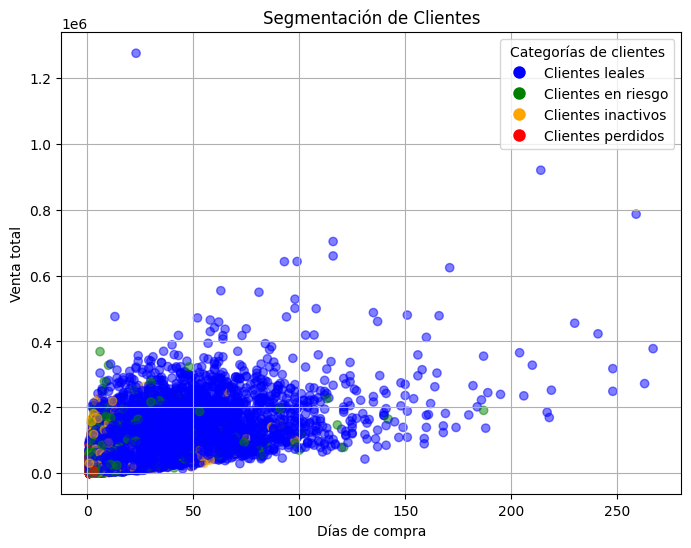

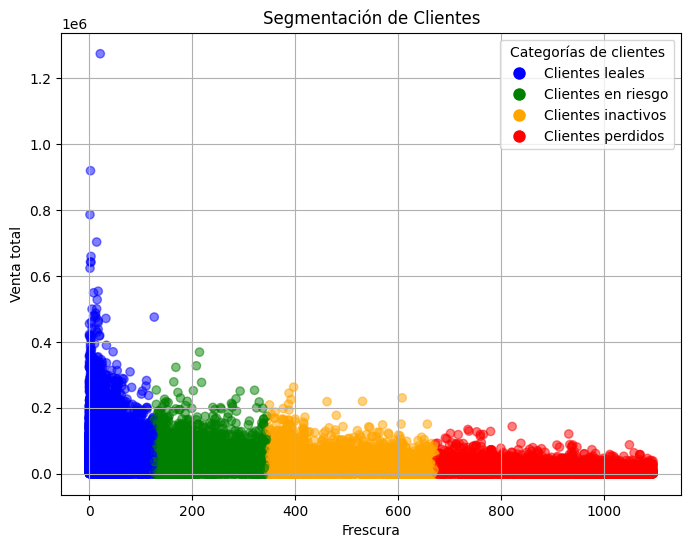

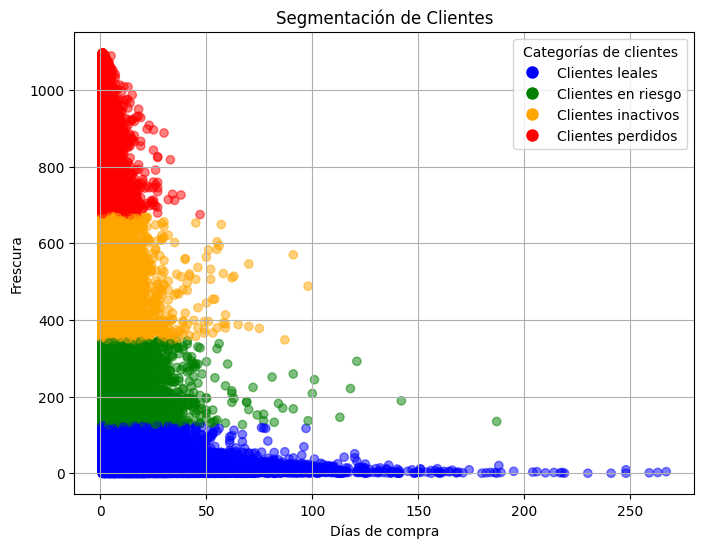

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D

output_file = r".\Dataframes LM\Clientes_Clusterizados.csv"
# Leer el archivo CSV
df = pd.read_csv(output_file, encoding='utf-8-sig')
#df = df[(df["Suma de Vta Total"] <= 5) & (df["Recuento de Fecha"] <= 5)]

# Configuración personalizada
# Crear un nuevo diccionario reordenado
nombres = [
    'Clientes leales',
    'Clientes en riesgo',
    'Clientes inactivos',
    'Clientes perdidos'
]

colores = ['blue', 'green','orange' ,'red']

cluster_config = {
    old_label: {'nombre': nombre, 'color': color}
    for old_label, nombre, color in zip(orden_clusters, nombres, colores)
}

# Diccionario para renombrar ejes
axis_labels = {
    'Recuento de Fecha': 'Días de compra',
    'Suma de Vta Total': 'Venta total',
    'Frescura (días)': 'Frescura'
}

# Función para graficar clusters
def plot_clusters(df, x_col, y_col, cluster_col, title):
    plt.figure(figsize=(8, 6))
    
    # Mapear los valores de cluster a colores y nombres
    colors = df[cluster_col].map({k: v['color'] for k, v in cluster_config.items()})
    
    scatter = plt.scatter(df[x_col], df[y_col], c=colors, alpha=0.5)
    
    # Crear leyenda personalizada con los nuevos nombres
    legend_elements = [Line2D([0], [0], marker='o', color='w', 
                      label=cluster_config[i]['nombre'], 
                      markerfacecolor=cluster_config[i]['color'], 
                      markersize=10) 
                      for i in cluster_config.keys()]
    
    plt.legend(handles=legend_elements, title='Categorías de clientes')
    
    plt.xlabel(axis_labels.get(x_col, x_col))
    plt.ylabel(axis_labels.get(y_col, y_col))
    plt.title(title)
    plt.grid(True)
    plt.show()

# Graficar diferentes combinaciones
plot_clusters(df, 'Recuento de Fecha', 'Suma de Vta Total', 'Cluster_KMeans', 'Segmentación de Clientes')
plot_clusters(df, 'Frescura (días)', 'Suma de Vta Total', 'Cluster_KMeans', 'Segmentación de Clientes')
plot_clusters(df, 'Recuento de Fecha', 'Frescura (días)', 'Cluster_KMeans', 'Segmentación de Clientes')


### Guardar los resultados en el archivo de la Clusterización en QuintilesClientes2año.csv

In [8]:
import pandas as pd
import os

# Ruta base del archivo
ruta_clusters = r".\Dataframes LM\Clientes_Clusterizados.csv"
ruta_quintiles = r".\Dataframes LM\Segmentos VFR.csv"
ruta_salida = r".\Dataframes LM"


df_clusters = pd.read_csv(ruta_clusters, encoding='utf-8-sig')
df_quintiles = pd.read_csv(ruta_quintiles, encoding='utf-8-sig')

# Eliminar 'Cluster_KMeans' si existe en df_quintiles para evitar duplicados
if 'Cluster_KMeans' in df_quintiles.columns:
    df_quintiles = df_quintiles.drop(columns=['Cluster_KMeans'])

# Unir los dataframes
df_final = df_quintiles.merge(df_clusters[['CUENTA', 'Cluster_KMeans']], on='CUENTA', how='left')

# Crear cluster_summary para definir orden de etiquetas
cluster_summary = df_clusters.groupby('Cluster_KMeans')[['Suma de Vta Total', 'Recuento de Fecha', 'Frescura (días)']].mean()
cluster_summary['Score'] = (
    cluster_summary['Suma de Vta Total'] +
    cluster_summary['Recuento de Fecha'] -
    cluster_summary['Frescura (días)'] 
)
orden_clusters = cluster_summary.sort_values('Score', ascending=False).index.tolist()

# Asignar nombres según el orden
nombres = [
    'Clientes leales',
    'Clientes en riesgo',
    'Clientes inactivos',
    'Clientes perdidos'
]

cluster_label_map = {cluster: nombre for cluster, nombre in zip(orden_clusters, nombres)}

# Asignar etiquetas al dataframe final
df_final['Tipo_Cliente'] = df_final['Cluster_KMeans'].map(cluster_label_map)
df_final['Tipo_Cliente'] = df_final['Tipo_Cliente'].fillna('Dato no disponible')
df_final = df_final.drop_duplicates()
# Guardar el archivo resultante
output_file = os.path.join(ruta_salida, "Segmentos VFR.csv")
df_final.to_csv(output_file, index=False, encoding='utf-8-sig')  # Cambiado ruta_salida por output_file

print(f"Archivo guardado en: {output_file}")

Archivo guardado en: .\Dataframes LM\Segmentos VFR.csv


### Se realiza la SubClusterización para cada Cluster

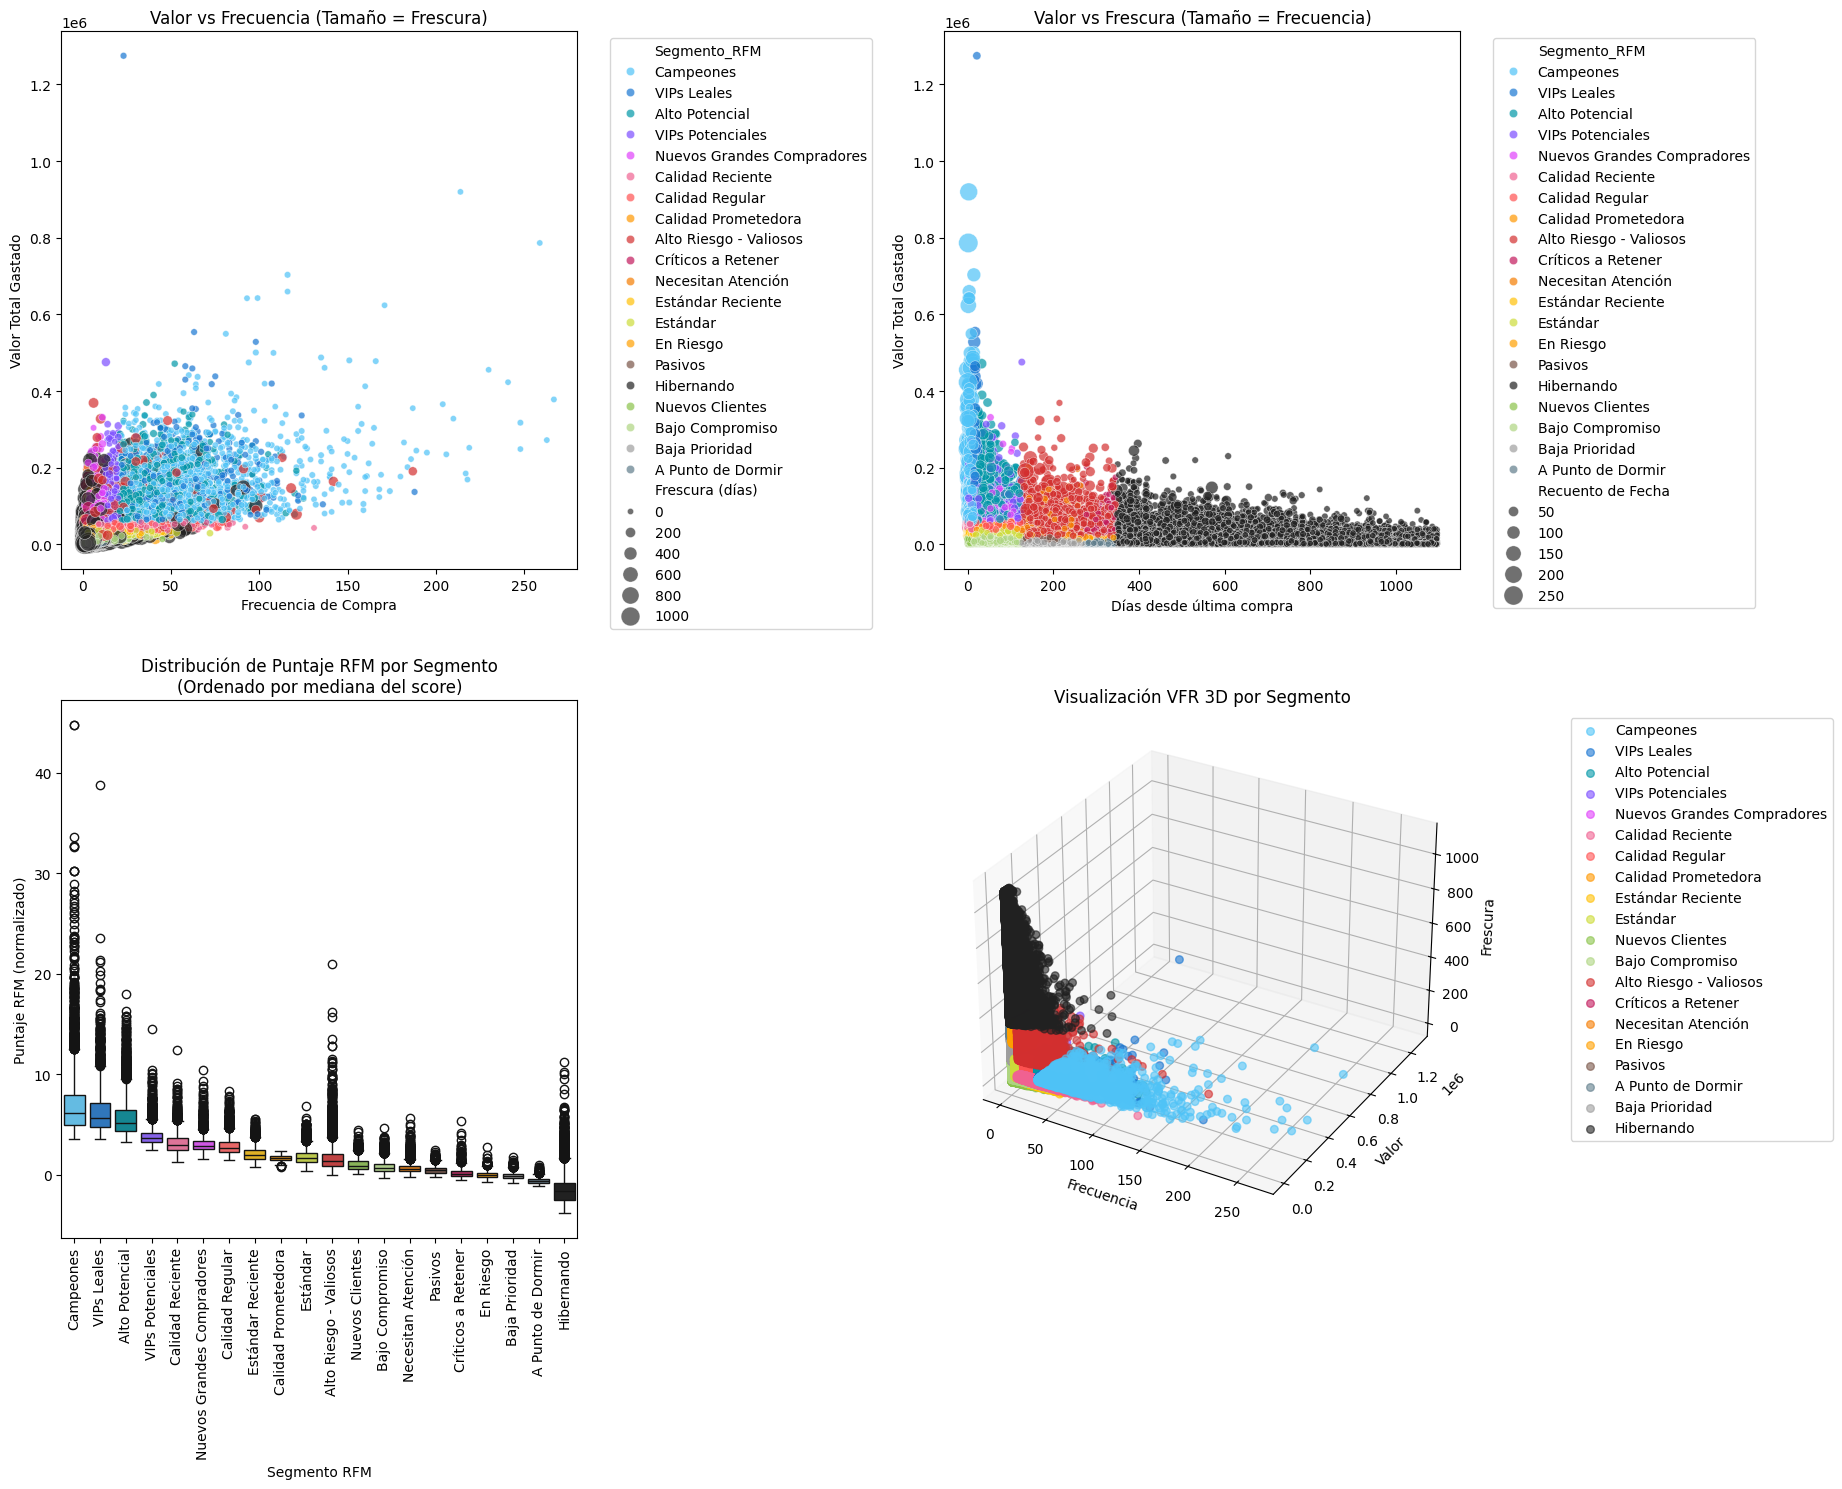

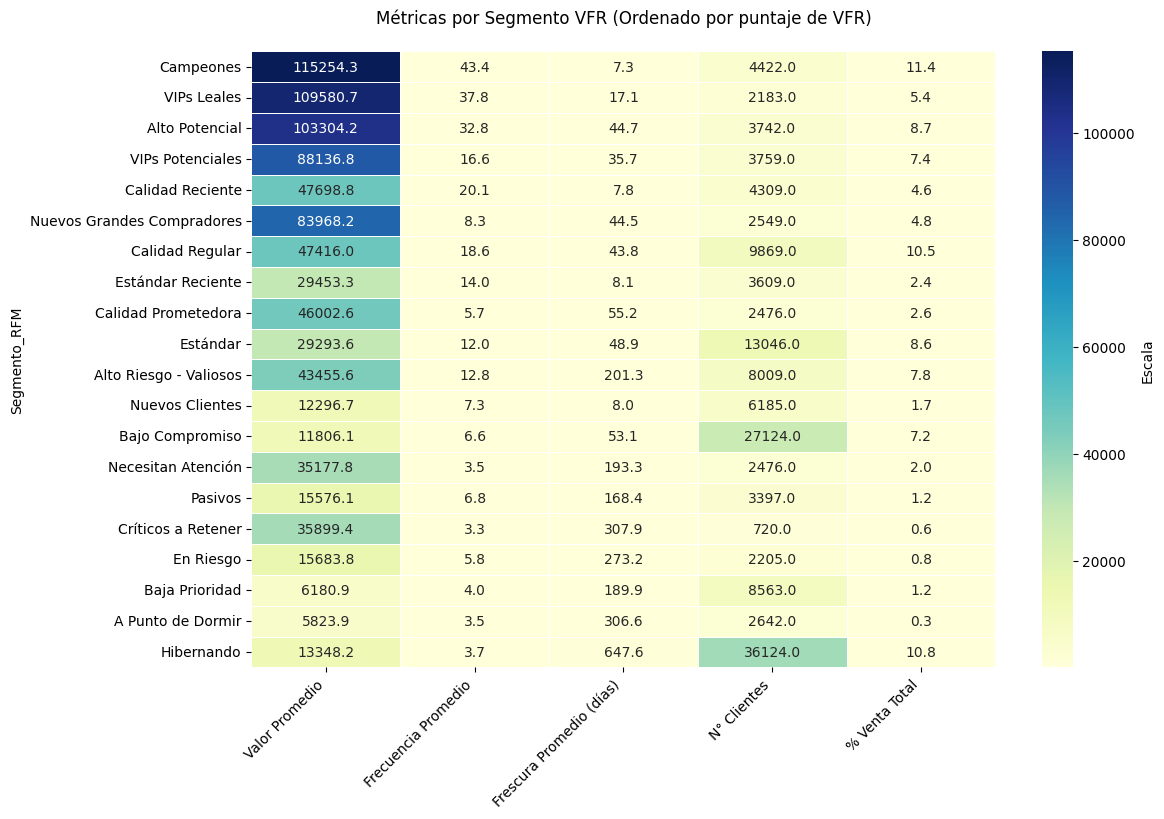

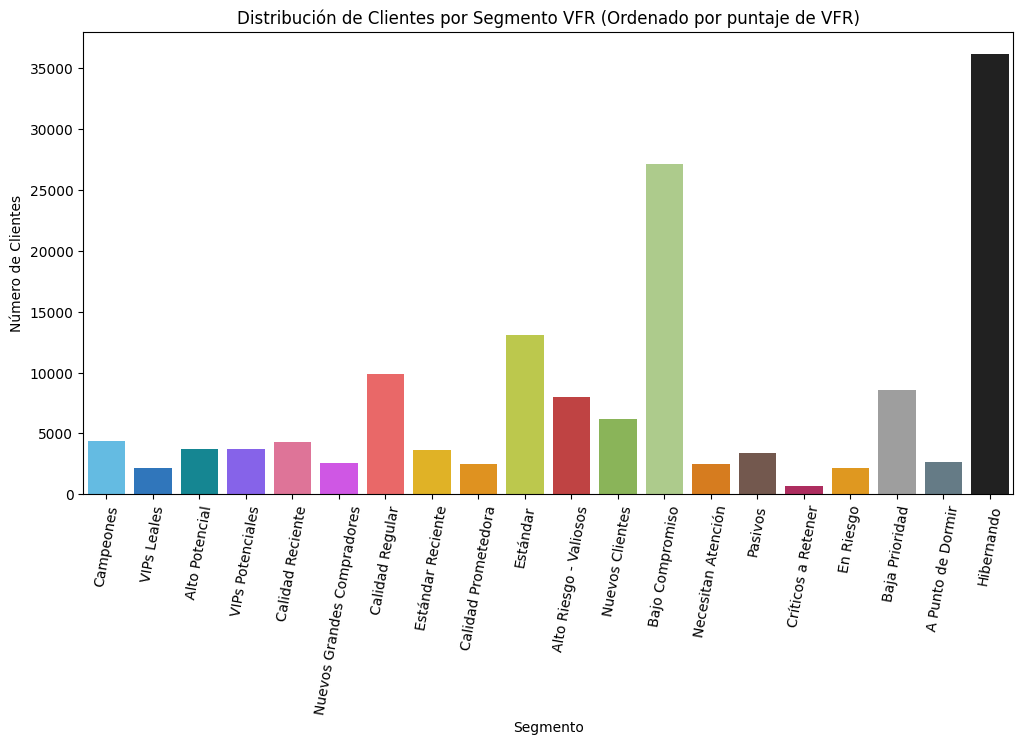

Archivo actualizado guardado en: .\Dataframes LM\Segmentos VFR.csv


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D
import os

ruta_quintiles = r".\Dataframes LM\Segmentos VFR.csv"
df_final = pd.read_csv(ruta_quintiles, encoding='utf-8-sig')
# 1. Filtrar todos los clusters de interés (incluyendo inactivos y perdidos)
df_todos = df_final[df_final['Tipo_Cliente'].isin(['Clientes leales', 'Clientes en riesgo', 'Clientes inactivos', 'Clientes perdidos'])].copy()
df_todos['Frescura (días)'] = pd.to_numeric(df_todos['Frescura (días)'], errors='coerce')

# 2. Calcular quintiles para segmentación - SEPARADO POR TIPO DE CLIENTE
variables = ['Suma de Vta Total', 'Recuento de Fecha', 'Frescura (días)']
percentiles = [20, 40, 60, 80]  # Quintiles para mayor granularidad

# Calcular percentiles para cada variable y cada tipo de cliente
vfr_percentiles = {
    'Clientes leales': {},
    'Clientes en riesgo': {},
    'Clientes inactivos': {},
    'Clientes perdidos': {}
}

for tipo in ['Clientes leales', 'Clientes en riesgo', 'Clientes inactivos', 'Clientes perdidos']:
    df_tipo = df_todos[df_todos['Tipo_Cliente'] == tipo]
    for var in variables:
        vfr_percentiles[tipo][var] = np.percentile(df_tipo[var].dropna(), percentiles)

# 3. Normalización de variables para igual peso
scaler = StandardScaler()
rfm_normalized = df_todos[['Suma de Vta Total', 'Recuento de Fecha', 'Frescura (días)']]
rfm_normalized = pd.DataFrame(scaler.fit_transform(rfm_normalized), 
                            columns=['Valor_norm', 'Frecuencia_norm', 'Frescura_norm'],
                            index=rfm_normalized.index)

df_todos = pd.concat([df_todos, rfm_normalized], axis=1)

# 4. Asignar segmentos RFM mejorados con quintiles
def asignar_segmento_mejorado(row):
    valor = row['Suma de Vta Total']
    frecuencia = row['Recuento de Fecha']
    frescura = row['Frescura (días)']
    tipo = row['Tipo_Cliente']
    percentiles_tipo = vfr_percentiles[tipo]
    
    # Segmentación para Clientes Leales (más granular)
    if tipo == 'Clientes leales':
        # Top 20% valor
        if valor >= percentiles_tipo['Suma de Vta Total'][3]:
            if frecuencia >= percentiles_tipo['Recuento de Fecha'][3]:  # Top 20% frecuencia
                if frescura <= percentiles_tipo['Frescura (días)'][0]:  # Bottom 20% frescura
                    return 'Campeones'
                elif frescura <= percentiles_tipo['Frescura (días)'][1]:  # 20-40%
                    return 'VIPs Leales'
                else:
                    return 'Alto Potencial'
            elif frecuencia >= percentiles_tipo['Recuento de Fecha'][2]:  # 60-80%
                return 'VIPs Potenciales'
            else:
                return 'Nuevos Grandes Compradores'
        # 60-80% valor
        elif valor >= percentiles_tipo['Suma de Vta Total'][2]:
            if frescura <= percentiles_tipo['Frescura (días)'][0]:
                return 'Calidad Reciente'
            elif frecuencia >= percentiles_tipo['Recuento de Fecha'][1]:  # 40-60%
                return 'Calidad Regular'
            else:
                return 'Calidad Prometedora'
        # 40-60% valor
        elif valor >= percentiles_tipo['Suma de Vta Total'][1]:
            if frescura <= percentiles_tipo['Frescura (días)'][0]:
                return 'Estándar Reciente'
            else:
                return 'Estándar'
        # Bottom 40% valor
        else:
            if frescura <= percentiles_tipo['Frescura (días)'][0]:
                return 'Nuevos Clientes'
            else:
                return 'Bajo Compromiso'
    
    # Segmentación mejorada para Clientes en Riesgo
    elif tipo == 'Clientes en riesgo':
        # Top 40% valor
        if valor >= percentiles_tipo['Suma de Vta Total'][2]:
            if frecuencia >= percentiles_tipo['Recuento de Fecha'][2]:  # Top 40% frecuencia
                return 'Alto Riesgo - Valiosos'
            elif frescura >= percentiles_tipo['Frescura (días)'][3]:  # Top 20% antigüedad
                return 'Críticos a Retener'
            else:
                return 'Necesitan Atención'
        # 40-60% valor
        elif valor >= percentiles_tipo['Suma de Vta Total'][1]:
            if frescura >= percentiles_tipo['Frescura (días)'][2]:  # 60-80%
                return 'En Riesgo'
            else:
                return 'Pasivos'
        # Bottom 40% valor
        else:
            if frescura >= percentiles_tipo['Frescura (días)'][3]:  # Top 20%
                return 'A Punto de Dormir'
            else:
                return 'Baja Prioridad'
    
    # Segmentación para Clientes Inactivos y Perdidos
    else:
        return 'Hibernando'

df_todos['Segmento_RFM'] = df_todos.apply(asignar_segmento_mejorado, axis=1)
df_todos['RFM_Score'] = (df_todos['Valor_norm'] + 
                        df_todos['Frecuencia_norm'] + 
                        (1 - df_todos['Frescura_norm']))

# 5. Gráficos mejorados
plt.figure(figsize=(18, 15))

# Paleta de colores mejorada
palette = {
    # Segmentos leales
    'Campeones': '#4FC3F7', 'VIPs Leales': '#1976D2', 'Alto Potencial': '#0097A7',
    'VIPs Potenciales': '#7C4DFF', 'Nuevos Grandes Compradores': '#E040FB', 'Calidad Reciente': '#F06292',
    'Calidad Regular': '#FF5252', 'Calidad Prometedora': '#FF9800', 'Estándar Reciente': '#FFC107',
    'Estándar': '#CDDC39', 'Nuevos Clientes': '#8BC34A', 'Bajo Compromiso': '#AED581',
    
    # Segmentos en riesgo
    'Alto Riesgo - Valiosos': '#D32F2F', 'Críticos a Retener': '#C2185B', 'Necesitan Atención': '#F57C00',
    'En Riesgo': '#FFA000', 'Pasivos': '#795548', 'A Punto de Dormir': '#607D8B', 'Baja Prioridad': '#9E9E9E',
    
    # Segmentos inactivos y perdidos
    'Hibernando': '#212121' 
}
segment_means = df_todos.groupby('Segmento_RFM')[['Suma de Vta Total', 'Recuento de Fecha', 'Frescura (días)']].mean()
segment_order = segment_means.sort_values('Suma de Vta Total', ascending=False).index.tolist()
segment_means = segment_means.loc[segment_order]

# Gráfico 1: Valor vs Frecuencia con tamaño por frescura
plt.subplot(2, 2, 1)
scatter = sns.scatterplot(data=df_todos, 
                        x='Recuento de Fecha', 
                        y='Suma de Vta Total', 
                        hue='Segmento_RFM',
                        size='Frescura (días)',
                        sizes=(20, 200),
                        palette=palette,
                        alpha=0.7,
                        hue_order=segment_order)
plt.title('Valor vs Frecuencia (Tamaño = Frescura)')
plt.xlabel('Frecuencia de Compra')
plt.ylabel('Valor Total Gastado')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


# Gráfico 2: Valor vs Frescura con tamaño por frecuencia
plt.subplot(2, 2, 2)
ax = sns.scatterplot(data=df_todos, 
                x='Frescura (días)', 
                y='Suma de Vta Total', 
                hue='Segmento_RFM',
                size='Recuento de Fecha',
                sizes=(20, 200),
                palette=palette,
                alpha=0.7,
                hue_order=segment_order)
plt.title('Valor vs Frescura (Tamaño = Frecuencia)')
plt.xlabel('Días desde última compra')
plt.ylabel('Valor Total Gastado')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Gráfico 3: Boxplots por segmento ordenado por mediana del RFM_Score
plt.subplot(2, 2, 3)
order = df_todos.groupby('Segmento_RFM')['RFM_Score'].median().sort_values(ascending=False).index
sns.boxplot(data=df_todos, 
            x='Segmento_RFM', 
            y='RFM_Score',
            palette=palette,
            order=order,
            hue_order=segment_order)
plt.xticks(rotation=90)
plt.title('Distribución de Puntaje RFM por Segmento\n(Ordenado por mediana del score)')
plt.xlabel('Segmento RFM')
plt.ylabel('Puntaje RFM (normalizado)')

# Gráfico 4: Visualización 3D mejorada
ax = plt.subplot(2, 2, 4, projection='3d')
for segment, color in palette.items():
    if segment in df_todos['Segmento_RFM'].unique():
        segment_data = df_todos[df_todos['Segmento_RFM'] == segment]
        ax.scatter(segment_data['Recuento de Fecha'],
                   segment_data['Suma de Vta Total'],
                   segment_data['Frescura (días)'],
                   c=color, label=segment, alpha=0.6, s=30)
    
ax.set_xlabel('Frecuencia')
ax.set_ylabel('Valor')
ax.set_zlabel('Frescura')
ax.set_title('Visualización VFR 3D por Segmento')
plt.legend(bbox_to_anchor=(1.2, 1), loc='upper left')

plt.tight_layout()
plt.show()

# 6. Análisis adicional: Heatmap de correlaciones
# Calcular estadísticas por segmento
segment_stats = df_todos.groupby('Segmento_RFM').agg({
    'RFM_Score': 'median',
    'Suma de Vta Total': ['mean', 'sum', 'count'],
    'Recuento de Fecha': 'mean',
    'Frescura (días)': 'mean'
})

# Aplanar el MultiIndex y renombrar columnas
segment_stats.columns = ['RFM_Mediana', 'Venta_Promedio', 'Venta_Total', 'Num_Clientes', 'Frecuencia_Promedio', 'Frescura_Promedio']

# Calcular % de venta total
segment_stats['%_Venta'] = (segment_stats['Venta_Total'] / segment_stats['Venta_Total'].sum()) * 100

# Ordenar por RFM_Mediana (de mayor a menor)
segment_stats = segment_stats.sort_values('RFM_Mediana', ascending=False)

# Seleccionar columnas para el heatmap (ahora con las 2 nuevas)
heatmap_data = segment_stats[['Venta_Promedio', 'Frecuencia_Promedio', 'Frescura_Promedio', 'Num_Clientes', '%_Venta']]
heatmap_data.rename(columns={
    'Venta_Promedio': 'Valor Promedio',
    'Frecuencia_Promedio': 'Frecuencia Promedio',
    'Frescura_Promedio': 'Frescura Promedio (días)',
    'Num_Clientes': 'N° Clientes',
    '%_Venta': '% Venta Total'
}, inplace=True)

# Heatmap mejorado
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, 
            annot=True, 
            fmt=".1f", 
            cmap="YlGnBu",
            cbar_kws={'label': 'Escala'},
            linewidths=0.5)
plt.title('Métricas por Segmento VFR (Ordenado por puntaje de VFR)', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()
# 7. Distribución de clientes por segmento (ORDENADO POR RFM)
plt.figure(figsize=(12, 6))

# Calcular el orden basado en la mediana del RFM_Score (de mayor a menor)
segment_order_rfm = df_todos.groupby('Segmento_RFM')['RFM_Score'].median().sort_values(ascending=False).index

# Contar clientes por segmento y reordenar según RFM
segment_counts = df_todos['Segmento_RFM'].value_counts()[segment_order_rfm]

# Crear el gráfico de barras ordenado
sns.barplot(x=segment_counts.index, 
            y=segment_counts.values, 
            palette=palette,
            order=segment_order_rfm)
plt.title('Distribución de Clientes por Segmento VFR (Ordenado por puntaje de VFR)')
plt.xlabel('Segmento')
plt.ylabel('Número de Clientes')
plt.xticks(rotation=80)
plt.show()

# 1. Leer el archivo existente con los quintiles
ruta_quintiles = r".\Dataframes LM\Segmentos VFR.csv"
df_quintiles = pd.read_csv(ruta_quintiles)

# 2. Crear un DataFrame solo con las columnas necesarias para el merge
df_segmentos = df_todos[['CUENTA', 'Segmento_RFM']].drop_duplicates().copy()

# Diccionario de mapeo de segmentos a calificación numérica (1 = mejor, 20 = peor)
segmento_a_calificacion = {
    # Segmentos leales (1-12)
    'Campeones': 1,
    'VIPs Leales': 2,
    'Alto Potencial': 3,
    'VIPs Potenciales': 4,
    'Calidad Reciente': 5,
    'Nuevos Grandes Compradores': 6,
    'Calidad Regular': 7,
    'Estándar Reciente': 8,
    'Estándar': 9,
    'Calidad Prometedora': 10,
    'Alto Riesgo - Valiosos': 11,
    'Nuevos Clientes': 12,
    'Bajo Compromiso': 13,
    
    # Segmentos en riesgo (13-19)
    'Pasivos': 14,
    'Críticos a Retener': 15,
    'Necesitan Atención': 16,
    'En Riesgo': 17,
  
    'Baja Prioridad': 18,
    'A Punto de Dormir': 19,

    
    # Segmentos inactivos/perdidos (20)
    'Hibernando': 20
}
# Asignar la calificación numérica
df_segmentos['Calificacion_Segmento'] = df_segmentos['Segmento_RFM'].map(segmento_a_calificacion)
df_segmentos['Segmento_RFM'] = df_segmentos['Segmento_RFM'].fillna('Dato no disponible')

# Eliminar las columnas 'Segmento_RFM' y 'Calificacion_Segmento' de df_quintiles si existen para evitar conflictos de sufijos
cols_to_drop = []
if 'Segmento_RFM' in df_quintiles.columns:
    cols_to_drop.append('Segmento_RFM')
if 'Calificacion_Segmento' in df_quintiles.columns:
    cols_to_drop.append('Calificacion_Segmento')
if cols_to_drop:
    df_quintiles = df_quintiles.drop(columns=cols_to_drop)

# 3. Hacer el merge con el DataFrame original de quintiles
# Usamos left join para mantener todos los registros del archivo original
df_final_quintiles = df_quintiles.merge(
    df_segmentos,
    on='CUENTA',
    how='left'
)

# 4. Guardar el archivo actualizado (puedes guardarlo con otro nombre o sobrescribir)
ruta_actualizada = r".\Dataframes LM\Segmentos VFR.csv"
df_final_quintiles.to_csv(ruta_actualizada, index=False, encoding='utf-8-sig')

print(f"Archivo actualizado guardado en: {ruta_actualizada}")

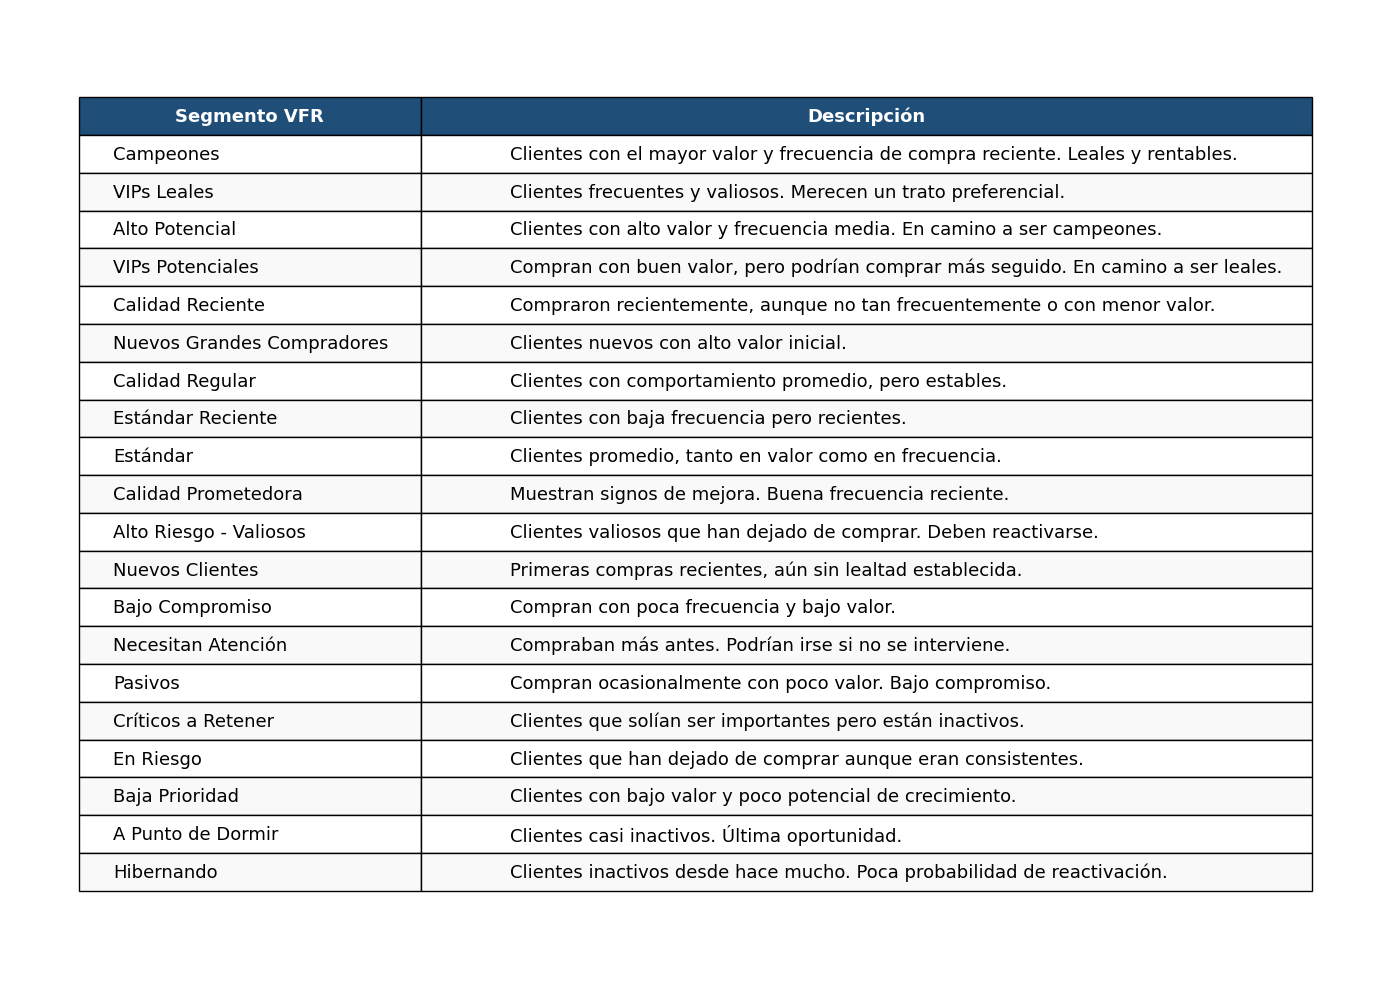

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Definir segmentos y descripciones
segmentos_rfm = {
    "Campeones": "Clientes con el mayor valor y frecuencia de compra reciente. Leales y rentables.",
    "VIPs Leales": "Clientes frecuentes y valiosos. Merecen un trato preferencial.",
    "Alto Potencial":  "Clientes con alto valor y frecuencia media. En camino a ser campeones.",
    "VIPs Potenciales":"Compran con buen valor, pero podrían comprar más seguido. En camino a ser leales.",
    "Calidad Reciente": "Compraron recientemente, aunque no tan frecuentemente o con menor valor.",
    "Nuevos Grandes Compradores": "Clientes nuevos con alto valor inicial.",
    "Calidad Regular": "Clientes con comportamiento promedio, pero estables.",
    "Estándar Reciente": "Clientes con baja frecuencia pero recientes.",
    "Estándar": "Clientes promedio, tanto en valor como en frecuencia.",
    "Calidad Prometedora": "Muestran signos de mejora. Buena frecuencia reciente.",
    "Alto Riesgo - Valiosos": "Clientes valiosos que han dejado de comprar. Deben reactivarse.",
    "Nuevos Clientes": "Primeras compras recientes, aún sin lealtad establecida.",
    "Bajo Compromiso": "Compran con poca frecuencia y bajo valor.",
    "Necesitan Atención": "Compraban más antes. Podrían irse si no se interviene.",
    "Pasivos": "Compran ocasionalmente con poco valor. Bajo compromiso.",
    "Críticos a Retener": "Clientes que solían ser importantes pero están inactivos.",
    "En Riesgo": "Clientes que han dejado de comprar aunque eran consistentes.",
    "Baja Prioridad": "Clientes con bajo valor y poco potencial de crecimiento.",
    "A Punto de Dormir": "Clientes casi inactivos. Última oportunidad.",
    "Hibernando": "Clientes inactivos desde hace mucho. Poca probabilidad de reactivación."
}

# Crear DataFrame
df_glosario = pd.DataFrame(list(segmentos_rfm.items()), columns=["Segmento VFR", "Descripción"])

# Orden personalizado
orden_custom = [
    "Campeones", "VIPs Leales", "Alto Potencial", "VIPs Potenciales", "Calidad Reciente", "Nuevos Grandes Compradores",
    "Calidad Regular", "Estándar Reciente", "Estándar", "Calidad Prometedora", "Alto Riesgo - Valiosos",
    "Nuevos Clientes", "Bajo Compromiso", "Necesitan Atención", "Pasivos", "Críticos a Retener",
    "En Riesgo", "Baja Prioridad", "A Punto de Dormir", "Hibernando"
]
df_glosario["Orden"] = df_glosario["Segmento VFR"].apply(lambda x: orden_custom.index(x))
df_glosario = df_glosario.sort_values("Orden").drop(columns="Orden")

# Crear figura y eje
fig, ax = plt.subplots(figsize=(14, 10))
ax.axis('off')

# Crear tabla con matplotlib
tabla = ax.table(
    cellText=df_glosario.values,
    colLabels=df_glosario.columns,
    cellLoc='left',
    colColours=['#1F4E79', '#1F4E79'],
    colWidths=[0.25, 0.65],
    loc='center'
)

# Formato para celdas y encabezado
tabla.auto_set_font_size(False)
tabla.set_fontsize(13)
tabla.scale(1, 1.8)

# Encabezado con color blanco
for (row, col), cell in tabla.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
    else:
        cell.set_text_props(weight='normal', color='black')

# Color filas alternas para mejor lectura
for row in range(1, len(df_glosario)+1):
    color = '#f9f9f9' if row % 2 == 0 else 'white'
    for col in range(2):
        tabla[(row, col)].set_facecolor(color)

plt.tight_layout()

# Guardar imagen
plt.savefig("Glosario_Segmentos_RFM.png", dpi=300, bbox_inches='tight')

# Mostrar tabla
plt.show()


### Quintiles para cada Cluster de Tipo de Cliente

In [11]:
import pandas as pd

# Cargar el archivo CSV
df = pd.read_csv(r".\Dataframes LM\Segmentos VFR.csv", encoding='utf-8-sig')

# Convertir la columna de fecha y calcular frescura
df['Última fecha: Fecha'] = pd.to_datetime(df['Última fecha: Fecha'], errors='coerce', format='%Y-%m-%d')
fecha_actual = df['Última fecha: Fecha'].max()  # Fecha específica de referencia
df['Frescura (días)'] = (fecha_actual - df['Última fecha: Fecha']).dt.days

# Configuración de nombres para cada cluster
# Agrupar y calcular métricas promedio por cluster
cluster_summary = df.groupby('Cluster_KMeans')[['Suma de Vta Total', 'Recuento de Fecha', 'Frescura (días)']].mean()
cluster_summary['Score'] = (
    cluster_summary['Suma de Vta Total'] +
    cluster_summary['Recuento de Fecha'] -
    cluster_summary['Frescura (días)'] 
)
orden_clusters = cluster_summary.sort_values('Score', ascending=False).index.tolist()

# Asignar nombres dinámicos según el orden del Score
etiquetas = [
    'Clientes leales',
    'Clientes en riesgo',
    'Clientes inactivos',
    'Clientes perdidos'
]
cluster_config = {cluster: {'nombre': nombre} for cluster, nombre in zip(orden_clusters, etiquetas)}
# Función para calcular los quintiles
def calcular_quintiles(df, columna, nombre):
    df = df[df[columna].notna()]
    
    if df.empty:
        return pd.DataFrame(columns=['Intervalo', 'Mínimo', 'Máximo', 'Cuentas', 'Porcentaje'])
    
    quintiles = df[columna].quantile([0, 0.2, 0.4, 0.6, 0.8, 1.0]).drop_duplicates().tolist()
    
    if len(quintiles) < 2:
        return pd.DataFrame(columns=['Intervalo', 'Mínimo', 'Máximo', 'Cuentas', 'Porcentaje'])
    
    intervalos = [f"{int(quintiles[i])} - {int(quintiles[i+1])}" for i in range(len(quintiles)-1)]
    conteos = pd.cut(df[columna], bins=quintiles, include_lowest=True, labels=range(len(intervalos))).value_counts().sort_index()
    porcentaje = (conteos / conteos.sum() * 100).round(2)
    
    df_resultado = pd.DataFrame({
        'Intervalo': intervalos,
        'Mínimo': [int(quintiles[i]) for i in range(len(quintiles)-1)],
        'Máximo': [int(quintiles[i+1]) for i in range(len(quintiles)-1)],
        'Cuentas': conteos.values,
        'Porcentaje': porcentaje.values
    })
    
    return df_resultado.iloc[::-1]  # Mostrar del quintil superior al inferior

# Calcular y mostrar los quintiles por cluster con nombres
clusters = df['Cluster_KMeans'].dropna().unique()

for cluster in sorted(clusters):
    nombre_cluster = cluster_config.get(cluster, {}).get('nombre', 'Desconocido')
    
    print(f"\n{nombre_cluster} - Rangos del Valor de Compra")
    print(calcular_quintiles(df[df['Cluster_KMeans'] == cluster], 'Suma de Vta Total', 'Valor de Compra'))
    
    print(f"\n{nombre_cluster} - Rangos de la Frecuencia de Visita")
    print(calcular_quintiles(df[df['Cluster_KMeans'] == cluster], 'Recuento de Fecha', 'Frecuencia de Visita'))
    
    print(f"\n{nombre_cluster} - Rangos de la Frescura")
    print(calcular_quintiles(df[df['Cluster_KMeans'] == cluster], 'Frescura (días)', 'Frescura'))




Clientes leales - Rangos del Valor de Compra


         Intervalo  Mínimo   Máximo  Cuentas  Porcentaje
4  60522 - 1274939   60522  1274939    16655        20.0
3    36754 - 60522   36754    60522    16654        20.0
2    22677 - 36754   22677    36754    16655        20.0
1    11899 - 22677   11899    22677    16654        20.0
0       76 - 11899      76    11899    16655        20.0

Clientes leales - Rangos de la Frecuencia de Visita


  Intervalo  Mínimo  Máximo  Cuentas  Porcentaje
4  21 - 267      21     267    16510       19.83
3   13 - 21      13      21    16463       19.77
2    9 - 13       9      13    13111       15.74
1     5 - 9       5       9    16612       19.95
0     1 - 5       1       5    20577       24.71

Clientes leales - Rangos de la Frescura


  Intervalo  Mínimo  Máximo  Cuentas  Porcentaje
4  61 - 126      61     126    16643       19.99
3   39 - 61      39      61    16662       20.01
2   21 - 39      21      39    16111       19.35
1   14 - 21      14      21    13953       16.76
0    0 - 14       0      14    19904       23.90

Clientes perdidos - Rangos del Valor de Compra
        Intervalo  Mínimo  Máximo  Cuentas  Porcentaje
4  14265 - 143401   14265  143401     3141       20.00
3    7365 - 14265    7365   14265     3141       20.00
2     3701 - 7365    3701    7365     3141       20.00
1     1677 - 3701    1677    3701     3141       20.00
0       44 - 1677      44    1677     3142       20.01

Clientes perdidos - Rangos de la Frecuencia de Visita
  Intervalo  Mínimo  Máximo  Cuentas  Porcentaje
2    3 - 47       3      47     2983       18.99
1     2 - 3       2       3     1939       12.35
0     1 - 2       1       2    10784       68.66

Clientes perdidos - Rangos de la Frescura


    Intervalo  Mínimo  Máximo  Cuentas  Porcentaje
4  985 - 1096     985    1096     3117       19.85
3   901 - 985     901     985     3160       20.12
2   809 - 901     809     901     3136       19.97
1   747 - 809     747     809     3061       19.49
0   673 - 747     673     747     3232       20.58

Clientes inactivos - Rangos del Valor de Compra
        Intervalo  Mínimo  Máximo  Cuentas  Porcentaje
4  25533 - 262912   25533  262912     4084       20.00
3   14412 - 25533   14412   25533     4083       20.00
2    8067 - 14412    8067   14412     4084       20.00
1     3721 - 8067    3721    8067     4081       19.99
0       41 - 3721      41    3721     4086       20.01

Clientes inactivos - Rangos de la Frecuencia de Visita
  Intervalo  Mínimo  Máximo  Cuentas  Porcentaje
4    7 - 98       7      98     3215       15.75
3     4 - 7       4       7     4010       19.64
2     3 - 4       3       4     2429       11.90
1     2 - 3       2       3     3075       15.06
0     1 - 2   

   Intervalo  Mínimo  Máximo  Cuentas  Porcentaje
4  582 - 672     582     672     4068       19.92
3  501 - 582     501     582     4042       19.80
2  424 - 501     424     501     4109       20.12
1  385 - 424     385     424     4055       19.86
0  346 - 385     346     385     4144       20.30

Clientes en riesgo - Rangos del Valor de Compra
        Intervalo  Mínimo  Máximo  Cuentas  Porcentaje
4  33394 - 369180   33394  369180     5603        20.0
3   19905 - 33394   19905   33394     5602        20.0
2   11849 - 19905   11849   19905     5602        20.0
1    6033 - 11849    6033   11849     5602        20.0
0       76 - 6033      76    6033     5603        20.0

Clientes en riesgo - Rangos de la Frecuencia de Visita


  Intervalo  Mínimo  Máximo  Cuentas  Porcentaje
4  10 - 187      10     187     5207       18.59
3    6 - 10       6      10     5952       21.25
2     4 - 6       4       6     4828       17.24
1     2 - 4       2       4     6194       22.11
0     1 - 2       1       2     5831       20.82

Clientes en riesgo - Rangos de la Frescura
   Intervalo  Mínimo  Máximo  Cuentas  Porcentaje
4  269 - 345     269     345     5603       20.00
3  221 - 269     221     269     5499       19.63
2  185 - 221     185     221     5521       19.71
1  150 - 185     150     185     5660       20.21
0  125 - 150     125     150     5729       20.45


### Comparación de Quintiles de 36 meses y 34 meses y se guarda en Analisis_Cambio_Clientes_36a34meses.csv

In [12]:
import pandas as pd

# Cargar datasets
df_34 = pd.read_csv(r".\Dataframes LM\Segmentos 34 meses.csv", parse_dates=["Última fecha: Fecha"])
df_36 = pd.read_csv(r".\Dataframes LM\Segmentos VFR.csv", parse_dates=["Última fecha: Fecha"])

# Renombrar columnas para diferenciarlas
df_34 = df_34.rename(columns={
    "Suma de Vta Total": "Venta_34",
    "Recuento de Fecha": "Frecuencia_34",
    "ETIQ1": "Venta_Q34",
    "ETIQ2": "Frecuencia_Q34",
    "ETIQ3": "Frescura_Q34",
    "CUENTA":"Cliente"
})

df_36 = df_36.rename(columns={
    "Suma de Vta Total": "Venta_36",
    "Recuento de Fecha": "Frecuencia_36",
    "ETIQ1": "Venta_Q36",
    "ETIQ2": "Frecuencia_Q36",
    "ETIQ3": "Frescura_Q36",
    "CUENTA":"Cliente"
})


# Merge de ambos períodos (clientes que aparecen en ambos)
df_merge = pd.merge(df_36[['Cliente', 'Venta_36', 'Frecuencia_36', 'Venta_Q36', 'Frecuencia_Q36', 'Frescura_Q36']],
                    df_34[['Cliente', 'Venta_34', 'Frecuencia_34', 'Venta_Q34', 'Frecuencia_Q34', 'Frescura_Q34']],
                    on='Cliente', how='inner')

# Variables de cambio
df_merge['Cambio_Venta'] = df_merge['Venta_34'] - df_merge['Venta_36']  # 34 es posterior a 36
df_merge['Cambio_Frecuencia'] = df_merge['Frecuencia_34'] - df_merge['Frecuencia_36']

import re

# Robust conversion from labels like 'V1','F2','R3' (or numeric) to integers.
def label_to_num(val):
    if pd.isna(val):
        return np.nan
    # If already numeric
    if isinstance(val, (int, float, np.integer, np.floating)):
        return float(val)
    s = str(val)
    m = re.search(r'(\d+)', s)
    if m:
        return float(m.group(1))
    return np.nan

# Crear columnas numéricas (para comparación segura)
for col in ['Venta_Q34','Venta_Q36','Frecuencia_Q34','Frecuencia_Q36','Frescura_Q34','Frescura_Q36']:
    df_merge[col + '_num'] = df_merge[col].apply(label_to_num)

# Indicadores de cambio de quintil (tratando NaN==NaN como 'sin cambio')
def changed(a, b):
    if pd.isna(a) and pd.isna(b):
        return False
    return a != b

df_merge['Cambio_Quintil_Venta'] = df_merge.apply(lambda x: changed(x['Venta_Q34_num'], x['Venta_Q36_num']), axis=1)
df_merge['Cambio_Quintil_Frecuencia'] = df_merge.apply(lambda x: changed(x['Frecuencia_Q34_num'], x['Frecuencia_Q36_num']), axis=1)
df_merge['Cambio_Quintil_Frescura'] = df_merge.apply(lambda x: changed(x['Frescura_Q34_num'], x['Frescura_Q36_num']), axis=1)

# Dirección del cambio (de 36 → 34 meses) — maneja NaN devolviendo 'Desconocido'
def direction_num(old, new):
    if pd.isna(old) or pd.isna(new):
        return 'Desconocido'
    if new > old:
        return 'Subió'
    elif new < old:
        return 'Bajó'
    else:
        return 'Igual'

df_merge['Direccion_Cambio_Venta'] = df_merge.apply(lambda x: direction_num(x['Venta_Q36_num'], x['Venta_Q34_num']), axis=1)
df_merge['Direccion_Cambio_Frecuencia'] = df_merge.apply(lambda x: direction_num(x['Frecuencia_Q36_num'], x['Frecuencia_Q34_num']), axis=1)
df_merge['Direccion_Cambio_Frescura'] = df_merge.apply(lambda x: direction_num(x['Frescura_Q36_num'], x['Frescura_Q34_num']), axis=1)

# (Opcional) eliminar columnas numéricas temporales si no las necesitas:
# df_merge.drop(columns=[c for c in df_merge.columns if c.endswith('_num')], inplace=True)

# Ver resultados principales
print(df_merge[['Cliente', 'Venta_36', 'Venta_34', 'Cambio_Venta',
                'Venta_Q36', 'Venta_Q34', 'Direccion_Cambio_Venta']].head())

# Guardar resultados
df_merge.to_csv(r".\Dataframes LM\Analisis_Cambio_Clientes_36a34meses.csv", index=False, encoding='utf-8-sig')


   Cliente  Venta_36  Venta_34  Cambio_Venta Venta_Q36 Venta_Q34  \
0   208913      0.00      0.00           0.0        V0        V0   
1   250527      0.00      0.00           0.0        V0        V0   
2    55559      0.00      0.00           0.0        V0        V0   
3   277045      0.00      0.00           0.0        V0        V0   
4   297542   5929.14   5929.14           0.0        V1        V1   

  Direccion_Cambio_Venta  
0                  Igual  
1                  Igual  
2                  Igual  
3                  Igual  
4                  Igual  


### Se agregan las etiquetas de transición al archivo original Segmentos VFR.csv

In [13]:
import pandas as pd

# === Cargar los datos ya procesados ===
df_merge = pd.read_csv(r".\Dataframes LM\Analisis_Cambio_Clientes_36a34meses.csv", encoding='utf-8-sig')



# Crear columna de transición tipo "V3->V4"
df_merge['TransicionV (36->34)'] = df_merge['Venta_Q36'].astype(str) + ' -> ' + df_merge['Venta_Q34'].astype(str)
df_merge['TransicionF (36->34)'] = df_merge['Frecuencia_Q36'].astype(str) + ' -> ' + df_merge['Frecuencia_Q34'].astype(str)
df_merge['TransicionR (36->34)'] = df_merge['Frescura_Q36'].astype(str) + ' -> ' + df_merge['Frescura_Q34'].astype(str)

# === Cargar el archivo base de 36 meses ===
df_36 = pd.read_csv(r".\Dataframes LM\Segmentos VFR.csv", encoding='utf-8-sig')

if 'TransicionV (36->34)' in df_36.columns:
    df_36 = df_36.drop(columns=['TransicionV (36->34)'])
if 'TransicionF (36->34)' in df_36.columns:
    df_36 = df_36.drop(columns=['TransicionF (36->34)'])
if 'TransicionR (36->34)' in df_36.columns:
    df_36 = df_36.drop(columns=['TransicionR (36->34)'])


# Renombrar columna CUENTA si no está así
if 'CUENTA' not in df_36.columns:
    df_36 = df_36.rename(columns={'Cliente': 'CUENTA'})

# Unir la columna de transición con base en CUENTA
df_36 = pd.merge(df_36, df_merge[['Cliente', 'TransicionV (36->34)','TransicionF (36->34)','TransicionR (36->34)']], left_on='CUENTA', right_on='Cliente', how='left')
df_36.drop(columns='Cliente', inplace=True)

# === Guardar el nuevo archivo con la columna Transición ===
output_path = r".\Dataframes LM\Segmentos VFR.csv"
df_36.drop_duplicates(inplace=True)  # Eliminar duplicados si los hubiera

df_36.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"✅ Columna 'Transicion' añadida y archivo guardado en:\n{output_path}")


✅ Columna 'Transicion' añadida y archivo guardado en:
.\Dataframes LM\Segmentos VFR.csv


## Matrices de Transición

### Valor

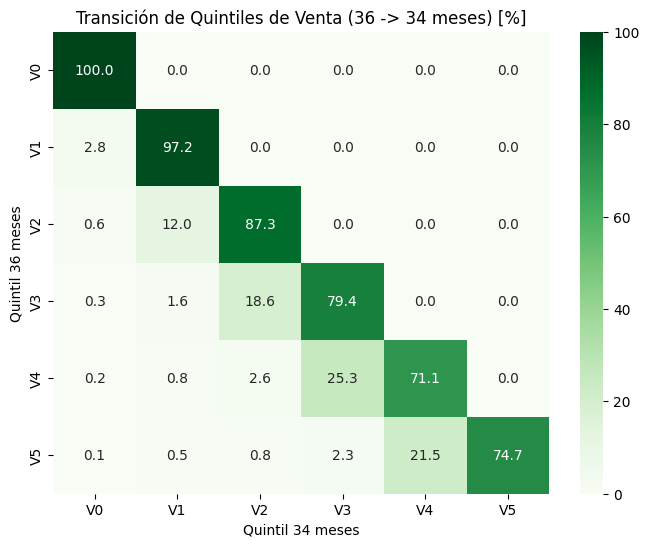

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crear tabla de transición en valores absolutos
transicion = df_merge.groupby(['Venta_Q36', 'Venta_Q34']).size().unstack(fill_value=0)

# Normalizar por fila (porcentaje de transición desde cada quintil original)
transicion_pct = transicion.div(transicion.sum(axis=1), axis=0) * 100  # convierte a porcentaje

# Graficar heatmap en porcentaje
plt.figure(figsize=(8,6))
sns.heatmap(transicion_pct, annot=True, fmt='.1f', cmap="Greens")

plt.title('Transición de Quintiles de Venta (36 -> 34 meses) [%]')
plt.xlabel('Quintil 34 meses')
plt.ylabel('Quintil 36 meses')
plt.show()



### Frecuencia


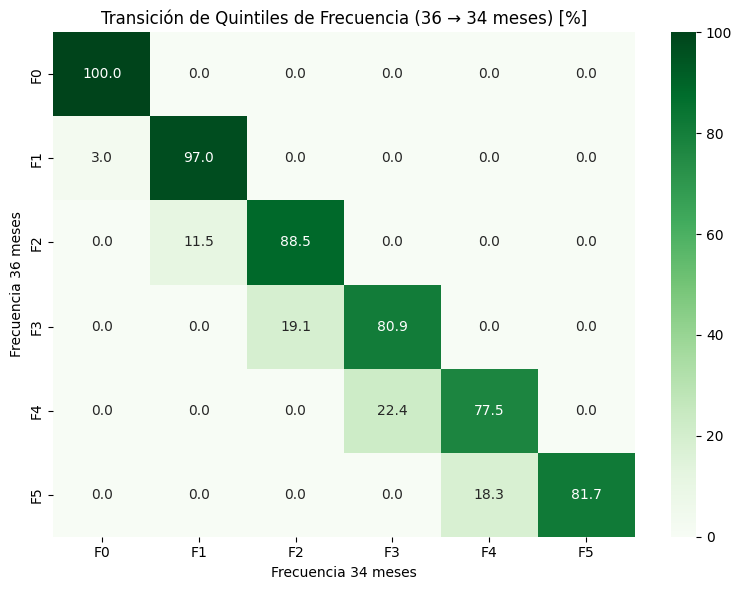

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Matriz de transición en valores absolutos
frecuencia_transicion = pd.crosstab(df_merge['Frecuencia_Q36'], df_merge['Frecuencia_Q34'])

# Normalizar por fila (porcentajes)
frecuencia_transicion_pct = frecuencia_transicion.div(frecuencia_transicion.sum(axis=1), axis=0) * 100

# Graficar heatmap en porcentaje
plt.figure(figsize=(8, 6))
sns.heatmap(frecuencia_transicion_pct, annot=True, fmt='.1f', cmap="Greens")

plt.title("Transición de Quintiles de Frecuencia (36 → 34 meses) [%]")
plt.xlabel("Frecuencia 34 meses")
plt.ylabel("Frecuencia 36 meses")
plt.tight_layout()
plt.show()



### Frescura

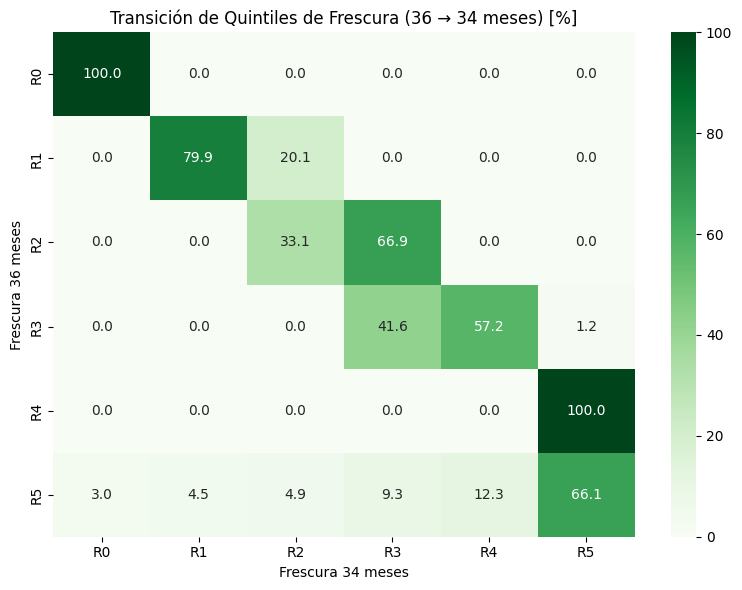

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Matriz de transición en valores absolutos
frescura_transicion = pd.crosstab(df_merge['Frescura_Q36'], df_merge['Frescura_Q34'])

# Normalizar por fila (porcentajes)
frescura_transicion_pct = frescura_transicion.div(frescura_transicion.sum(axis=1), axis=0) * 100

# Heatmap con porcentajes
plt.figure(figsize=(8, 6))
sns.heatmap(frescura_transicion_pct, annot=True, fmt='.1f', cmap="Greens")

plt.title("Transición de Quintiles de Frescura (36 → 34 meses) [%]")
plt.xlabel("Frescura 34 meses")
plt.ylabel("Frescura 36 meses")
plt.tight_layout()
plt.show()



### Analisis de Sensibilidad para cada Segmento (Modificar Quintiles en Caso de Cambio)

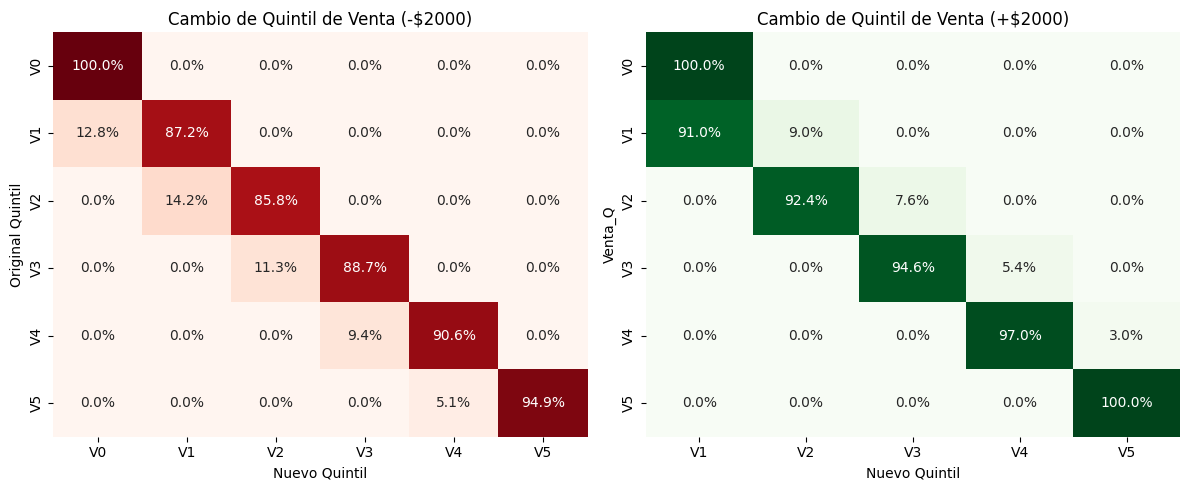

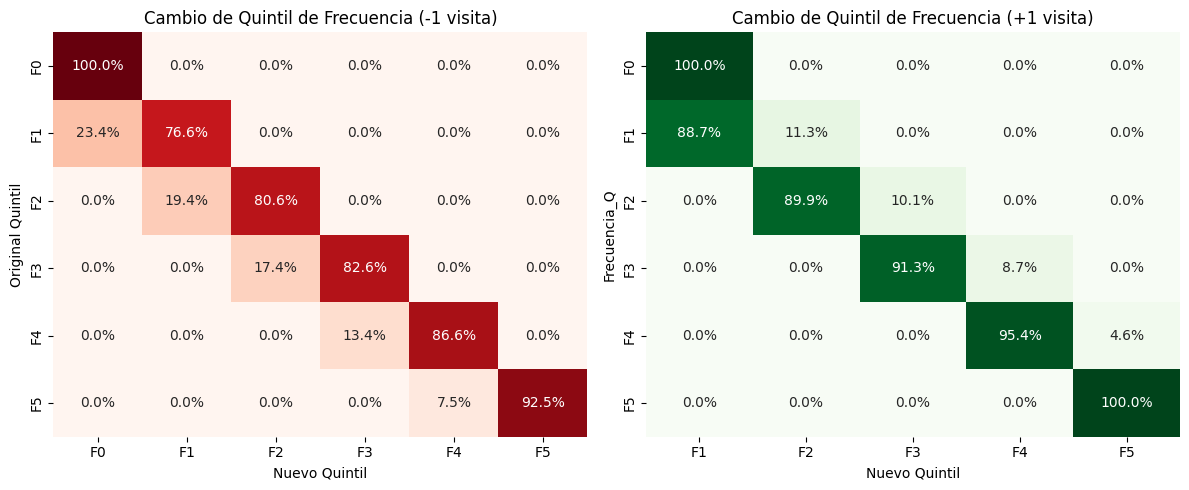

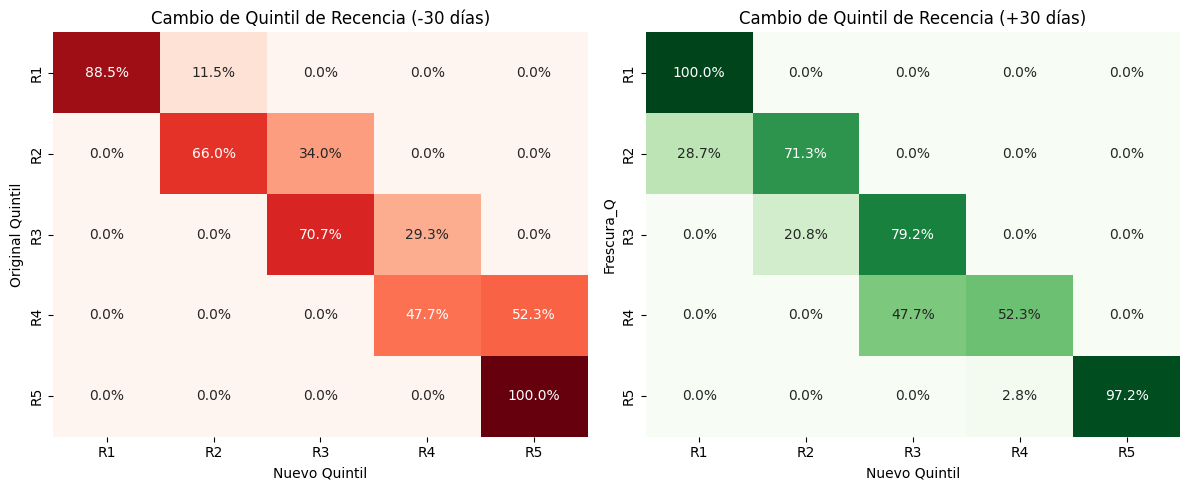

✅ Archivo actualizado con columnas de simulación (formato transición): .\Dataframes LM\Segmentos VFR.csv
Columnas añadidas: ['Venta_+2000', 'Venta_-2000', 'Frecuencia_+1', 'Frecuencia_-1', 'Frescura_+30d', 'Frescura_-30d']


In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

# ---------------------------
# FUNCIONES DE CLASIFICACIÓN
# ---------------------------

def clasificar_venta(monto):
    if monto >= 96001:
        return 'V5'
    elif monto >= 61001:
        return 'V4'
    elif monto >= 36001:
        return 'V3'
    elif monto >= 17001:
        return 'V2'
    elif monto >= 1:
        return 'V1'
    else:
        return 'V0'

def clasificar_frecuencia(freq):
    if freq >= 34:
        return 'F5'
    elif freq >= 22:
        return 'F4'
    elif freq >= 14:
        return 'F3'
    elif freq >= 7:
        return 'F2'
    elif freq >= 1:
        return 'F1'
    else:
        return 'F0'

def clasificar_frescura(dias):
    if dias >= 366:
        return 'R1'
    elif dias >= 271:
        return 'R2'
    elif dias >= 151:
        return 'R3'
    elif dias >= 91:
        return 'R4'
    elif dias >= 0:
        return 'R5'
    else:
        return 'R0'

# --- Cargar el archivo base ---
input_path = r".\Dataframes LM\Segmentos VFR.csv"
df = pd.read_csv(input_path, encoding='utf-8-sig')

# Convert relevant columns to numeric, coercing errors to NaN
df['Suma de Vta Total'] = pd.to_numeric(df['Suma de Vta Total'], errors='coerce')
df['Recuento de Fecha'] = pd.to_numeric(df['Recuento de Fecha'], errors='coerce')

# Fecha de corte para cálculos
fecha_corte = pd.to_datetime(df['Última fecha: Fecha'], errors='coerce').max()

# ---------------------------
# PREPARACIÓN DE DATOS
# ---------------------------

# Calcular frescura en días (desde última compra hasta fecha corte)
df['Última fecha: Fecha'] = pd.to_datetime(df['Última fecha: Fecha'], errors='coerce')
df['Frescura_dias'] = (fecha_corte - df['Última fecha: Fecha']).dt.days
df['Frescura_dias'] = df['Frescura_dias'].fillna(0).astype(int)

# Clasificaciones originales
df['Venta_Q'] = df['Suma de Vta Total'].apply(clasificar_venta)
df['Frecuencia_Q'] = df['Recuento de Fecha'].apply(clasificar_frecuencia)
df['Frescura_Q'] = df['Frescura_dias'].apply(clasificar_frescura)

# ---------------------------------------------
# SIMULACIÓN PARA VENTA: +/- 2000 pesos
# ---------------------------------------------
df['Venta_menos'] = df['Suma de Vta Total'] - 2000
df['Venta_mas'] = df['Suma de Vta Total'] + 2000

df['Venta_Q_menos'] = df['Venta_menos'].apply(clasificar_venta)
df['Venta_Q_mas'] = df['Venta_mas'].apply(clasificar_venta)

# Heatmaps para venta
venta_menos = pd.crosstab(df['Venta_Q'], df['Venta_Q_menos'], normalize='index')
venta_mas = pd.crosstab(df['Venta_Q'], df['Venta_Q_mas'], normalize='index')

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(venta_menos, annot=True, cmap="Reds", fmt=".1%", cbar=False)
plt.title('Cambio de Quintil de Venta (-$2000)')
plt.xlabel('Nuevo Quintil')
plt.ylabel('Original Quintil')

plt.subplot(1, 2, 2)
sns.heatmap(venta_mas, annot=True, cmap="Greens", fmt=".1%", cbar=False)
plt.title('Cambio de Quintil de Venta (+$2000)')
plt.xlabel('Nuevo Quintil')
plt.tight_layout()
plt.show()

# ---------------------------------------------
# SIMULACIÓN PARA FRECUENCIA: +/- 1 visita
# ---------------------------------------------
df['Frecuencia_menos'] = df['Recuento de Fecha'] - 1
df['Frecuencia_mas'] = df['Recuento de Fecha'] + 1

df['Frecuencia_Q_menos'] = df['Frecuencia_menos'].apply(clasificar_frecuencia)
df['Frecuencia_Q_mas'] = df['Frecuencia_mas'].apply(clasificar_frecuencia)

# Heatmaps para frecuencia
freq_menos = pd.crosstab(df['Frecuencia_Q'], df['Frecuencia_Q_menos'], normalize='index')
freq_mas = pd.crosstab(df['Frecuencia_Q'], df['Frecuencia_Q_mas'], normalize='index')

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(freq_menos, annot=True, cmap="Reds", fmt=".1%", cbar=False)
plt.title('Cambio de Quintil de Frecuencia (-1 visita)')
plt.xlabel('Nuevo Quintil')
plt.ylabel('Original Quintil')

plt.subplot(1, 2, 2)
sns.heatmap(freq_mas, annot=True, cmap="Greens", fmt=".1%", cbar=False)
plt.title('Cambio de Quintil de Frecuencia (+1 visita)')
plt.xlabel('Nuevo Quintil')
plt.tight_layout()
plt.show()

# ---------------------------------------------
# SIMULACIÓN PARA FRESCURA: +/- 30 días
# ---------------------------------------------
df['Frescura_menos'] = df['Frescura_dias'] - 30
df['Frescura_mas'] = df['Frescura_dias'] + 30

# Asegurar que no hay valores negativos
df['Frescura_menos'] = df['Frescura_menos'].clip(lower=0)
df['Frescura_mas'] = df['Frescura_mas'].clip(lower=0)

df['Frescura_Q_menos'] = df['Frescura_menos'].apply(clasificar_frescura)
df['Frescura_Q_mas'] = df['Frescura_mas'].apply(clasificar_frescura)

# Heatmaps para frescura
frescura_menos = pd.crosstab(df['Frescura_Q'], df['Frescura_Q_menos'], normalize='index')
frescura_mas = pd.crosstab(df['Frescura_Q'], df['Frescura_Q_mas'], normalize='index')

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(frescura_menos, annot=True, cmap="Reds", fmt=".1%", cbar=False)
plt.title('Cambio de Quintil de Recencia (-30 días)')
plt.xlabel('Nuevo Quintil')
plt.ylabel('Original Quintil')

plt.subplot(1, 2, 2)
sns.heatmap(frescura_mas, annot=True, cmap="Greens", fmt=".1%", cbar=False)
plt.title('Cambio de Quintil de Recencia (+30 días)')
plt.xlabel('Nuevo Quintil')
plt.tight_layout()
plt.show()

if 'Venta_+2000' in df.columns:
    df = df.drop(columns=['Venta_+2000'])
if 'Venta_-2000' in df.columns:
    df = df.drop(columns=['Venta_-2000'])
if 'Frecuencia_+1' in df.columns:
    df = df.drop(columns=['Frecuencia_+1'])
if 'Frecuencia_-1' in df.columns:
    df = df.drop(columns=['Frecuencia_-1'])
if 'Frescura_+30d' in df.columns:
    df = df.drop(columns=['Frescura_+30d'])
if 'Frescura_-30d' in df.columns:
    df = df.drop(columns=['Frescura_-30d'])


# --- Añadir columnas de transición al archivo original ---
df['Venta_+2000'] = df['Venta_Q'] + ' -> ' + df['Venta_Q_mas']
df['Venta_-2000'] = df['Venta_Q'] + ' -> ' + df['Venta_Q_menos']
df['Frecuencia_+1'] = df['Frecuencia_Q'] + ' -> ' + df['Frecuencia_Q_mas']
df['Frecuencia_-1'] = df['Frecuencia_Q'] + ' -> ' + df['Frecuencia_Q_menos']
df['Frescura_+30d'] = df['Frescura_Q'] + ' -> ' + df['Frescura_Q_mas']
df['Frescura_-30d'] = df['Frescura_Q'] + ' -> ' + df['Frescura_Q_menos']

df = df.drop(columns=['Venta_menos', 'Venta_mas', 'Frecuencia_menos', 'Frecuencia_mas', 'Frescura_menos', 'Frescura_mas','Frecuencia_Q_menos', 'Frescura_Q_mas'])
df = df.drop(columns=['Venta_Q_menos', 'Venta_Q_mas', 'Frescura_Q_menos', 'Venta_Q','Frecuencia_Q','Frescura_Q','Frecuencia_Q_mas'])
df.drop_duplicates(inplace=True)
# --- Guardar el archivo actualizado ---
df.to_csv(input_path, index=False, encoding='utf-8-sig')

print("✅ Archivo actualizado con columnas de simulación (formato transición):", input_path)
print("Columnas añadidas:", list(df.columns[-6:]))  # Muestra las 6 nuevas columnas

In [18]:
df = pd.read_csv('.\Dataframes LM\Segmentos VFR.csv', encoding='utf-8-sig')

df['Segmento_RFM'] = df['Segmento_RFM'].fillna('Dato no disponible')
df['Calificacion_Segmento'] = df['Calificacion_Segmento'].fillna('Dato no disponible')

df.to_csv('.\Dataframes LM\Segmentos VFR.csv', index=False, encoding='utf-8-sig')


# CALCULO DE QUINTILES DEL AÑO 2022 AL AÑO 2025 (EB)

### Calculo de Quintiles en Rangos Univariables

In [19]:
# Código Optimizado y Corregido para Clustering RFM
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, MiniBatchKMeans, Birch
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

# ================================
# 1. Cargar y preparar datos (optimizado y corregido)
# ================================
def load_and_prepare_data(filepath):
    """Carga y prepara los datos con optimización de memoria y manejo de NaN"""
    # Cargar solo columnas necesarias
    cols = ['Suma de Vta Total', 'Recuento de Fecha', 'Última fecha: Fecha']
    df = pd.read_csv(filepath, encoding='latin1', usecols=cols)
    
    # Convertir tipos de datos para ahorrar memoria
    df['Suma de Vta Total'] = pd.to_numeric(df['Suma de Vta Total'], errors='coerce').astype('float32')
    df['Recuento de Fecha'] = pd.to_numeric(df['Recuento de Fecha'], errors='coerce').astype('float32')
    df['Última fecha: Fecha'] = pd.to_datetime(df['Última fecha: Fecha'], errors='coerce', format='%Y-%m-%d')
    
    # Calcular frescura en días con manejo de NaN
    fecha_base =  df['Última fecha: Fecha'].max()
    df['Frescura (días)'] = (fecha_base - df['Última fecha: Fecha']).dt.days
    
    # Filtrar datos válidos (eliminar NaN antes de convertir a int)
    df = df[
        (df['Suma de Vta Total'] > 0) & 
        (df['Recuento de Fecha'] > 0) & 
        (df['Frescura (días)'].notna()) &  # Añadido para manejar NaN
        (df['Frescura (días)'] > 0)
    ].copy()
    
    # Ahora podemos convertir a int de manera segura
    df['Frescura (días)'] = df['Frescura (días)'].astype('int16')
    
    # Eliminar outliers (percentil 99)
    for col in ['Suma de Vta Total', 'Recuento de Fecha']:
        q99 = df[col].quantile(0.99)
        df = df[df[col] <= q99]
    
    df = df[df['Frescura (días)'] <= 366]
    
    return df

# ================================
# 2. Función de clustering optimizada
# ================================
def optimized_cluster(series, method='minibatch', n_clusters=5, random_state=42):
    """
    Clustering optimizado con:
    - Escalado de datos
    - Elección de método
    - Manejo eficiente de memoria
    """
    # Validar y preparar datos
    valid_values = series.dropna().values.reshape(-1, 1)
    if len(valid_values) == 0:
        return None
    
    # Escalar datos
    scaler = StandardScaler()
    scaled_values = scaler.fit_transform(valid_values)
    
    # Seleccionar modelo
    if method == 'kmeans':
        model = KMeans(n_clusters=n_clusters, random_state=random_state, n_init='auto')
    elif method == 'minibatch':
        model = MiniBatchKMeans(
            n_clusters=n_clusters, 
            random_state=random_state, 
            batch_size=1024,
            n_init=5
        )
    elif method == 'birch':
        model = Birch(n_clusters=n_clusters, threshold=0.5)
    else:
        raise ValueError("Método no válido. Usar 'kmeans', 'minibatch' o 'birch'.")
    
    # Entrenar modelo
    clusters = model.fit_predict(scaled_values)
    
    # Crear DataFrame con resultados
    temp_df = pd.DataFrame({
        'value': valid_values.flatten(),
        'cluster': clusters
    })
    
    # Calcular rangos
    ranges = temp_df.groupby('cluster')['value'].agg(['min', 'max']).reset_index()
    ranges = ranges.sort_values('min').reset_index(drop=True)
    ranges['label'] = [f'R{i}' for i in range(len(ranges))]
    
    return ranges

# ================================
# 3. Función para generar rangos
# ================================
def obtener_rangos(rangos_df, start_from_zero=False):
    """Genera tuplas de rangos desde el formato de clusters"""
    tuplas = []
    rangos_df = rangos_df.sort_values('min').reset_index(drop=True)
    
    for idx, row in rangos_df.iterrows():
        if idx == len(rangos_df) - 1:
            break  # Ignorar el último rango
        
        if idx == 0:
            minimo = 0 if start_from_zero else 1
        else:
            minimo = int(rangos_df.loc[idx - 1, 'max']) + 1
        
        tuplas.append((minimo, int(row['max'])))
    
    return tuplas

# ================================
# 4. Procesamiento principal
# ================================
def main(file_path):
    # Cargar datos
    print("Cargando y preparando datos...")
    df = load_and_prepare_data(file_path)
    
    # Columnas a clusterizar
    columns_to_cluster = {
        'Suma de Vta Total': False,
        'Recuento de Fecha': False,
        'Frescura (días)': True
    }
    
    # Métodos a aplicar
    methods = ['kmeans', 'minibatch', 'birch']
    results = {}
    
    print("\nProcesando clustering...")
    for col, start_zero in columns_to_cluster.items():
        results[col] = {}
        for method in tqdm(methods, desc=f"Clusterizando {col}"):
            ranges = optimized_cluster(df[col], method=method)
            if ranges is not None:
                results[col][method] = obtener_rangos(ranges, start_from_zero=start_zero)
    
    # Mostrar resultados
    print("\n=== Resultados Finales ===")
    for col in columns_to_cluster:
        print(f"\n● Variable: {col}")
        for method in methods:
            if method in results[col]:
                print(f"\nMétodo: {method.upper()}")
                print(results[col][method])
    
    return results

# ================================
# 5. Ejecución
# ================================
if __name__ == "__main__":
    # Cambia esta ruta por tu archivo real
    file_path = r".\Dataframes EB\Acumulado36meses.csv"
    
    # Ejecutar proceso principal
    resultados = main(file_path)

Cargando y preparando datos...



Procesando clustering...



Clusterizando Suma de Vta Total:   0%|                                                           | 0/3 [00:00<?, ?it/s]


Clusterizando Suma de Vta Total:  67%|██████████████████████████████████                 | 2/3 [00:00<00:00, 14.61it/s]


Clusterizando Suma de Vta Total: 100%|███████████████████████████████████████████████████| 3/3 [00:01<00:00,  2.63it/s]

...


Clusterizando Recuento de Fecha: 100%|███████████████████████████████████████████████████| 3/3 [00:01<00:00,  2.57it/s]


Clusterizando Frescura (días):   0%|                                                             | 0/3 [00:00<?, ?it/s]


Clusterizando Frescura (días):  67%|███████████████████████████████████▎                 | 2/3 [00:00<00:00, 12.99it/s]


Clusterizando Frescura (días): 100%|█████████████████████████████████████████████████████| 3/3 [00:01<00:00,  2.70it/s]


=== Resultados Finales ===

● Variable: Suma de Vta Total

Método: KMEANS
[(1, 9806), (9807, 19456), (19457, 30988), (30989, 46487)]

Método: MINIBATCH
[(1, 9707), (9708, 19296), (19297, 30822), (30823, 46420)]

Método: BIRCH
[(1, 14407), (14408, 28580), (28581, 45842)]

● Variable: Recuento de Fecha

Método: KMEANS
[(1, 2), (3, 3), (4, 5), (6, 7)]

Método: MINIBATCH
[(1, 1), (2, 3), (4, 5), (6, 8)]

Método: BIRCH
[(1, 2), (3, 5), (6, 7), (8, 10)]

● Variable: Frescura (días)

Método: KMEANS
[(0, 46), (47, 110), (111, 188), (189, 274)]

Método: MINIBATCH
[(0, 65), (66, 137), (138, 212), (213, 289)]

Método: BIRCH
[(0, 96), (97, 219)]


### Funciones para Calcular Quintiles de 36 y 34 meses Respectivamente

In [20]:
import pandas as pd
import numpy as np

custom_ranges_value = [(1, 15000), (15001, 30000), (30001,60000),(60001,90000)]  # Rango de 1-7000 y 7001-14000
custom_ranges_freq = [(1, 7), (8, 22),(23, 29),(30,37)]  # Ejemplo para frecuencia (ajústalo según sea necesario)
custom_ranges_freshness = [(0, 90),(91,180),(181,270),(271,365)]  # Frescura con un rango personalizado


def process_data1(custom_ranges_value, custom_ranges_freq, custom_ranges_freshness):
        # Cargar el archivo CSV
        file_path = r".\Dataframes EB\Acumulado36meses.csv"
        df = pd.read_csv(file_path, encoding='latin1')  # Prueba con 'latin1' o 'ISO-8859-1'
        # Asignar nulo a 'Recuento de Fecha' donde 'Suma de Vta Total' es nulo
        #df.loc[df['Suma de Vta Total'].isna(), 'Recuento de Fecha'] = 0
        #df['Suma de Vta Total'] = df['Suma de Vta Total'].fillna(0)

        # Asegurarse de que las columnas están en el formato correcto
        df['Suma de Vta Total'] = pd.to_numeric(df['Suma de Vta Total'], errors='coerce')
        df['Recuento de Fecha'] = pd.to_numeric(df['Recuento de Fecha'], errors='coerce')

        # Contar cuántos valores tienen '-'
        count_missing_freshness = df[df['Última fecha: Fecha'] == '-'].shape[0]

        # Convertir las columnas de fecha a datetime, manejar errores y especificar formato si es conocido
        df['Última fecha: Fecha'] = pd.to_datetime(df['Última fecha: Fecha'], errors='coerce', format='%Y-%m-%d')  # Ajusta el formato según sea necesario


        # Calcular los días de frescura como la diferencia entre la fecha actual y la última fecha de compra
        fecha_actual = pd.Timestamp.now()  # Obtener la fecha actual
        fecha_especifica = df['Última fecha: Fecha'].max()  # Año-Mes-Día
        df['Frescura (días)'] = (fecha_especifica - df['Última fecha: Fecha']).dt.days

        # Eliminar valores negativos en la frescura (pueden ser errores en los datos)
        #df = df[df['Frescura (días)'] >= 0]

        # Función para calcular rangos de igual anchura con exclusión de valores repetidos

        # Modificar función para ajustar el primer intervalo
        def calculate_equal_width_ranges(series, num_bins, use_custom_round=False, start_at_one=False):
            series = series.dropna()  # Eliminar valores NaN
            min_val = series.min()
            max_val = series.max()
            bin_width = (max_val - min_val) / num_bins
            
            if start_at_one:
                intervals = [(1, 1 + bin_width - 1)]
                intervals += [(1 + i * bin_width, 1 + (i + 1) * bin_width - 1) for i in range(1, num_bins)]
            else:
                intervals = [(min_val + i * bin_width, min_val + (i + 1) * bin_width - 1) for i in range(num_bins)]
            
            intervals[-1] = (intervals[-1][0], max_val)  # Ajustar el último intervalo para incluir el valor máximo
            def custom_round(x):
                if x - int(x) >= 0.5:
                    return int(np.ceil(x))
                else:
                    return int(np.floor(x))
            if use_custom_round:
                rounded_intervals = [(custom_round(start), custom_round(end)) for start, end in intervals]
            else:
                rounded_intervals = [(round(start, 2), round(end, 2)) for start, end in intervals]
            
            return min_val, max_val, rounded_intervals



        # Modificar función para permitir múltiples rangos customizados
        def calculate_custom_ranges(series, custom_ranges, num_bins, use_custom_round=False):
            series = series.dropna()
            
            all_custom_ranges = []
            for custom_start, custom_end in custom_ranges:
                custom_range = [(custom_start, custom_end)]
                all_custom_ranges += custom_range
            
            # Asumiendo que calculate_equal_width_ranges retorna min_val, max_val, y ranges
            remaining_series = series[series > custom_ranges[-1][1]]
            remaining_min, remaining_max, remaining_ranges = calculate_equal_width_ranges(remaining_series, num_bins - len(custom_ranges), use_custom_round)
            
            # Combinar los rangos personalizados con los rangos calculados
            all_ranges = all_custom_ranges + remaining_ranges

            # Devolver min, max y todos los rangos (custom_start será el mínimo y remaining_max el máximo)
            return custom_ranges[0][0], remaining_max, all_ranges

        # Definir los rangos personalizados que quieres
        


        # El resto del código sigue igual, contando en intervalos, asignando etiquetas, y guardando los resultados.


        # Número de intervalos que quieres crear
        num_bins = 5

        # Calcular rangos para cada columna relevante
        value_min, value_max, value_ranges = calculate_equal_width_ranges(df['Suma de Vta Total'], num_bins, use_custom_round=False, start_at_one=True)
        freq_min, freq_max, freq_ranges = calculate_equal_width_ranges(df['Recuento de Fecha'], num_bins, use_custom_round=True, start_at_one=True)
        freshness_min, freshness_max, freshness_ranges = calculate_equal_width_ranges(df['Frescura (días)'], num_bins, use_custom_round=True)
        # Calcular rangos personalizados para 'Suma de Vta Total'
        value_min, value_max, value_ranges = calculate_custom_ranges(df['Suma de Vta Total'], custom_ranges_value, num_bins, use_custom_round=True)

        # También podrías modificar 'Recuento de Fecha' o 'Frescura (días)' si es necesario
        freq_min, freq_max, freq_ranges = calculate_custom_ranges(df['Recuento de Fecha'], custom_ranges_freq, num_bins, use_custom_round=True)
        freshness_min, freshness_max, freshness_ranges = calculate_custom_ranges(df['Frescura (días)'], custom_ranges_freshness, num_bins, use_custom_round=True)
        
        # Función para contar las cuentas dentro de cada intervalo
        def count_in_intervals(series, intervals):
            counts = []
            for start, end in intervals:
                count = series[(series >= start) & (series <= end)].count()
                counts.append(count)
            return counts

        # Agregar intervalo extra que cubra desde 0 hasta el inicio del primer intervalo
        def add_zero_interval(ranges):
            # Añadir intervalo 0 - 0 antes del primer intervalo
            intervals = [(0, 0)] + ranges
            return intervals

        # Agregar el intervalo extra para cada conjunto de rangos
        value_ranges_with_zero = add_zero_interval(value_ranges)
        freq_ranges_with_zero = add_zero_interval(freq_ranges)
        freshness_ranges_with_zero = add_zero_interval(freshness_ranges)

        # Filtrar el rango de frescura para eliminar (0, 0)
        #freshness_ranges_with_zero = [interval for interval in freshness_ranges_with_zero if interval != (0, 0)]

        # Contar el número de cuentas en cada intervalo
        value_counts = count_in_intervals(df['Suma de Vta Total'], value_ranges_with_zero)
        freq_counts = count_in_intervals(df['Recuento de Fecha'], freq_ranges_with_zero)
        freshness_counts = count_in_intervals(df['Frescura (días)'], freshness_ranges_with_zero)

        # Crear DataFrames para mostrar los resultados con los conteos
        value_df = pd.DataFrame({
            'Intervalo': [f'{value_ranges_with_zero[i][0]} - {value_ranges_with_zero[i][1]}' for i in range(len(value_ranges_with_zero))],
            'Mínimo': [value_ranges_with_zero[i][0] for i in range(len(value_ranges_with_zero))],
            'Máximo': [value_ranges_with_zero[i][1] for i in range(len(value_ranges_with_zero))],
            'Cuentas': value_counts
        })

        freq_df = pd.DataFrame({
            'Intervalo': [f'{freq_ranges_with_zero[i][0]} - {freq_ranges_with_zero[i][1]}' for i in range(len(freq_ranges_with_zero))],
            'Mínimo': [freq_ranges_with_zero[i][0] for i in range(len(freq_ranges_with_zero))],
            'Máximo': [freq_ranges_with_zero[i][1] for i in range(len(freq_ranges_with_zero))],
            'Cuentas': freq_counts
        })

        freshness_df = pd.DataFrame({
            'Intervalo': [f'{freshness_ranges_with_zero[i][0]} - {freshness_ranges_with_zero[i][1]}' for i in range(len(freshness_ranges_with_zero))],
            'Mínimo': [freshness_ranges_with_zero[i][0] for i in range(len(freshness_ranges_with_zero))],
            'Máximo': [freshness_ranges_with_zero[i][1] for i in range(len(freshness_ranges_with_zero))],
            'Cuentas': freshness_counts
        })



        # Convertir las columnas 'Mínimo' y 'Máximo' a tipo string
        freshness_df['Mínimo'] = freshness_df['Mínimo'].astype(str)
        freshness_df['Máximo'] = freshness_df['Máximo'].astype(str)
        freshness_df['Intervalo'] = freshness_df['Intervalo'].astype(str)
        freshness_df['Cuentas'] = freshness_df['Cuentas'].astype(str)

        # Modificar el DataFrame 'freshness_df' para actualizar la primera fila
        freshness_df.at[0, 'Intervalo'] = '-'
        freshness_df.at[0, 'Mínimo'] = '-'
        freshness_df.at[0, 'Máximo'] = '-'
        freshness_df.at[0, 'Cuentas'] =  count_missing_freshness


        # Convertir la columna 'Cuentas' a tipo numérico, forzando errores a NaN y luego eliminándolos
        value_df['Cuentas'] = pd.to_numeric(value_df['Cuentas'], errors='coerce')
        freq_df['Cuentas'] = pd.to_numeric(freq_df['Cuentas'], errors='coerce')
        freshness_df['Cuentas'] = pd.to_numeric(freshness_df['Cuentas'], errors='coerce')

        # Calcular y agregar la columna de porcentajes para cada DataFrame
        value_df['Total Cuentas'] = value_df['Cuentas'].sum()
        value_df['Porcentaje'] = (value_df['Cuentas'] / value_df['Total Cuentas']) * 100
        value_df['Porcentaje'] = value_df['Porcentaje'].round(2)  # Redondear a 1 decimal
        value_df.drop('Total Cuentas', axis=1, inplace=True)

        freq_df['Total Cuentas'] = freq_df['Cuentas'].sum()
        freq_df['Porcentaje'] = (freq_df['Cuentas'] / freq_df['Total Cuentas']) * 100
        freq_df['Porcentaje'] = freq_df['Porcentaje'].round(2)  # Redondear a 1 decimal
        freq_df.drop('Total Cuentas', axis=1, inplace=True)

        freshness_df['Total Cuentas'] = freshness_df['Cuentas'].sum()
        freshness_df['Porcentaje'] = (freshness_df['Cuentas'] / freshness_df['Total Cuentas']) * 100
        freshness_df['Porcentaje'] = freshness_df['Porcentaje'].round(2)  # Redondear a 1 decimal
        freshness_df.drop('Total Cuentas', axis=1, inplace=True)
        freshness_df = freshness_df.iloc[::-1].reset_index(drop=True)
        freshness_df.index = range(len(freshness_df)-1, -1, -1)
        # Ordenar los DataFrames por la columna 'Máximo' en orden descendente

        value_df_sorted_max = value_df.sort_values(by='Máximo', ascending=False)
        freq_df_sorted_max = freq_df.sort_values(by='Máximo', ascending=False)



        # Mostrar resultados ordenados por 'Máximo'
        print("Rangos del Valor de Compra:")
        print(value_df_sorted_max)
        total_cuentas = value_df['Cuentas'].sum()
        print(f"El total de cuentas es: {total_cuentas}")
        print("\nRangos de la Frecuencia de Visita:")
        print(freq_df_sorted_max)
        total_cuentas = freq_df['Cuentas'].sum()
        print(f"El total de cuentas es: {total_cuentas}")
        print("\nRangos de la Frescura:")
        print(freshness_df)
        total_cuentas = freshness_df['Cuentas'].sum()
        print(f"El total de cuentas es: {total_cuentas}")
        df.fillna({'Frescura (días)': '-'}, inplace=True)
        def replace_zero_range(ranges):
            # Reemplaza el rango (0, 0) por ("-", "-")
            return [("-", "-") if r == (0, 0) else r for r in ranges]

        # Llamar a la función para hacer el reemplazo
        freshness_ranges_with_zero = replace_zero_range(freshness_ranges_with_zero)

        # Define tu función classify_data
        def classify_data(value, ranges, labels):
            # Manejar el caso donde el valor es "-"
            if value == "-":
                return "R0"  # Clasificación especial para guiones

            # Intentar convertir el valor a float
            try:
                value = float(value)
            except ValueError:
                return None  # O un valor por defecto si la conversión falla

            # Clasificación según los rangos
            for (start, end), label in zip(ranges, labels):
                # Comprobar que start y end son números
                if start != "-" and end != "-":
                    if start <= value <= end:
                        return label

            return None  # O un valor por defecto si no se encuentra en ningún rango
        # Asignar etiquetas a los intervalos
        value_labels = [f'V{i}' for i in range(len(value_ranges_with_zero))]
        freq_labels = [f'F{i}' for i in range(len(freq_ranges_with_zero))]
        #freshness_labels = [f'R{i}' for i in range(len(freshness_ranges_with_zero))]
        freshness_labels = ['R0', 'R5', 'R4', 'R3', 'R2', 'R1']
        # Clasificar los datos y asignar etiquetas
        df['ETIQ1'] = df['Suma de Vta Total'].apply(lambda x: classify_data(x, value_ranges_with_zero, value_labels))
        df['ETIQ2'] = df['Recuento de Fecha'].apply(lambda x: classify_data(x, freq_ranges_with_zero, freq_labels))
        df['ETIQ3'] = df['Frescura (días)'].apply(lambda x: classify_data(x, freshness_ranges_with_zero, freshness_labels))
        #print(freshness_ranges_with_zero)
        #print(freshness_labels)
        # Guardar los resultados en un archivo CSV con las columnas CUENTA, ETIQ1, ETIQ2, ETIQ3
        output_file_path = r".\Dataframes EB\Segmentos VFR.csv"
        df.to_csv(output_file_path, index=False, encoding='utf-8-sig')

#process_data(custom_ranges_value, custom_ranges_freq, custom_ranges_freshness)

In [21]:
import pandas as pd
import numpy as np

custom_ranges_value = [(1, 15000), (15001, 30000), (30001,60000),(60001,90000)]  # Rango de 1-7000 y 7001-14000
custom_ranges_freq = [(1, 7), (8, 22),(23, 29),(30,37)]  # Ejemplo para frecuencia (ajústalo según sea necesario)
custom_ranges_freshness = [(0, 90),(91,180),(181,270),(271,365)]  # Frescura con un rango personalizado


def process_data2(custom_ranges_value, custom_ranges_freq, custom_ranges_freshness):
        # Cargar el archivo CSV
        file_path = r".\Dataframes EB\Acumulado34meses.csv"
        df = pd.read_csv(file_path, encoding='latin1')  # Prueba con 'latin1' o 'ISO-8859-1'
        # Asignar nulo a 'Recuento de Fecha' donde 'Suma de Vta Total' es nulo
        #df.loc[df['Suma de Vta Total'].isna(), 'Recuento de Fecha'] = 0
        #df['Suma de Vta Total'] = df['Suma de Vta Total'].fillna(0)

        # Asegurarse de que las columnas están en el formato correcto
        df['Suma de Vta Total'] = pd.to_numeric(df['Suma de Vta Total'], errors='coerce')
        df['Recuento de Fecha'] = pd.to_numeric(df['Recuento de Fecha'], errors='coerce')

        # Contar cuántos valores tienen '-'
        count_missing_freshness = df[df['Última fecha: Fecha'] == '-'].shape[0]

        # Convertir las columnas de fecha a datetime, manejar errores y especificar formato si es conocido
        df['Última fecha: Fecha'] = pd.to_datetime(df['Última fecha: Fecha'], errors='coerce', format='%Y-%m-%d')  # Ajusta el formato según sea necesario


        # Calcular los días de frescura como la diferencia entre la fecha actual y la última fecha de compra
        fecha_actual = pd.Timestamp.now()  # Obtener la fecha actual
        fecha_especifica = df['Última fecha: Fecha'].max()  # Año-Mes-Día
        df['Frescura (días)'] = (fecha_especifica - df['Última fecha: Fecha']).dt.days

        # Eliminar valores negativos en la frescura (pueden ser errores en los datos)
        #df = df[df['Frescura (días)'] >= 0]

        # Función para calcular rangos de igual anchura con exclusión de valores repetidos

        # Modificar función para ajustar el primer intervalo
        def calculate_equal_width_ranges(series, num_bins, use_custom_round=False, start_at_one=False):
            series = series.dropna()  # Eliminar valores NaN
            min_val = series.min()
            max_val = series.max()
            bin_width = (max_val - min_val) / num_bins
            
            if start_at_one:
                intervals = [(1, 1 + bin_width - 1)]
                intervals += [(1 + i * bin_width, 1 + (i + 1) * bin_width - 1) for i in range(1, num_bins)]
            else:
                intervals = [(min_val + i * bin_width, min_val + (i + 1) * bin_width - 1) for i in range(num_bins)]
            
            intervals[-1] = (intervals[-1][0], max_val)  # Ajustar el último intervalo para incluir el valor máximo
            def custom_round(x):
                if x - int(x) >= 0.5:
                    return int(np.ceil(x))
                else:
                    return int(np.floor(x))
            if use_custom_round:
                rounded_intervals = [(custom_round(start), custom_round(end)) for start, end in intervals]
            else:
                rounded_intervals = [(round(start, 2), round(end, 2)) for start, end in intervals]
            
            return min_val, max_val, rounded_intervals



        # Modificar función para permitir múltiples rangos customizados
        def calculate_custom_ranges(series, custom_ranges, num_bins, use_custom_round=False):
            series = series.dropna()
            
            all_custom_ranges = []
            for custom_start, custom_end in custom_ranges:
                custom_range = [(custom_start, custom_end)]
                all_custom_ranges += custom_range
            
            # Asumiendo que calculate_equal_width_ranges retorna min_val, max_val, y ranges
            remaining_series = series[series > custom_ranges[-1][1]]
            remaining_min, remaining_max, remaining_ranges = calculate_equal_width_ranges(remaining_series, num_bins - len(custom_ranges), use_custom_round)
            
            # Combinar los rangos personalizados con los rangos calculados
            all_ranges = all_custom_ranges + remaining_ranges

            # Devolver min, max y todos los rangos (custom_start será el mínimo y remaining_max el máximo)
            return custom_ranges[0][0], remaining_max, all_ranges

        # Definir los rangos personalizados que quieres
        


        # El resto del código sigue igual, contando en intervalos, asignando etiquetas, y guardando los resultados.


        # Número de intervalos que quieres crear
        num_bins = 5

        # Calcular rangos para cada columna relevante
        value_min, value_max, value_ranges = calculate_equal_width_ranges(df['Suma de Vta Total'], num_bins, use_custom_round=False, start_at_one=True)
        freq_min, freq_max, freq_ranges = calculate_equal_width_ranges(df['Recuento de Fecha'], num_bins, use_custom_round=True, start_at_one=True)
        freshness_min, freshness_max, freshness_ranges = calculate_equal_width_ranges(df['Frescura (días)'], num_bins, use_custom_round=True)
        # Calcular rangos personalizados para 'Suma de Vta Total'
        value_min, value_max, value_ranges = calculate_custom_ranges(df['Suma de Vta Total'], custom_ranges_value, num_bins, use_custom_round=True)

        # También podrías modificar 'Recuento de Fecha' o 'Frescura (días)' si es necesario
        freq_min, freq_max, freq_ranges = calculate_custom_ranges(df['Recuento de Fecha'], custom_ranges_freq, num_bins, use_custom_round=True)
        freshness_min, freshness_max, freshness_ranges = calculate_custom_ranges(df['Frescura (días)'], custom_ranges_freshness, num_bins, use_custom_round=True)
        
        # Función para contar las cuentas dentro de cada intervalo
        def count_in_intervals(series, intervals):
            counts = []
            for start, end in intervals:
                count = series[(series >= start) & (series <= end)].count()
                counts.append(count)
            return counts

        # Agregar intervalo extra que cubra desde 0 hasta el inicio del primer intervalo
        def add_zero_interval(ranges):
            # Añadir intervalo 0 - 0 antes del primer intervalo
            intervals = [(0, 0)] + ranges
            return intervals

        # Agregar el intervalo extra para cada conjunto de rangos
        value_ranges_with_zero = add_zero_interval(value_ranges)
        freq_ranges_with_zero = add_zero_interval(freq_ranges)
        freshness_ranges_with_zero = add_zero_interval(freshness_ranges)

        # Filtrar el rango de frescura para eliminar (0, 0)
        #freshness_ranges_with_zero = [interval for interval in freshness_ranges_with_zero if interval != (0, 0)]

        # Contar el número de cuentas en cada intervalo
        value_counts = count_in_intervals(df['Suma de Vta Total'], value_ranges_with_zero)
        freq_counts = count_in_intervals(df['Recuento de Fecha'], freq_ranges_with_zero)
        freshness_counts = count_in_intervals(df['Frescura (días)'], freshness_ranges_with_zero)

        # Crear DataFrames para mostrar los resultados con los conteos
        value_df = pd.DataFrame({
            'Intervalo': [f'{value_ranges_with_zero[i][0]} - {value_ranges_with_zero[i][1]}' for i in range(len(value_ranges_with_zero))],
            'Mínimo': [value_ranges_with_zero[i][0] for i in range(len(value_ranges_with_zero))],
            'Máximo': [value_ranges_with_zero[i][1] for i in range(len(value_ranges_with_zero))],
            'Cuentas': value_counts
        })

        freq_df = pd.DataFrame({
            'Intervalo': [f'{freq_ranges_with_zero[i][0]} - {freq_ranges_with_zero[i][1]}' for i in range(len(freq_ranges_with_zero))],
            'Mínimo': [freq_ranges_with_zero[i][0] for i in range(len(freq_ranges_with_zero))],
            'Máximo': [freq_ranges_with_zero[i][1] for i in range(len(freq_ranges_with_zero))],
            'Cuentas': freq_counts
        })

        freshness_df = pd.DataFrame({
            'Intervalo': [f'{freshness_ranges_with_zero[i][0]} - {freshness_ranges_with_zero[i][1]}' for i in range(len(freshness_ranges_with_zero))],
            'Mínimo': [freshness_ranges_with_zero[i][0] for i in range(len(freshness_ranges_with_zero))],
            'Máximo': [freshness_ranges_with_zero[i][1] for i in range(len(freshness_ranges_with_zero))],
            'Cuentas': freshness_counts
        })



        # Convertir las columnas 'Mínimo' y 'Máximo' a tipo string
        freshness_df['Mínimo'] = freshness_df['Mínimo'].astype(str)
        freshness_df['Máximo'] = freshness_df['Máximo'].astype(str)
        freshness_df['Intervalo'] = freshness_df['Intervalo'].astype(str)
        freshness_df['Cuentas'] = freshness_df['Cuentas'].astype(str)

        # Modificar el DataFrame 'freshness_df' para actualizar la primera fila
        freshness_df.at[0, 'Intervalo'] = '-'
        freshness_df.at[0, 'Mínimo'] = '-'
        freshness_df.at[0, 'Máximo'] = '-'
        freshness_df.at[0, 'Cuentas'] =  count_missing_freshness


        # Convertir la columna 'Cuentas' a tipo numérico, forzando errores a NaN y luego eliminándolos
        value_df['Cuentas'] = pd.to_numeric(value_df['Cuentas'], errors='coerce')
        freq_df['Cuentas'] = pd.to_numeric(freq_df['Cuentas'], errors='coerce')
        freshness_df['Cuentas'] = pd.to_numeric(freshness_df['Cuentas'], errors='coerce')

        # Calcular y agregar la columna de porcentajes para cada DataFrame
        value_df['Total Cuentas'] = value_df['Cuentas'].sum()
        value_df['Porcentaje'] = (value_df['Cuentas'] / value_df['Total Cuentas']) * 100
        value_df['Porcentaje'] = value_df['Porcentaje'].round(2)  # Redondear a 1 decimal
        value_df.drop('Total Cuentas', axis=1, inplace=True)

        freq_df['Total Cuentas'] = freq_df['Cuentas'].sum()
        freq_df['Porcentaje'] = (freq_df['Cuentas'] / freq_df['Total Cuentas']) * 100
        freq_df['Porcentaje'] = freq_df['Porcentaje'].round(2)  # Redondear a 1 decimal
        freq_df.drop('Total Cuentas', axis=1, inplace=True)

        freshness_df['Total Cuentas'] = freshness_df['Cuentas'].sum()
        freshness_df['Porcentaje'] = (freshness_df['Cuentas'] / freshness_df['Total Cuentas']) * 100
        freshness_df['Porcentaje'] = freshness_df['Porcentaje'].round(2)  # Redondear a 1 decimal
        freshness_df.drop('Total Cuentas', axis=1, inplace=True)
        freshness_df = freshness_df.iloc[::-1].reset_index(drop=True)
        freshness_df.index = range(len(freshness_df)-1, -1, -1)
        # Ordenar los DataFrames por la columna 'Máximo' en orden descendente

        value_df_sorted_max = value_df.sort_values(by='Máximo', ascending=False)
        freq_df_sorted_max = freq_df.sort_values(by='Máximo', ascending=False)



        # Mostrar resultados ordenados por 'Máximo'
        print("Rangos del Valor de Compra:")
        print(value_df_sorted_max)
        total_cuentas = value_df['Cuentas'].sum()
        print(f"El total de cuentas es: {total_cuentas}")
        print("\nRangos de la Frecuencia de Visita:")
        print(freq_df_sorted_max)
        total_cuentas = freq_df['Cuentas'].sum()
        print(f"El total de cuentas es: {total_cuentas}")
        print("\nRangos de la Frescura:")
        print(freshness_df)
        total_cuentas = freshness_df['Cuentas'].sum()
        print(f"El total de cuentas es: {total_cuentas}")
        df.fillna({'Frescura (días)': '-'}, inplace=True)
        def replace_zero_range(ranges):
            # Reemplaza el rango (0, 0) por ("-", "-")
            return [("-", "-") if r == (0, 0) else r for r in ranges]

        # Llamar a la función para hacer el reemplazo
        freshness_ranges_with_zero = replace_zero_range(freshness_ranges_with_zero)

        # Define tu función classify_data
        def classify_data(value, ranges, labels):
            # Manejar el caso donde el valor es "-"
            if value == "-":
                return "R0"  # Clasificación especial para guiones

            # Intentar convertir el valor a float
            try:
                value = float(value)
            except ValueError:
                return None  # O un valor por defecto si la conversión falla

            # Clasificación según los rangos
            for (start, end), label in zip(ranges, labels):
                # Comprobar que start y end son números
                if start != "-" and end != "-":
                    if start <= value <= end:
                        return label

            return None  # O un valor por defecto si no se encuentra en ningún rango
        # Asignar etiquetas a los intervalos
        value_labels = [f'V{i}' for i in range(len(value_ranges_with_zero))]
        freq_labels = [f'F{i}' for i in range(len(freq_ranges_with_zero))]
        #freshness_labels = [f'R{i}' for i in range(len(freshness_ranges_with_zero))]
        freshness_labels = ['R0', 'R5', 'R4', 'R3', 'R2', 'R1']
        # Clasificar los datos y asignar etiquetas
        df['ETIQ1'] = df['Suma de Vta Total'].apply(lambda x: classify_data(x, value_ranges_with_zero, value_labels))
        df['ETIQ2'] = df['Recuento de Fecha'].apply(lambda x: classify_data(x, freq_ranges_with_zero, freq_labels))
        df['ETIQ3'] = df['Frescura (días)'].apply(lambda x: classify_data(x, freshness_ranges_with_zero, freshness_labels))
        #print(freshness_ranges_with_zero)
        #print(freshness_labels)
        # Guardar los resultados en un archivo CSV con las columnas CUENTA, ETIQ1, ETIQ2, ETIQ3
        output_file_path = r".\Dataframes EB\Segmentos 34 meses.csv"
        df.to_csv(output_file_path, index=False, encoding='utf-8-sig')

#process_data(custom_ranges_value, custom_ranges_freq, custom_ranges_freshness)

In [22]:
custom_ranges_value = [(1, 9500), (9500.001, 19000), (19000.001, 30000), (30000.001, 45000)]  # Rango de 1-7000 y 7001-14000
custom_ranges_freq = [(1, 1), (2, 3), (4, 6), (7, 8)]  # Ejemplo para frecuencia (ajústalo según sea necesario)
custom_ranges_freshness = [(0, 60), (61, 120), (121, 270), (271, 455)]  # Frescura con un rango personalizado


process_data1(custom_ranges_value, custom_ranges_freq, custom_ranges_freshness)
process_data2(custom_ranges_value, custom_ranges_freq, custom_ranges_freshness)

Rangos del Valor de Compra:
           Intervalo     Mínimo  Máximo  Cuentas  Porcentaje
5     45001 - 718839  45001.000  718839    18491        1.99
4  30000.001 - 45000  30000.001   45000    38893        4.18
3  19000.001 - 30000  19000.001   30000    59381        6.39
2   9500.001 - 19000   9500.001   19000    86275        9.28
1           1 - 9500      1.000    9500   110876       11.93
0              0 - 0      0.000       0   615524       66.23
El total de cuentas es: 929440

Rangos de la Frecuencia de Visita:
  Intervalo  Mínimo  Máximo  Cuentas  Porcentaje
5    9 - 80       9      80    10825        1.16
4     7 - 8       7       8    12416        1.34
3     4 - 6       4       6    57826        6.22
2     2 - 3       2       3   117479       12.64
1     1 - 1       1       1   115372       12.41
0     0 - 0       0       0   615524       66.23
El total de cuentas es: 929442

Rangos de la Frescura:
    Intervalo Mínimo Máximo  Cuentas  Porcentaje
5  456 - 1096    456   1096   1

Rangos del Valor de Compra:
           Intervalo     Mínimo  Máximo  Cuentas  Porcentaje
5     45001 - 718839  45001.000  718839    15130        1.65
4  30000.001 - 45000  30000.001   45000    34740        3.79
3  19000.001 - 30000  19000.001   30000    56488        6.16
2   9500.001 - 19000   9500.001   19000    84501        9.22
1           1 - 9500      1.000    9500   111212       12.14
0              0 - 0      0.000       0   614310       67.04
El total de cuentas es: 916381

Rangos de la Frecuencia de Visita:
  Intervalo  Mínimo  Máximo  Cuentas  Porcentaje
5    9 - 75       9      75     8688        0.95
4     7 - 8       7       8    10725        1.17
3     4 - 6       4       6    53078        5.79
2     2 - 3       2       3   114922       12.54
1     1 - 1       1       1   114660       12.51
0     0 - 0       0       0   614310       67.04
El total de cuentas es: 916383

Rangos de la Frescura:
    Intervalo Mínimo Máximo  Cuentas  Porcentaje
5  456 - 1035    456   1035   1

### Clusterización de Clientes con KMeans 

In [23]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, MiniBatchKMeans, Birch
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

# ================================
# 1. Cargar el archivo CSV
# ================================
file_path = r".\Dataframes EB\Acumulado36meses.csv"
df = pd.read_csv(file_path, encoding='latin1')

# ================================
# 2. Preparación de datos
# ================================
df['Suma de Vta Total'] = pd.to_numeric(df['Suma de Vta Total'], errors='coerce')
df['Recuento de Fecha'] = pd.to_numeric(df['Recuento de Fecha'], errors='coerce')
df['Última fecha: Fecha'] = pd.to_datetime(df['Última fecha: Fecha'], errors='coerce', format='%Y-%m-%d')

fecha_base = df['Última fecha: Fecha'].max()
df['Frescura (días)'] = (fecha_base - df['Última fecha: Fecha']).dt.days

df = df[(df['Suma de Vta Total'] > 0) & 
        (df['Recuento de Fecha'] > 0) ]

# ================================
# 3. Normalizar las variables
# ================================
scaler = StandardScaler()
variables = ['Suma de Vta Total', 'Recuento de Fecha', 'Frescura (días)']
df_scaled = scaler.fit_transform(df[variables])

# ================================
# 4. Aplicar pesos
# ================================
pesos = np.array([0.5, 0.5, 25.0])  # Ventas, Frecuencia, Frescura
df_scaled_ponderado = df_scaled * pesos

# ================================
# 5. Aplicar clustering multivariado
# ================================
def apply_clustering(data, method='kmeans', n_clusters=3, random_state=42):
    if method == 'kmeans':
        model = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    elif method == 'minibatch':
        model = MiniBatchKMeans(n_clusters=n_clusters, random_state=random_state, batch_size=500, n_init=10)
    elif method == 'birch':
        model = Birch(n_clusters=n_clusters)
    else:
        raise ValueError("Método no válido. Usa 'kmeans', 'minibatch' o 'birch'.")
    
    clusters = model.fit_predict(data)
    return clusters, silhouette_score(data, clusters)

# ================================
# 6. Ejecutar clustering con pesos
# ================================
n_clusters = 4
df['Cluster_KMeans'], score_kmeans = apply_clustering(df_scaled_ponderado, method='kmeans', n_clusters=n_clusters)

# ================================
# 7. Análisis de clústeres
# ================================
cluster_summary = df.groupby('Cluster_KMeans')[variables].mean()
cluster_summary['Score'] = (
    cluster_summary['Suma de Vta Total'] +
    cluster_summary['Recuento de Fecha'] -
    cluster_summary['Frescura (días)']
)
orden_clusters = cluster_summary.sort_values('Score', ascending=False).index.tolist()

# ================================
# 8. Guardar resultados
# ================================
print(f"Silhouette Score - KMeans: {score_kmeans:.4f}")
output_path = r".\Dataframes EB\Clientes_Clusterizados.csv"
df.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"Archivo guardado en: {output_path}")


Silhouette Score - KMeans: 0.5923


Archivo guardado en: .\Dataframes EB\Clientes_Clusterizados.csv


### Graficar Resultados

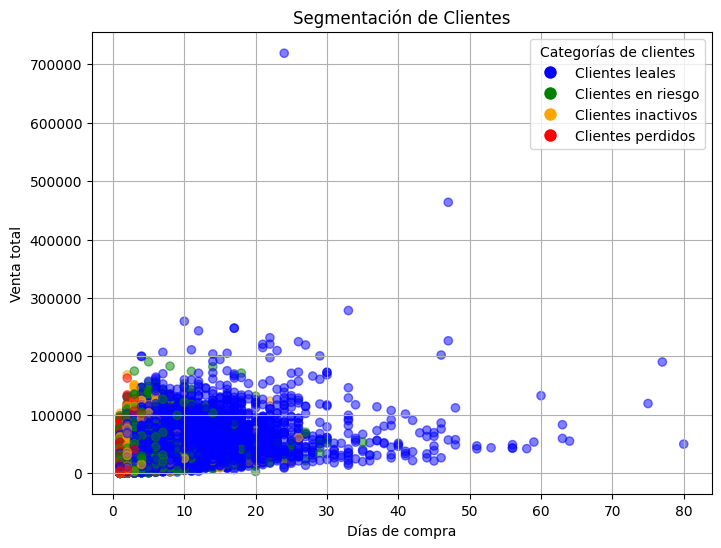

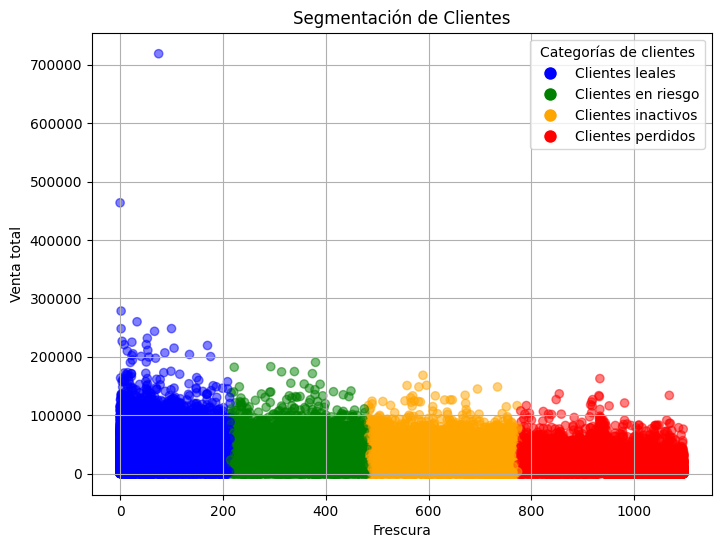

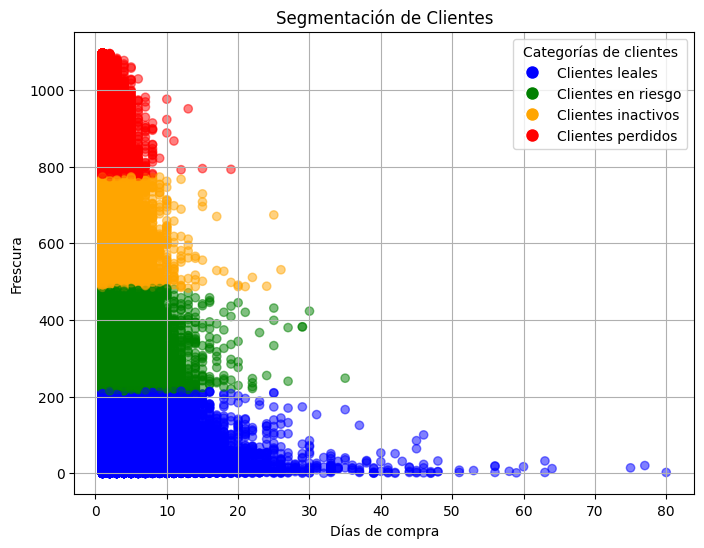

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D

output_file = r".\Dataframes EB\Clientes_Clusterizados.csv"
# Leer el archivo CSV
df = pd.read_csv(output_file, encoding='utf-8-sig')
#df = df[(df["Suma de Vta Total"] <= 5) & (df["Recuento de Fecha"] <= 5)]

# Configuración personalizada
# Crear un nuevo diccionario reordenado
nombres = [
    'Clientes leales',
    'Clientes en riesgo',
    'Clientes inactivos',
    'Clientes perdidos'
]

colores = ['blue', 'green','orange' ,'red']

cluster_config = {
    old_label: {'nombre': nombre, 'color': color}
    for old_label, nombre, color in zip(orden_clusters, nombres, colores)
}

# Diccionario para renombrar ejes
axis_labels = {
    'Recuento de Fecha': 'Días de compra',
    'Suma de Vta Total': 'Venta total',
    'Frescura (días)': 'Frescura'
}

# Función para graficar clusters
def plot_clusters(df, x_col, y_col, cluster_col, title):
    plt.figure(figsize=(8, 6))
    
    # Mapear los valores de cluster a colores y nombres
    colors = df[cluster_col].map({k: v['color'] for k, v in cluster_config.items()})
    
    scatter = plt.scatter(df[x_col], df[y_col], c=colors, alpha=0.5)
    
    # Crear leyenda personalizada con los nuevos nombres
    legend_elements = [Line2D([0], [0], marker='o', color='w', 
                      label=cluster_config[i]['nombre'], 
                      markerfacecolor=cluster_config[i]['color'], 
                      markersize=10) 
                      for i in cluster_config.keys()]
    
    plt.legend(handles=legend_elements, title='Categorías de clientes')
    
    plt.xlabel(axis_labels.get(x_col, x_col))
    plt.ylabel(axis_labels.get(y_col, y_col))
    plt.title(title)
    plt.grid(True)
    plt.show()

# Graficar diferentes combinaciones
plot_clusters(df, 'Recuento de Fecha', 'Suma de Vta Total', 'Cluster_KMeans', 'Segmentación de Clientes')
plot_clusters(df, 'Frescura (días)', 'Suma de Vta Total', 'Cluster_KMeans', 'Segmentación de Clientes')
plot_clusters(df, 'Recuento de Fecha', 'Frescura (días)', 'Cluster_KMeans', 'Segmentación de Clientes')


### Guardar los resultados en el archivo de la Clusterización en Segmentos VFR.csv

In [25]:
import pandas as pd
import os

# Ruta base del archivo
ruta_clusters = r".\Dataframes EB\Clientes_Clusterizados.csv"
ruta_quintiles = r".\Dataframes EB\Segmentos VFR.csv"
ruta_salida = r".\Dataframes EB"


df_clusters = pd.read_csv(ruta_clusters, encoding='utf-8-sig')
df_quintiles = pd.read_csv(ruta_quintiles, encoding='utf-8-sig')

# Eliminar 'Cluster_KMeans' si existe en df_quintiles para evitar duplicados
if 'Cluster_KMeans' in df_quintiles.columns:
    df_quintiles = df_quintiles.drop(columns=['Cluster_KMeans'])

# Unir los dataframes
df_final = df_quintiles.merge(df_clusters[['CUENTA', 'Cluster_KMeans']], on='CUENTA', how='left')

# Crear cluster_summary para definir orden de etiquetas
cluster_summary = df_clusters.groupby('Cluster_KMeans')[['Suma de Vta Total', 'Recuento de Fecha', 'Frescura (días)']].mean()
cluster_summary['Score'] = (
    cluster_summary['Suma de Vta Total'] +
    cluster_summary['Recuento de Fecha'] -
    cluster_summary['Frescura (días)'] 
)
orden_clusters = cluster_summary.sort_values('Score', ascending=False).index.tolist()

# Asignar nombres según el orden
nombres = [
    'Clientes leales',
    'Clientes en riesgo',
    'Clientes inactivos',
    'Clientes perdidos'
]

cluster_label_map = {cluster: nombre for cluster, nombre in zip(orden_clusters, nombres)}

# Asignar etiquetas al dataframe final
df_final['Tipo_Cliente'] = df_final['Cluster_KMeans'].map(cluster_label_map)
df_final['Tipo_Cliente'] = df_final['Tipo_Cliente'].fillna('Dato no disponible')
df_final = df_final.drop_duplicates()
# Guardar el archivo resultante
output_file = os.path.join(ruta_salida, "Segmentos VFR.csv")
df_final.to_csv(output_file, index=False, encoding='utf-8-sig')  # Cambiado ruta_salida por output_file

print(f"Archivo guardado en: {output_file}")

Archivo guardado en: .\Dataframes EB\Segmentos VFR.csv


### Se realiza la SubClusterización para cada Cluster

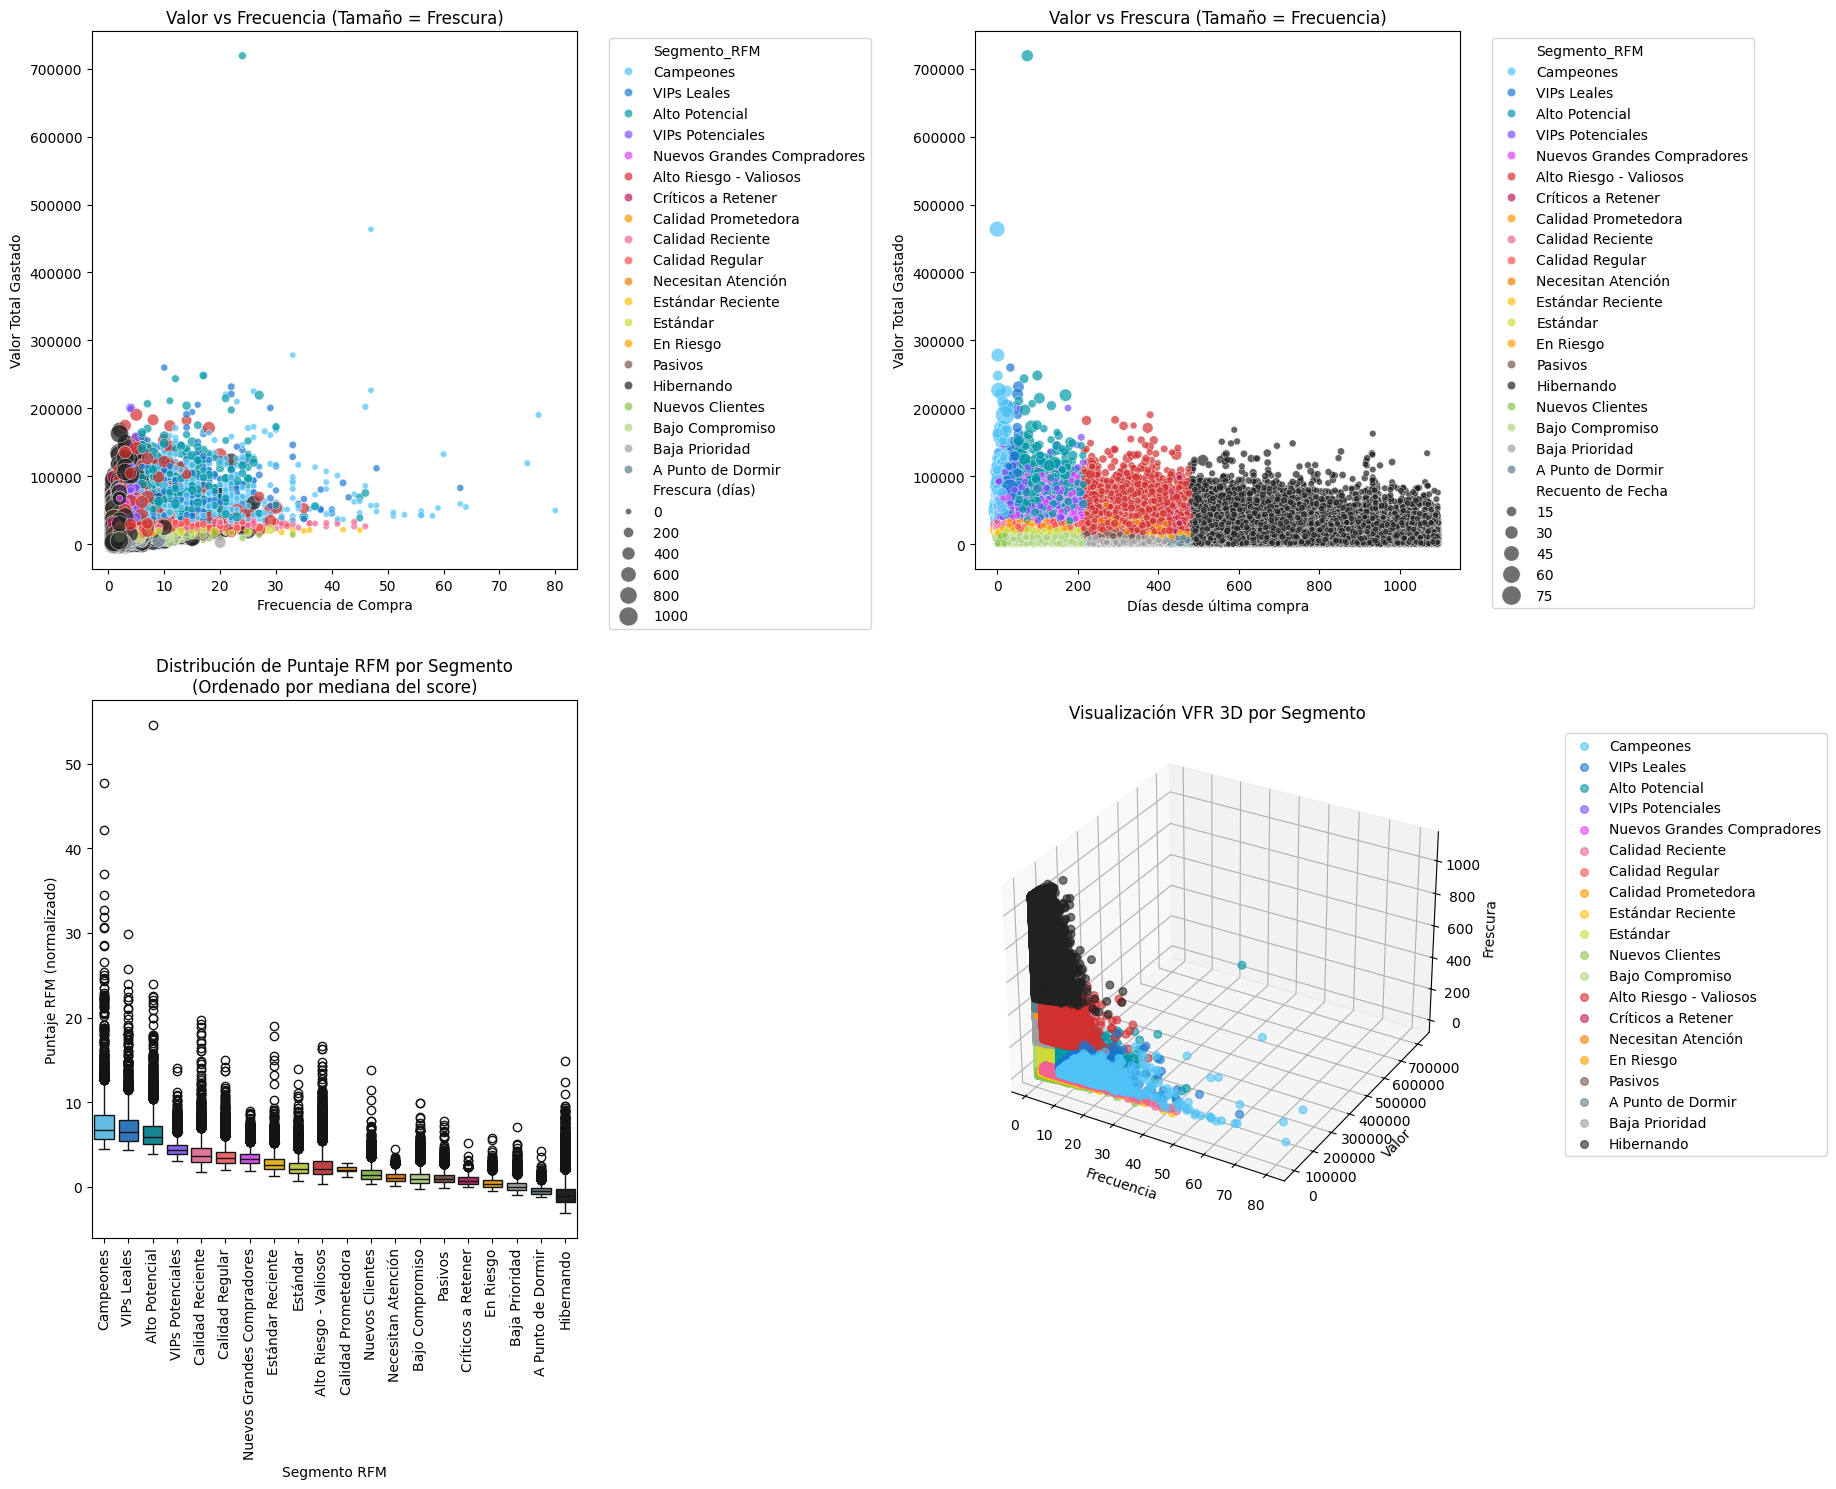

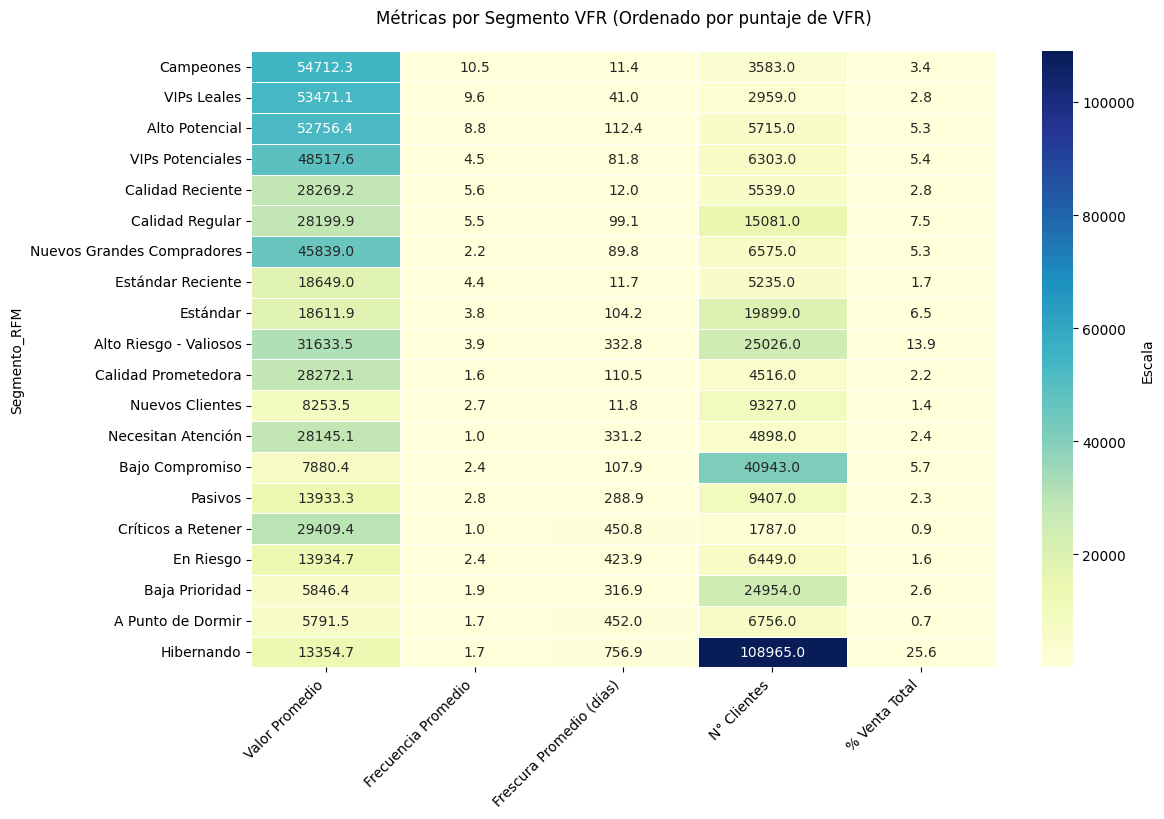

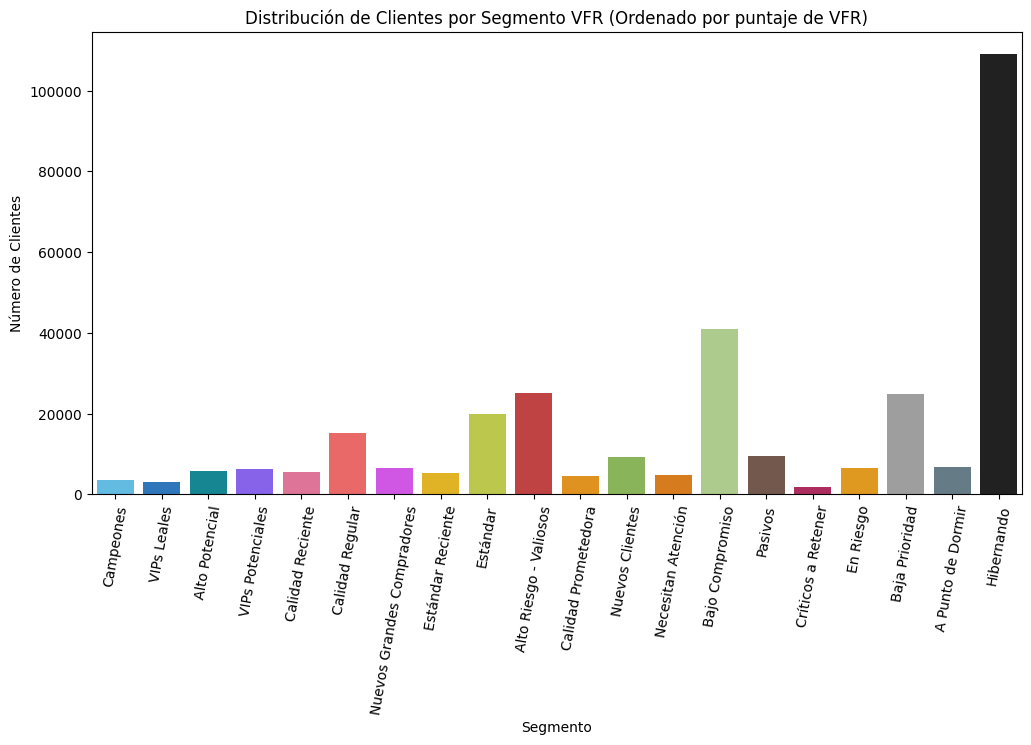

Archivo actualizado guardado en: .\Dataframes EB\Segmentos VFR.csv


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D
import os

ruta_quintiles = r".\Dataframes EB\Segmentos VFR.csv"
df_final = pd.read_csv(ruta_quintiles, encoding='utf-8-sig')
# 1. Filtrar todos los clusters de interés (incluyendo inactivos y perdidos)
df_todos = df_final[df_final['Tipo_Cliente'].isin(['Clientes leales', 'Clientes en riesgo', 'Clientes inactivos', 'Clientes perdidos'])].copy()
df_todos['Frescura (días)'] = pd.to_numeric(df_todos['Frescura (días)'], errors='coerce')

# 2. Calcular quintiles para segmentación - SEPARADO POR TIPO DE CLIENTE
variables = ['Suma de Vta Total', 'Recuento de Fecha', 'Frescura (días)']
percentiles = [20, 40, 60, 80]  # Quintiles para mayor granularidad

# Calcular percentiles para cada variable y cada tipo de cliente
vfr_percentiles = {
    'Clientes leales': {},
    'Clientes en riesgo': {},
    'Clientes inactivos': {},
    'Clientes perdidos': {}
}

for tipo in ['Clientes leales', 'Clientes en riesgo', 'Clientes inactivos', 'Clientes perdidos']:
    df_tipo = df_todos[df_todos['Tipo_Cliente'] == tipo]
    for var in variables:
        vfr_percentiles[tipo][var] = np.percentile(df_tipo[var].dropna(), percentiles)

# 3. Normalización de variables para igual peso
scaler = StandardScaler()
rfm_normalized = df_todos[['Suma de Vta Total', 'Recuento de Fecha', 'Frescura (días)']]
rfm_normalized = pd.DataFrame(scaler.fit_transform(rfm_normalized), 
                            columns=['Valor_norm', 'Frecuencia_norm', 'Frescura_norm'],
                            index=rfm_normalized.index)

df_todos = pd.concat([df_todos, rfm_normalized], axis=1)

# 4. Asignar segmentos RFM mejorados con quintiles
def asignar_segmento_mejorado(row):
    valor = row['Suma de Vta Total']
    frecuencia = row['Recuento de Fecha']
    frescura = row['Frescura (días)']
    tipo = row['Tipo_Cliente']
    percentiles_tipo = vfr_percentiles[tipo]
    
    # Segmentación para Clientes Leales (más granular)
    if tipo == 'Clientes leales':
        # Top 20% valor
        if valor >= percentiles_tipo['Suma de Vta Total'][3]:
            if frecuencia >= percentiles_tipo['Recuento de Fecha'][3]:  # Top 20% frecuencia
                if frescura <= percentiles_tipo['Frescura (días)'][0]:  # Bottom 20% frescura
                    return 'Campeones'
                elif frescura <= percentiles_tipo['Frescura (días)'][1]:  # 20-40%
                    return 'VIPs Leales'
                else:
                    return 'Alto Potencial'
            elif frecuencia >= percentiles_tipo['Recuento de Fecha'][2]:  # 60-80%
                return 'VIPs Potenciales'
            else:
                return 'Nuevos Grandes Compradores'
        # 60-80% valor
        elif valor >= percentiles_tipo['Suma de Vta Total'][2]:
            if frescura <= percentiles_tipo['Frescura (días)'][0]:
                return 'Calidad Reciente'
            elif frecuencia >= percentiles_tipo['Recuento de Fecha'][1]:  # 40-60%
                return 'Calidad Regular'
            else:
                return 'Calidad Prometedora'
        # 40-60% valor
        elif valor >= percentiles_tipo['Suma de Vta Total'][1]:
            if frescura <= percentiles_tipo['Frescura (días)'][0]:
                return 'Estándar Reciente'
            else:
                return 'Estándar'
        # Bottom 40% valor
        else:
            if frescura <= percentiles_tipo['Frescura (días)'][0]:
                return 'Nuevos Clientes'
            else:
                return 'Bajo Compromiso'
    
    # Segmentación mejorada para Clientes en Riesgo
    elif tipo == 'Clientes en riesgo':
        # Top 40% valor
        if valor >= percentiles_tipo['Suma de Vta Total'][2]:
            if frecuencia >= percentiles_tipo['Recuento de Fecha'][2]:  # Top 40% frecuencia
                return 'Alto Riesgo - Valiosos'
            elif frescura >= percentiles_tipo['Frescura (días)'][3]:  # Top 20% antigüedad
                return 'Críticos a Retener'
            else:
                return 'Necesitan Atención'
        # 40-60% valor
        elif valor >= percentiles_tipo['Suma de Vta Total'][1]:
            if frescura >= percentiles_tipo['Frescura (días)'][2]:  # 60-80%
                return 'En Riesgo'
            else:
                return 'Pasivos'
        # Bottom 40% valor
        else:
            if frescura >= percentiles_tipo['Frescura (días)'][3]:  # Top 20%
                return 'A Punto de Dormir'
            else:
                return 'Baja Prioridad'
    
    # Segmentación para Clientes Inactivos y Perdidos
    else:
        return 'Hibernando'

df_todos['Segmento_RFM'] = df_todos.apply(asignar_segmento_mejorado, axis=1)
df_todos['RFM_Score'] = (df_todos['Valor_norm'] + 
                        df_todos['Frecuencia_norm'] + 
                        (1 - df_todos['Frescura_norm']))

# 5. Gráficos mejorados
plt.figure(figsize=(18, 15))

# Paleta de colores mejorada
palette = {
    # Segmentos leales
    'Campeones': '#4FC3F7', 'VIPs Leales': '#1976D2', 'Alto Potencial': '#0097A7',
    'VIPs Potenciales': '#7C4DFF', 'Nuevos Grandes Compradores': '#E040FB', 'Calidad Reciente': '#F06292',
    'Calidad Regular': '#FF5252', 'Calidad Prometedora': '#FF9800', 'Estándar Reciente': '#FFC107',
    'Estándar': '#CDDC39', 'Nuevos Clientes': '#8BC34A', 'Bajo Compromiso': '#AED581',
    
    # Segmentos en riesgo
    'Alto Riesgo - Valiosos': '#D32F2F', 'Críticos a Retener': '#C2185B', 'Necesitan Atención': '#F57C00',
    'En Riesgo': '#FFA000', 'Pasivos': '#795548', 'A Punto de Dormir': '#607D8B', 'Baja Prioridad': '#9E9E9E',
    
    # Segmentos inactivos y perdidos
    'Hibernando': '#212121' 
}
segment_means = df_todos.groupby('Segmento_RFM')[['Suma de Vta Total', 'Recuento de Fecha', 'Frescura (días)']].mean()
segment_order = segment_means.sort_values('Suma de Vta Total', ascending=False).index.tolist()
segment_means = segment_means.loc[segment_order]

# Gráfico 1: Valor vs Frecuencia con tamaño por frescura
plt.subplot(2, 2, 1)
scatter = sns.scatterplot(data=df_todos, 
                        x='Recuento de Fecha', 
                        y='Suma de Vta Total', 
                        hue='Segmento_RFM',
                        size='Frescura (días)',
                        sizes=(20, 200),
                        palette=palette,
                        alpha=0.7,
                        hue_order=segment_order)
plt.title('Valor vs Frecuencia (Tamaño = Frescura)')
plt.xlabel('Frecuencia de Compra')
plt.ylabel('Valor Total Gastado')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


# Gráfico 2: Valor vs Frescura con tamaño por frecuencia
plt.subplot(2, 2, 2)
ax = sns.scatterplot(data=df_todos, 
                x='Frescura (días)', 
                y='Suma de Vta Total', 
                hue='Segmento_RFM',
                size='Recuento de Fecha',
                sizes=(20, 200),
                palette=palette,
                alpha=0.7,
                hue_order=segment_order)
plt.title('Valor vs Frescura (Tamaño = Frecuencia)')
plt.xlabel('Días desde última compra')
plt.ylabel('Valor Total Gastado')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Gráfico 3: Boxplots por segmento ordenado por mediana del RFM_Score
plt.subplot(2, 2, 3)
order = df_todos.groupby('Segmento_RFM')['RFM_Score'].median().sort_values(ascending=False).index
sns.boxplot(data=df_todos, 
            x='Segmento_RFM', 
            y='RFM_Score',
            palette=palette,
            order=order,
            hue_order=segment_order)
plt.xticks(rotation=90)
plt.title('Distribución de Puntaje RFM por Segmento\n(Ordenado por mediana del score)')
plt.xlabel('Segmento RFM')
plt.ylabel('Puntaje RFM (normalizado)')

# Gráfico 4: Visualización 3D mejorada
ax = plt.subplot(2, 2, 4, projection='3d')
for segment, color in palette.items():
    if segment in df_todos['Segmento_RFM'].unique():
        segment_data = df_todos[df_todos['Segmento_RFM'] == segment]
        ax.scatter(segment_data['Recuento de Fecha'],
                   segment_data['Suma de Vta Total'],
                   segment_data['Frescura (días)'],
                   c=color, label=segment, alpha=0.6, s=30)
    
ax.set_xlabel('Frecuencia')
ax.set_ylabel('Valor')
ax.set_zlabel('Frescura')
ax.set_title('Visualización VFR 3D por Segmento')
plt.legend(bbox_to_anchor=(1.2, 1), loc='upper left')

plt.tight_layout()
plt.show()

# 6. Análisis adicional: Heatmap de correlaciones
# Calcular estadísticas por segmento
segment_stats = df_todos.groupby('Segmento_RFM').agg({
    'RFM_Score': 'median',
    'Suma de Vta Total': ['mean', 'sum', 'count'],
    'Recuento de Fecha': 'mean',
    'Frescura (días)': 'mean'
})

# Aplanar el MultiIndex y renombrar columnas
segment_stats.columns = ['RFM_Mediana', 'Venta_Promedio', 'Venta_Total', 'Num_Clientes', 'Frecuencia_Promedio', 'Frescura_Promedio']

# Calcular % de venta total
segment_stats['%_Venta'] = (segment_stats['Venta_Total'] / segment_stats['Venta_Total'].sum()) * 100

# Ordenar por RFM_Mediana (de mayor a menor)
segment_stats = segment_stats.sort_values('RFM_Mediana', ascending=False)

# Seleccionar columnas para el heatmap (ahora con las 2 nuevas)
heatmap_data = segment_stats[['Venta_Promedio', 'Frecuencia_Promedio', 'Frescura_Promedio', 'Num_Clientes', '%_Venta']]
heatmap_data.rename(columns={
    'Venta_Promedio': 'Valor Promedio',
    'Frecuencia_Promedio': 'Frecuencia Promedio',
    'Frescura_Promedio': 'Frescura Promedio (días)',
    'Num_Clientes': 'N° Clientes',
    '%_Venta': '% Venta Total'
}, inplace=True)

# Heatmap mejorado
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, 
            annot=True, 
            fmt=".1f", 
            cmap="YlGnBu",
            cbar_kws={'label': 'Escala'},
            linewidths=0.5)
plt.title('Métricas por Segmento VFR (Ordenado por puntaje de VFR)', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()
# 7. Distribución de clientes por segmento (ORDENADO POR RFM)
plt.figure(figsize=(12, 6))

# Calcular el orden basado en la mediana del RFM_Score (de mayor a menor)
segment_order_rfm = df_todos.groupby('Segmento_RFM')['RFM_Score'].median().sort_values(ascending=False).index

# Contar clientes por segmento y reordenar según RFM
segment_counts = df_todos['Segmento_RFM'].value_counts()[segment_order_rfm]

# Crear el gráfico de barras ordenado
sns.barplot(x=segment_counts.index, 
            y=segment_counts.values, 
            palette=palette,
            order=segment_order_rfm)
plt.title('Distribución de Clientes por Segmento VFR (Ordenado por puntaje de VFR)')
plt.xlabel('Segmento')
plt.ylabel('Número de Clientes')
plt.xticks(rotation=80)
plt.show()

# 1. Leer el archivo existente con los quintiles
ruta_quintiles = r".\Dataframes EB\Segmentos VFR.csv"
df_quintiles = pd.read_csv(ruta_quintiles)

# 2. Crear un DataFrame solo con las columnas necesarias para el merge
df_segmentos = df_todos[['CUENTA', 'Segmento_RFM']].drop_duplicates().copy()

# Diccionario de mapeo de segmentos a calificación numérica (1 = mejor, 20 = peor)
segmento_a_calificacion = {
    # Segmentos leales (1-12)
    'Campeones': 1,
    'VIPs Leales': 2,
    'Alto Potencial': 3,
    'VIPs Potenciales': 4,
    'Calidad Reciente': 5,
    'Nuevos Grandes Compradores': 6,
    'Calidad Regular': 7,
    'Estándar Reciente': 8,
    'Estándar': 9,
    'Calidad Prometedora': 10,
    'Alto Riesgo - Valiosos': 11,
    'Nuevos Clientes': 12,
    'Bajo Compromiso': 13,
    
    # Segmentos en riesgo (13-19)
    'Pasivos': 14,
    'Críticos a Retener': 15,
    'Necesitan Atención': 16,
    'En Riesgo': 17,
  
    'Baja Prioridad': 18,
    'A Punto de Dormir': 19,

    
    # Segmentos inactivos/perdidos (20)
    'Hibernando': 20
}
# Asignar la calificación numérica
df_segmentos['Calificacion_Segmento'] = df_segmentos['Segmento_RFM'].map(segmento_a_calificacion)
df_segmentos['Segmento_RFM'] = df_segmentos['Segmento_RFM'].fillna('Dato no disponible')

# Eliminar las columnas 'Segmento_RFM' y 'Calificacion_Segmento' de df_quintiles si existen para evitar conflictos de sufijos
cols_to_drop = []
if 'Segmento_RFM' in df_quintiles.columns:
    cols_to_drop.append('Segmento_RFM')
if 'Calificacion_Segmento' in df_quintiles.columns:
    cols_to_drop.append('Calificacion_Segmento')
if cols_to_drop:
    df_quintiles = df_quintiles.drop(columns=cols_to_drop)

# 3. Hacer el merge con el DataFrame original de quintiles
# Usamos left join para mantener todos los registros del archivo original
df_final_quintiles = df_quintiles.merge(
    df_segmentos,
    on='CUENTA',
    how='left'
)

# 4. Guardar el archivo actualizado (puedes guardarlo con otro nombre o sobrescribir)
ruta_actualizada = r".\Dataframes EB\Segmentos VFR.csv"
df_final_quintiles.to_csv(ruta_actualizada, index=False, encoding='utf-8-sig')

print(f"Archivo actualizado guardado en: {ruta_actualizada}")

### Quintiles para cada Cluster de Tipo de Cliente

In [27]:
import pandas as pd

# Cargar el archivo CSV
df = pd.read_csv(r".\Dataframes EB\Segmentos VFR.csv", encoding='utf-8-sig')

# Convertir la columna de fecha y calcular frescura
df['Última fecha: Fecha'] = pd.to_datetime(df['Última fecha: Fecha'], errors='coerce', format='%Y-%m-%d')
fecha_actual = df['Última fecha: Fecha'].max()  # Fecha específica de referencia
df['Frescura (días)'] = (fecha_actual - df['Última fecha: Fecha']).dt.days

# Configuración de nombres para cada cluster
# Agrupar y calcular métricas promedio por cluster
cluster_summary = df.groupby('Cluster_KMeans')[['Suma de Vta Total', 'Recuento de Fecha', 'Frescura (días)']].mean()
cluster_summary['Score'] = (
    cluster_summary['Suma de Vta Total'] +
    cluster_summary['Recuento de Fecha'] -
    cluster_summary['Frescura (días)'] 
)
orden_clusters = cluster_summary.sort_values('Score', ascending=False).index.tolist()

# Asignar nombres dinámicos según el orden del Score
etiquetas = [
    'Clientes leales',
    'Clientes en riesgo',
    'Clientes inactivos',
    'Clientes perdidos'
]
cluster_config = {cluster: {'nombre': nombre} for cluster, nombre in zip(orden_clusters, etiquetas)}
# Función para calcular los quintiles
def calcular_quintiles(df, columna, nombre):
    df = df[df[columna].notna()]
    
    if df.empty:
        return pd.DataFrame(columns=['Intervalo', 'Mínimo', 'Máximo', 'Cuentas', 'Porcentaje'])
    
    quintiles = df[columna].quantile([0, 0.2, 0.4, 0.6, 0.8, 1.0]).drop_duplicates().tolist()
    
    if len(quintiles) < 2:
        return pd.DataFrame(columns=['Intervalo', 'Mínimo', 'Máximo', 'Cuentas', 'Porcentaje'])
    
    intervalos = [f"{int(quintiles[i])} - {int(quintiles[i+1])}" for i in range(len(quintiles)-1)]
    conteos = pd.cut(df[columna], bins=quintiles, include_lowest=True, labels=range(len(intervalos))).value_counts().sort_index()
    porcentaje = (conteos / conteos.sum() * 100).round(2)
    
    df_resultado = pd.DataFrame({
        'Intervalo': intervalos,
        'Mínimo': [int(quintiles[i]) for i in range(len(quintiles)-1)],
        'Máximo': [int(quintiles[i+1]) for i in range(len(quintiles)-1)],
        'Cuentas': conteos.values,
        'Porcentaje': porcentaje.values
    })
    
    return df_resultado.iloc[::-1]  # Mostrar del quintil superior al inferior

# Calcular y mostrar los quintiles por cluster con nombres
clusters = df['Cluster_KMeans'].dropna().unique()

for cluster in sorted(clusters):
    nombre_cluster = cluster_config.get(cluster, {}).get('nombre', 'Desconocido')
    
    print(f"\n{nombre_cluster} - Rangos del Valor de Compra")
    print(calcular_quintiles(df[df['Cluster_KMeans'] == cluster], 'Suma de Vta Total', 'Valor de Compra'))
    
    print(f"\n{nombre_cluster} - Rangos de la Frecuencia de Visita")
    print(calcular_quintiles(df[df['Cluster_KMeans'] == cluster], 'Recuento de Fecha', 'Frecuencia de Visita'))
    
    print(f"\n{nombre_cluster} - Rangos de la Frescura")
    print(calcular_quintiles(df[df['Cluster_KMeans'] == cluster], 'Frescura (días)', 'Frescura'))




Clientes en riesgo - Rangos del Valor de Compra


        Intervalo  Mínimo  Máximo  Cuentas  Porcentaje
4  27326 - 190667   27326  190667    15856        20.0
3   17322 - 27326   17322   27326    15855        20.0
2   11093 - 17322   11093   17322    15854        20.0
1    5764 - 11093    5764   11093    15856        20.0
0       20 - 5764      20    5764    15856        20.0

Clientes en riesgo - Rangos de la Frecuencia de Visita


  Intervalo  Mínimo  Máximo  Cuentas  Porcentaje
2    4 - 35       4      35     9710       12.25
1     2 - 4       2       4    21553       27.19
0     1 - 2       1       2    48014       60.56

Clientes en riesgo - Rangos de la Frescura


   Intervalo  Mínimo  Máximo  Cuentas  Porcentaje
4  420 - 482     420     482    15642       19.73
3  372 - 420     372     420    15914       20.07
2  313 - 372     313     372    15951       20.12
1  258 - 313     258     313    15899       20.05
0  214 - 258     214     258    15871       20.02

Clientes perdidos - Rangos del Valor de Compra


        Intervalo  Mínimo  Máximo  Cuentas  Porcentaje
4  18964 - 162832   18964  162832     9672       19.99
3   10343 - 18964   10343   18964     9668       19.98
2    5994 - 10343    5994   10343     9689       20.03
1     2757 - 5994    2757    5994     9646       19.94
0        0 - 2757       0    2757     9707       20.06

Clientes perdidos - Rangos de la Frecuencia de Visita


...

  Intervalo  Mínimo  Máximo  Cuentas  Porcentaje
4    6 - 80       6      80    19711       15.68
3     4 - 6       4       6    20448       16.27
2     3 - 4       3       4    16431       13.07
1     2 - 3       2       3    21090       16.78
0     1 - 2       1       2    47995       38.19

Clientes leales - Rangos de la Frescura


   Intervalo  Mínimo  Máximo  Cuentas  Porcentaje
4  148 - 214     148     214    24902       19.81
3   96 - 148      96     148    24992       19.89
2    53 - 96      53      96    24531       19.52
1    23 - 53      23      53    25268       20.11
0     0 - 23       0      23    25982       20.67

Clientes inactivos - Rangos del Valor de Compra


        Intervalo  Mínimo  Máximo  Cuentas  Porcentaje
4  23589 - 168493   23589  168493    12117        20.0
3   14149 - 23589   14149   23589    12116        20.0
2    8780 - 14149    8780   14149    12117        20.0
1     4358 - 8780    4358    8780    12116        20.0
0       24 - 4358      24    4358    12117        20.0

Clientes inactivos - Rangos de la Frecuencia de Visita


  Intervalo  Mínimo  Máximo  Cuentas  Porcentaje
2    3 - 26       3      26     5955        9.83
1     2 - 3       2       3     8003       13.21
0     1 - 2       1       2    46625       76.96

Clientes inactivos - Rangos de la Frescura


   Intervalo  Mínimo  Máximo  Cuentas  Porcentaje
4  713 - 773     713     773    12082       19.94
3  647 - 713     647     713    12082       19.94
2  591 - 647     591     647    12178       20.10
1  535 - 591     535     591    11956       19.73
0  483 - 535     483     535    12285       20.28


### Comparación de Quintiles de 36 meses y 34 meses y se guarda en Analisis_Cambio_Clientes_36a34meses.csv

In [28]:
import pandas as pd

# Cargar datasets
df_34 = pd.read_csv(r".\Dataframes EB\Segmentos 34 meses.csv", parse_dates=["Última fecha: Fecha"])
df_36 = pd.read_csv(r".\Dataframes EB\Segmentos VFR.csv", parse_dates=["Última fecha: Fecha"])

# Renombrar columnas para diferenciarlas
df_34 = df_34.rename(columns={
    "Suma de Vta Total": "Venta_34",
    "Recuento de Fecha": "Frecuencia_34",
    "ETIQ1": "Venta_Q34",
    "ETIQ2": "Frecuencia_Q34",
    "ETIQ3": "Frescura_Q34",
    "CUENTA":"Cliente"
})

df_36 = df_36.rename(columns={
    "Suma de Vta Total": "Venta_36",
    "Recuento de Fecha": "Frecuencia_36",
    "ETIQ1": "Venta_Q36",
    "ETIQ2": "Frecuencia_Q36",
    "ETIQ3": "Frescura_Q36",
    "CUENTA":"Cliente"
})

# Merge de ambos períodos (clientes que aparecen en ambos)
df_merge = pd.merge(df_36[['Cliente', 'Venta_36', 'Frecuencia_36', 'Venta_Q36', 'Frecuencia_Q36', 'Frescura_Q36']],
                    df_34[['Cliente', 'Venta_34', 'Frecuencia_34', 'Venta_Q34', 'Frecuencia_Q34', 'Frescura_Q34']],
                    on='Cliente', how='inner')

# Variables de cambio
df_merge['Cambio_Venta'] = df_merge['Venta_34'] - df_merge['Venta_36']  # 34 es posterior a 36
df_merge['Cambio_Frecuencia'] = df_merge['Frecuencia_34'] - df_merge['Frecuencia_36']

# Indicadores de cambio de quintil (robustos: convertir etiquetas a números antes de comparar)
import re

def label_to_num(val):
    """Extrae el número de etiquetas como 'V3','F2','R1' y devuelve float o NaN."""
    if pd.isna(val):
        return np.nan
    s = str(val)
    m = re.search(r'(\d+)', s)
    if m:
        return float(m.group(1))
    return np.nan

# Crear columnas numéricas para comparaciones seguras
for col in ['Venta_Q34','Venta_Q36','Frecuencia_Q34','Frecuencia_Q36','Frescura_Q34','Frescura_Q36']:
    df_merge[col + '_num'] = df_merge[col].apply(label_to_num)

def changed(a, b):
    """Detecta cambio tratando NaN==NaN como 'sin cambio'."""
    if pd.isna(a) and pd.isna(b):
        return False
    if pd.isna(a) or pd.isna(b):
        return True
    return a != b

df_merge['Cambio_Quintil_Venta'] = df_merge.apply(lambda x: changed(x['Venta_Q34_num'], x['Venta_Q36_num']), axis=1)
df_merge['Cambio_Quintil_Frecuencia'] = df_merge.apply(lambda x: changed(x['Frecuencia_Q34_num'], x['Frecuencia_Q36_num']), axis=1)
df_merge['Cambio_Quintil_Frescura'] = df_merge.apply(lambda x: changed(x['Frescura_Q34_num'], x['Frescura_Q36_num']), axis=1)

def direction_num(old, new):
    """Dirección del cambio usando valores numéricos; devuelve 'Desconocido' si falta alguno."""
    if pd.isna(old) or pd.isna(new):
        return 'Desconocido'
    if new > old:
        return 'Subió'
    elif new < old:
        return 'Bajó'
    else:
        return 'Igual'

# Nota: la dirección es desde 36 -> 34, así que comparamos (old = *_36_num, new = *_34_num)
df_merge['Direccion_Cambio_Venta'] = df_merge.apply(lambda x: direction_num(x['Venta_Q36_num'], x['Venta_Q34_num']), axis=1)
df_merge['Direccion_Cambio_Frecuencia'] = df_merge.apply(lambda x: direction_num(x['Frecuencia_Q36_num'], x['Frecuencia_Q34_num']), axis=1)
df_merge['Direccion_Cambio_Frescura'] = df_merge.apply(lambda x: direction_num(x['Frescura_Q36_num'], x['Frescura_Q34_num']), axis=1)

# (Opcional) eliminar columnas numéricas temporales si no se desean en el resultado:
# df_merge.drop(columns=[c for c in df_merge.columns if c.endswith('_num')], inplace=True)

# Ver resultados principales
print(df_merge[['Cliente', 'Venta_36', 'Venta_34', 'Cambio_Venta',
                'Venta_Q36', 'Venta_Q34', 'Direccion_Cambio_Venta']].head())

# Guardar resultados
df_merge.to_csv(r".\Dataframes EB\Analisis_Cambio_Clientes_36a34meses.csv", index=False, encoding='utf-8-sig')


   Cliente  Venta_36  Venta_34  Cambio_Venta Venta_Q36 Venta_Q34  \
0   894948      0.00      0.00          0.00        V0        V0   
1   724989  42260.77  42260.77          0.00        V4        V4   
2   875755      0.00      0.00          0.00        V0        V0   
3   303683  28085.35  28085.35          0.00        V3        V3   
4   832697  24789.53  11177.06     -13612.47        V3        V2   

  Direccion_Cambio_Venta  
0                  Igual  
1                  Igual  
2                  Igual  
3                  Igual  
4                   Bajó  


### Se agregan las etiquetas de transición al archivo original Segmentos VFR.csv

In [29]:
import pandas as pd

# === Cargar los datos ya procesados ===
df_merge = pd.read_csv(r".\Dataframes EB\Analisis_Cambio_Clientes_36a34meses.csv", encoding='utf-8-sig')



# Crear columna de transición tipo "V3->V4"
df_merge['TransicionV (36->34)'] = df_merge['Venta_Q36'].astype(str) + ' -> ' + df_merge['Venta_Q34'].astype(str)
df_merge['TransicionF (36->34)'] = df_merge['Frecuencia_Q36'].astype(str) + ' -> ' + df_merge['Frecuencia_Q34'].astype(str)
df_merge['TransicionR (36->34)'] = df_merge['Frescura_Q36'].astype(str) + ' -> ' + df_merge['Frescura_Q34'].astype(str)

# === Cargar el archivo base de 36 meses ===
df_36 = pd.read_csv(r".\Dataframes EB\Segmentos VFR.csv", encoding='utf-8-sig')

if 'TransicionV (36->34)' in df_36.columns:
    df_36 = df_36.drop(columns=['TransicionV (36->34)'])
if 'TransicionF (36->34)' in df_36.columns:
    df_36 = df_36.drop(columns=['TransicionF (36->34)'])
if 'TransicionR (36->34)' in df_36.columns:
    df_36 = df_36.drop(columns=['TransicionR (36->34)'])


# Renombrar columna CUENTA si no está así
if 'CUENTA' not in df_36.columns:
    df_36 = df_36.rename(columns={'Cliente': 'CUENTA'})

# Unir la columna de transición con base en CUENTA
df_36 = pd.merge(df_36, df_merge[['Cliente', 'TransicionV (36->34)','TransicionF (36->34)','TransicionR (36->34)']], left_on='CUENTA', right_on='Cliente', how='left')
df_36.drop(columns='Cliente', inplace=True)

# === Guardar el nuevo archivo con la columna Transición ===
output_path = r".\Dataframes EB\Segmentos VFR.csv"
df_36.drop_duplicates(inplace=True)  # Eliminar duplicados si los hubiera

df_36.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"✅ Columna 'Transicion' añadida y archivo guardado en:\n{output_path}")


✅ Columna 'Transicion' añadida y archivo guardado en:
.\Dataframes EB\Segmentos VFR.csv


## Matrices de Transición

### Valor

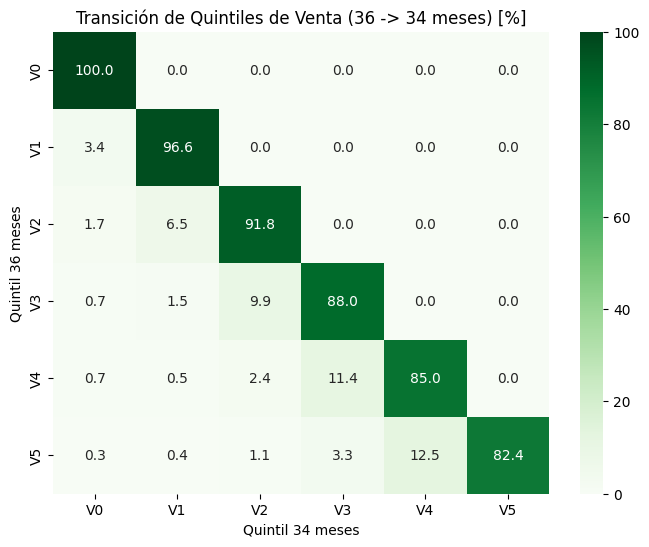

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crear tabla de transición en valores absolutos
transicion = df_merge.groupby(['Venta_Q36', 'Venta_Q34']).size().unstack(fill_value=0)

# Normalizar por fila (porcentaje de transición desde cada quintil original)
transicion_pct = transicion.div(transicion.sum(axis=1), axis=0) * 100  # convierte a porcentaje

# Graficar heatmap en porcentaje
plt.figure(figsize=(8,6))
sns.heatmap(transicion_pct, annot=True, fmt='.1f', cmap="Greens")

plt.title('Transición de Quintiles de Venta (36 -> 34 meses) [%]')
plt.xlabel('Quintil 34 meses')
plt.ylabel('Quintil 36 meses')
plt.show()



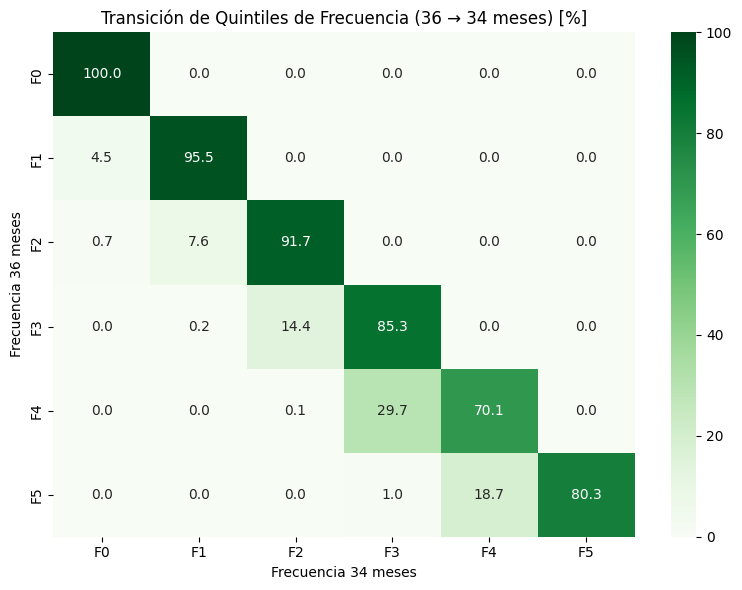

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Matriz de transición en valores absolutos
frecuencia_transicion = pd.crosstab(df_merge['Frecuencia_Q36'], df_merge['Frecuencia_Q34'])

# Normalizar por fila (porcentajes)
frecuencia_transicion_pct = frecuencia_transicion.div(frecuencia_transicion.sum(axis=1), axis=0) * 100

# Graficar heatmap en porcentaje
plt.figure(figsize=(8, 6))
sns.heatmap(frecuencia_transicion_pct, annot=True, fmt='.1f', cmap="Greens")

plt.title("Transición de Quintiles de Frecuencia (36 → 34 meses) [%]")
plt.xlabel("Frecuencia 34 meses")
plt.ylabel("Frecuencia 36 meses")
plt.tight_layout()
plt.show()



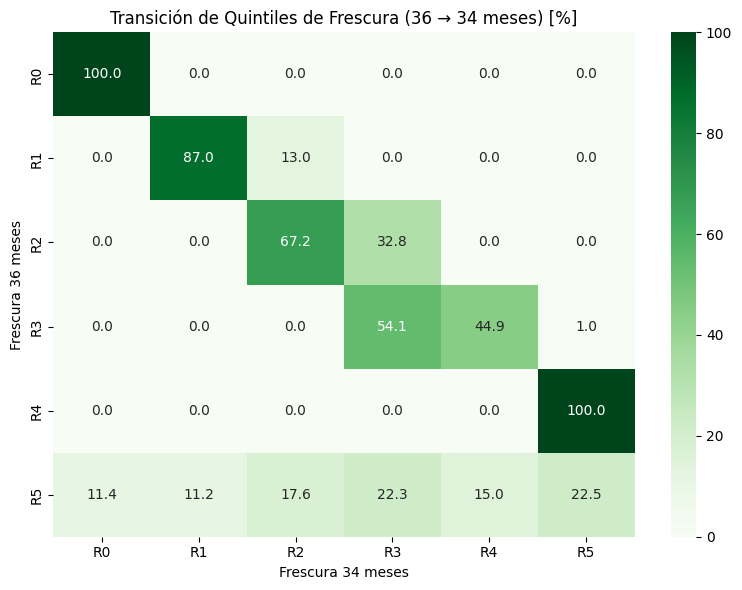

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# Matriz de transición en valores absolutos
frescura_transicion = pd.crosstab(df_merge['Frescura_Q36'], df_merge['Frescura_Q34'])

# Normalizar por fila (porcentajes)
frescura_transicion_pct = frescura_transicion.div(frescura_transicion.sum(axis=1), axis=0) * 100

# Heatmap con porcentajes
plt.figure(figsize=(8, 6))
sns.heatmap(frescura_transicion_pct, annot=True, fmt='.1f', cmap="Greens")

plt.title("Transición de Quintiles de Frescura (36 → 34 meses) [%]")
plt.xlabel("Frescura 34 meses")
plt.ylabel("Frescura 36 meses")
plt.tight_layout()
plt.show()



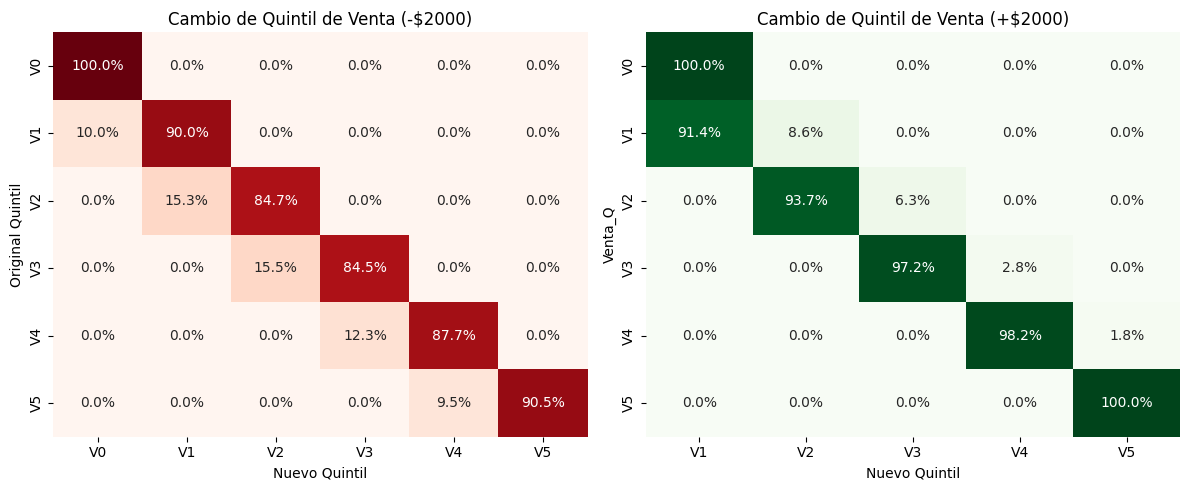

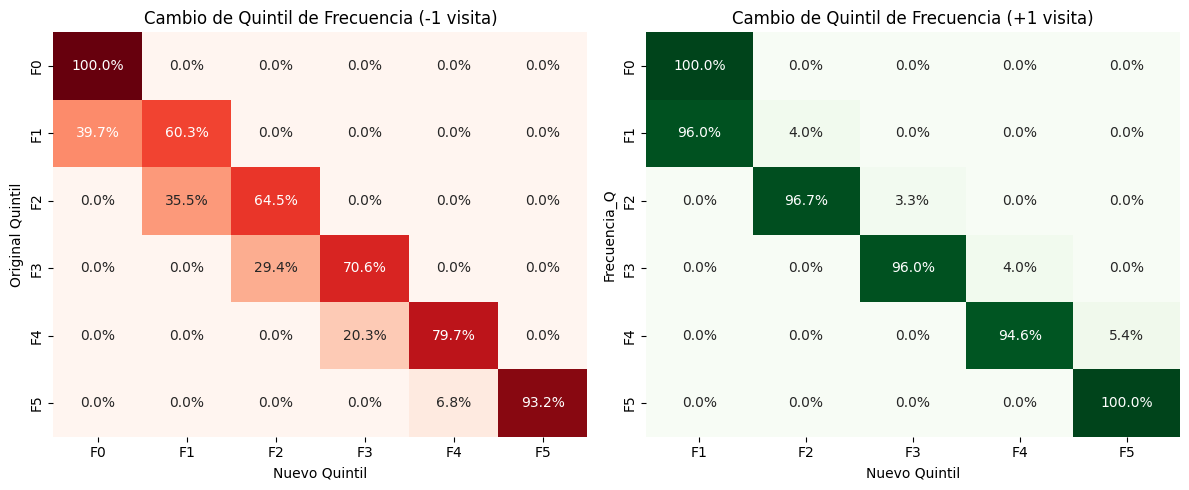

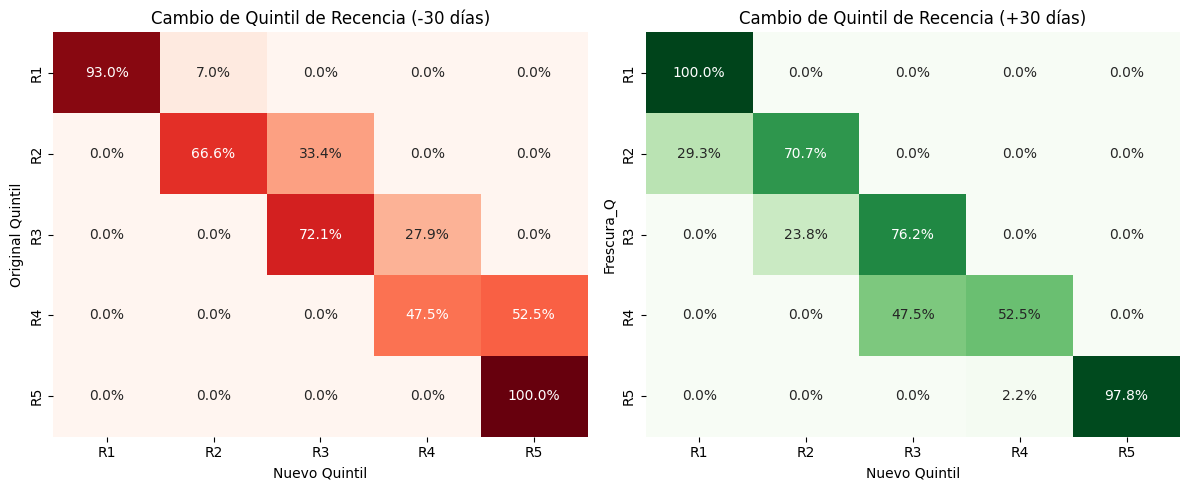

✅ Archivo actualizado con columnas de simulación (formato transición): .\Dataframes EB\Segmentos VFR.csv
Columnas añadidas: ['Venta_+2000', 'Venta_-2000', 'Frecuencia_+1', 'Frecuencia_-1', 'Frescura_+30d', 'Frescura_-30d']


In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

# ---------------------------
# FUNCIONES DE CLASIFICACIÓN
# ---------------------------

def clasificar_venta(monto):
    if monto >= 96001:
        return 'V5'
    elif monto >= 61001:
        return 'V4'
    elif monto >= 36001:
        return 'V3'
    elif monto >= 17001:
        return 'V2'
    elif monto >= 1:
        return 'V1'
    else:
        return 'V0'

def clasificar_frecuencia(freq):
    if freq >= 34:
        return 'F5'
    elif freq >= 22:
        return 'F4'
    elif freq >= 14:
        return 'F3'
    elif freq >= 7:
        return 'F2'
    elif freq >= 1:
        return 'F1'
    else:
        return 'F0'

def clasificar_frescura(dias):
    if dias >= 366:
        return 'R1'
    elif dias >= 271:
        return 'R2'
    elif dias >= 151:
        return 'R3'
    elif dias >= 91:
        return 'R4'
    elif dias >= 0:
        return 'R5'
    else:
        return 'R0'

# --- Cargar el archivo base ---
input_path = r".\Dataframes EB\Segmentos VFR.csv"
df = pd.read_csv(input_path, encoding='utf-8-sig')

# Convert relevant columns to numeric, coercing errors to NaN
df['Suma de Vta Total'] = pd.to_numeric(df['Suma de Vta Total'], errors='coerce')
df['Recuento de Fecha'] = pd.to_numeric(df['Recuento de Fecha'], errors='coerce')

# Fecha de corte para cálculos
fecha_corte = pd.to_datetime(df['Última fecha: Fecha'], errors='coerce').max()

# ---------------------------
# PREPARACIÓN DE DATOS
# ---------------------------

# Calcular frescura en días (desde última compra hasta fecha corte)
df['Última fecha: Fecha'] = pd.to_datetime(df['Última fecha: Fecha'], errors='coerce')
df['Frescura_dias'] = (fecha_corte - df['Última fecha: Fecha']).dt.days
df['Frescura_dias'] = df['Frescura_dias'].fillna(0).astype(int)

# Clasificaciones originales
df['Venta_Q'] = df['Suma de Vta Total'].apply(clasificar_venta)
df['Frecuencia_Q'] = df['Recuento de Fecha'].apply(clasificar_frecuencia)
df['Frescura_Q'] = df['Frescura_dias'].apply(clasificar_frescura)

# ---------------------------------------------
# SIMULACIÓN PARA VENTA: +/- 2000 pesos
# ---------------------------------------------
df['Venta_menos'] = df['Suma de Vta Total'] - 2000
df['Venta_mas'] = df['Suma de Vta Total'] + 2000

df['Venta_Q_menos'] = df['Venta_menos'].apply(clasificar_venta)
df['Venta_Q_mas'] = df['Venta_mas'].apply(clasificar_venta)

# Heatmaps para venta
venta_menos = pd.crosstab(df['Venta_Q'], df['Venta_Q_menos'], normalize='index')
venta_mas = pd.crosstab(df['Venta_Q'], df['Venta_Q_mas'], normalize='index')

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(venta_menos, annot=True, cmap="Reds", fmt=".1%", cbar=False)
plt.title('Cambio de Quintil de Venta (-$2000)')
plt.xlabel('Nuevo Quintil')
plt.ylabel('Original Quintil')

plt.subplot(1, 2, 2)
sns.heatmap(venta_mas, annot=True, cmap="Greens", fmt=".1%", cbar=False)
plt.title('Cambio de Quintil de Venta (+$2000)')
plt.xlabel('Nuevo Quintil')
plt.tight_layout()
plt.show()

# ---------------------------------------------
# SIMULACIÓN PARA FRECUENCIA: +/- 1 visita
# ---------------------------------------------
df['Frecuencia_menos'] = df['Recuento de Fecha'] - 1
df['Frecuencia_mas'] = df['Recuento de Fecha'] + 1

df['Frecuencia_Q_menos'] = df['Frecuencia_menos'].apply(clasificar_frecuencia)
df['Frecuencia_Q_mas'] = df['Frecuencia_mas'].apply(clasificar_frecuencia)

# Heatmaps para frecuencia
freq_menos = pd.crosstab(df['Frecuencia_Q'], df['Frecuencia_Q_menos'], normalize='index')
freq_mas = pd.crosstab(df['Frecuencia_Q'], df['Frecuencia_Q_mas'], normalize='index')

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(freq_menos, annot=True, cmap="Reds", fmt=".1%", cbar=False)
plt.title('Cambio de Quintil de Frecuencia (-1 visita)')
plt.xlabel('Nuevo Quintil')
plt.ylabel('Original Quintil')

plt.subplot(1, 2, 2)
sns.heatmap(freq_mas, annot=True, cmap="Greens", fmt=".1%", cbar=False)
plt.title('Cambio de Quintil de Frecuencia (+1 visita)')
plt.xlabel('Nuevo Quintil')
plt.tight_layout()
plt.show()

# ---------------------------------------------
# SIMULACIÓN PARA FRESCURA: +/- 30 días
# ---------------------------------------------
df['Frescura_menos'] = df['Frescura_dias'] - 30
df['Frescura_mas'] = df['Frescura_dias'] + 30

# Asegurar que no hay valores negativos
df['Frescura_menos'] = df['Frescura_menos'].clip(lower=0)
df['Frescura_mas'] = df['Frescura_mas'].clip(lower=0)

df['Frescura_Q_menos'] = df['Frescura_menos'].apply(clasificar_frescura)
df['Frescura_Q_mas'] = df['Frescura_mas'].apply(clasificar_frescura)

# Heatmaps para frescura
frescura_menos = pd.crosstab(df['Frescura_Q'], df['Frescura_Q_menos'], normalize='index')
frescura_mas = pd.crosstab(df['Frescura_Q'], df['Frescura_Q_mas'], normalize='index')

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(frescura_menos, annot=True, cmap="Reds", fmt=".1%", cbar=False)
plt.title('Cambio de Quintil de Recencia (-30 días)')
plt.xlabel('Nuevo Quintil')
plt.ylabel('Original Quintil')

plt.subplot(1, 2, 2)
sns.heatmap(frescura_mas, annot=True, cmap="Greens", fmt=".1%", cbar=False)
plt.title('Cambio de Quintil de Recencia (+30 días)')
plt.xlabel('Nuevo Quintil')
plt.tight_layout()
plt.show()

if 'Venta_+2000' in df.columns:
    df = df.drop(columns=['Venta_+2000'])
if 'Venta_-2000' in df.columns:
    df = df.drop(columns=['Venta_-2000'])
if 'Frecuencia_+1' in df.columns:
    df = df.drop(columns=['Frecuencia_+1'])
if 'Frecuencia_-1' in df.columns:
    df = df.drop(columns=['Frecuencia_-1'])
if 'Frescura_+30d' in df.columns:
    df = df.drop(columns=['Frescura_+30d'])
if 'Frescura_-30d' in df.columns:
    df = df.drop(columns=['Frescura_-30d'])


# --- Añadir columnas de transición al archivo original ---
df['Venta_+2000'] = df['Venta_Q'] + ' -> ' + df['Venta_Q_mas']
df['Venta_-2000'] = df['Venta_Q'] + ' -> ' + df['Venta_Q_menos']
df['Frecuencia_+1'] = df['Frecuencia_Q'] + ' -> ' + df['Frecuencia_Q_mas']
df['Frecuencia_-1'] = df['Frecuencia_Q'] + ' -> ' + df['Frecuencia_Q_menos']
df['Frescura_+30d'] = df['Frescura_Q'] + ' -> ' + df['Frescura_Q_mas']
df['Frescura_-30d'] = df['Frescura_Q'] + ' -> ' + df['Frescura_Q_menos']

df = df.drop(columns=['Venta_menos', 'Venta_mas', 'Frecuencia_menos', 'Frecuencia_mas', 'Frescura_menos', 'Frescura_mas','Frecuencia_Q_menos', 'Frescura_Q_mas'])
df = df.drop(columns=['Venta_Q_menos', 'Venta_Q_mas', 'Frescura_Q_menos', 'Venta_Q','Frecuencia_Q','Frescura_Q','Frecuencia_Q_mas'])
df.drop_duplicates(inplace=True)
# --- Guardar el archivo actualizado ---
df.to_csv(input_path, index=False, encoding='utf-8-sig')

print("✅ Archivo actualizado con columnas de simulación (formato transición):", input_path)
print("Columnas añadidas:", list(df.columns[-6:]))  # Muestra las 6 nuevas columnas

In [34]:
df = pd.read_csv('.\Dataframes EB\Segmentos VFR.csv', encoding='utf-8-sig')

df['Segmento_RFM'] = df['Segmento_RFM'].fillna('Dato no disponible')
df['Calificacion_Segmento'] = df['Calificacion_Segmento'].fillna('Dato no disponible')

df.to_csv('.\Dataframes EB\Segmentos VFR.csv', index=False, encoding='utf-8-sig')


# Generar Archivo de Segmentos LM y EB

In [35]:
import pandas as pd

# Read the input files
df1 = pd.read_csv('.\Dataframes LM\Segmentos VFR.csv', encoding='utf-8-sig')
df2 = pd.read_csv('.\Dataframes EB\Segmentos VFR.csv', encoding='utf-8-sig')

# Select the required columns from each dataframe (matching the Select tools in Alteryx)
selected_cols = [
    'CUENTA', 'NEGOCIO', 'ETIQ1', 'ETIQ2', 'ETIQ3', 'Tipo_Cliente',
    'Segmento_RFM', 'Calificacion_Segmento',
    'TransicionV (36->34)', 'TransicionF (36->34)', 'TransicionR (36->34)',
    'Venta_+2000', 'Venta_-2000', 'Frecuencia_+1', 'Frecuencia_-1',
    'Frescura_+30d', 'Frescura_-30d']

# Apply column selection (equivalent to Select tools in Alteryx)
df1_selected = df1[selected_cols]
df2_selected = df2[selected_cols]

# Union the dataframes (equivalent to Union tool in Alteryx)
combined_df = pd.concat([df1_selected, df2_selected], ignore_index=True)

# Apply the formula (equivalent to Formula tool in Alteryx)
# If NEGOCIO is null, set it to 5, otherwise keep original value
combined_df['NEGOCIO'] = combined_df['NEGOCIO'].fillna(5)

# Save the output (equivalent to Output tool in Alteryx)
output_path = r'\\compartido.lamarina.mx\Inteligencia de Clientes\Bases de datos\Quintiles.csv'
combined_df.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"File saved successfully to {output_path}")

File saved successfully to \\compartido.lamarina.mx\Inteligencia de Clientes\Bases de datos\Quintiles.csv
